# 🧪 آزمایشگاه HIPO — پژوهش استراتژی تیک‌به‌تیک EURUSD
**هدف کاربر:** بازده ۳ تا ۴٪ ماهانه با حداکثر افت سرمایه (DD) کمتر از ۱۰٪ روی یک جفت‌ارز.
**داده:** تیک واقعی bid/ask (Dukascopy) از ژانویه ۲۰۱۷ تا ۸ ژوئیه ۲۰۲۲ — حدود ۱۴۰ میلیون تیک.

## خلاصه‌ی نتیجه (صادقانه و قبل از هر جزئیات)
> **هدف ۳–۴٪ ماهانه با DD زیر ۱۰٪ در این پژوهش برآورده نشد.**

| بخش | نتیجه (اعداد از همین دفترچه) |
|---|---|
| بهترین کاندید | **M1 — متا-برچسب** روی سیگنال‌های چهار خانواده‌ی قانون‌محور (انتخاب فقط با داده‌ی پژوهش ۲۰۱۸–۲۰۲۰) |
| holdout (۲۰۲۱-۰۱ تا ۲۰۲۲-۰۶، بدون دیدن قبلی) | بازده کل **+4.8%**، میانگین ماهانه **+0.27%**، DD تیک‌به‌تیک **5.8%** (ریسک ۰.۵٪ هر معامله)، ۱۷۲ معامله |
| معناداری آماری | t-stat میانگین R = **0.72** (p≈0.47)، **DSR ≈ 0** پس از احتساب ۵۶ آزمون |
| مرز ریسک/بازده | با DD زیر ۱۰٪: ریسک ۰.۵٪ → ۰.۲۷٪ ماهانه (DD ۵.۸٪)؛ ریسک ۱٪ → ۰.۶۲٪ ماهانه ولی DD ۱۱.۴٪. یعنی سقف واقعی حدود **۰.۳ تا ۰.۴٪ ماهانه** است (تخمین درون‌یابی بین دو نقطه)؛ در ریسک ۳٪، میانگین ماهانه ۱.۵٪ با DD ≈ ۳۰٪ |
| حساسیت هزینه | اسپرد ×۲ → بازده holdout از ۴.۸٪ به ۲.۵٪؛ کمیسیون ۷ دلار → ۰.۷٪ |
| خانواده‌های قانون‌محور و ML مستقیم | در walk-forward پژوهش زیان‌ده‌اند؛ ML مستقیم (M2) حدود −۶۹٪ |

**چرا ۳–۴٪ ماهانه با DD زیر ۱۰٪ بعید است؟** ۳٪ ماهانه معادل ≈ ۴۳٪ سالانه‌ی مرکب است. برای داشتن این بازده با DD زیر ۱۰٪، نسبت بازده به DD (Calmar) باید حدود ۴ تا ۵ باشد. بیشتر استراتژی‌های سیستماتیک منتشرشده‌ی ارز در نمونه‌ی خارج از نمونه به Sharpe حدود ۰.۵ تا ۱ می‌رسند؛ و این دفترچه هزینه‌ی واقعی (اسپرد، اسلیپیج، کمیسیون، تأخیر) را در هر معامله اعمال می‌کند.

## ساختار دفترچه
1. **داده** — دانلود تیک (سلول ۱، روش HIPO) و فروشگاه تیک
2. **موتور تیک‌به‌تیک** — هسته‌ی numba، نوارسازی و اندیکاتورها
3. **کنترل کیفیت داده**
4. **پروتکل ارزیابی** — پژوهش (walk-forward)، holdout، embargo، کلید خاموشی
5. **سیگنال‌های قانون‌محور** (F1 تا F4) و walk-forward آن‌ها
6. **یادگیری ماشین** (M2 مستقیم، M1 متا-برچسب) با برچسب سه‌مانعه‌ای از مسیر تیک
7. **انتخاب، PBO و DSR** (بدون هیچ انتخابی روی holdout)
8. **مرز ریسک/بازده** و بررسی هدف
9. **🏁 سلول نهایی:** بک‌تستر حرفه‌ای تیک‌به‌تیک با گزارش جامع

**نیازمندی‌ها:** Python 3.10 یا بالاتر، pandas نسخه‌ی ۲.۲ یا بالاتر، numba، scikit-learn، scipy، matplotlib، requests، beautifulsoup4 (در Colab همه موجودند). حافظه‌ی حدود ۴ گیگابایت و حدود ۳ گیگابایت فضای کش. اجرای کامل حدود ۴ دقیقه پس از دانلود داده طول می‌کشد.

> ⚠️ این دفترچه مشاوره‌ی سرمایه‌گذاری نیست. نتایج بک‌تست، تضمین بازده‌ی آینده نیستند.

## ۱. داده: دانلود تیک واقعی (سلول ۱ — روش HIPO LABORATORY)
- **روش اصلی HIPO** (HistData با فرم `file_down` و `get.php`) در کد حفظ شده و با `SOURCE = "histdata"` قابل اجراست. از محیط آزمایشی ما دسترسی به histdata.com مسدود است، پس این مسیر **در اینجا آزموده نشد**؛ در Colab امتحان کنید.
- **منبع پیش‌فرض (هم‌ارز و قابل‌دسترس):** آرشیو تیک‌های Dukascopy در مخزن `FX-Data/FX-Data-EURUSD-DS` (هر سال یک شاخه‌ی Git، فایل‌های ساعتی CSV با `bid, ask` و میلی‌ثانیه). داده به‌صورت جریانی (stream) خوانده، با پارسر numba پردازش و به‌صورت ماهانه ذخیره می‌شود؛ هیچ فایل خامی در مخزن نمی‌ماند.
- **پاک‌سازی:** قیمت‌های متقاطع (bid > ask) و نامعتبر حذف می‌شوند؛ تکراری‌های دقیق حذف می‌شوند.
- **ماه ۲۰۲۲-۰۷** فقط ۸ روز دارد و در holdout استفاده نمی‌شود.
- **نکته‌ی داده:** تراکم تیک در ۲۰۲۱ حدود نصف ۲۰۲۰ است. این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.

In [1]:
# ==================================================================================
# HIPO LABORATORY · Cell 1 — دانلود داده تیک واقعی و ساخت فروشگاه تیک (EURUSD)
# منبع پیش‌فرض: آینه‌ی تیک‌های Dukascopy در GitHub (FX-Data/FX-Data-EURUSD-DS)
# منبع جایگزین: HistData با همان روش سلول اول Ai.ipynb (در محیط آزمایش ما مسدود است)
# ==================================================================================
import os, io, glob, json, time, zipfile, tarfile, subprocess, datetime as dt
import numpy as np
import pandas as pd
from numba import njit

PAIR = "EURUSD"
SOURCE = "fxdata"            # "fxdata" (پیش‌فرض، Dukascopy) | "histdata" (روش اصلی HIPO)
YEARS = list(range(2017, 2023))  # 2022 ناقص است و تا 2022-07-08 ادامه دارد
CACHE_DIR = "/content/hipo_tick_cache" if os.path.isdir("/content") else "/tmp/hipo_tick_cache"
FORCE_REBUILD = False        # True = دوباره دانلود و بازسازی
PRICE_SCALE = 100000         # EURUSD: 5 رقم اعشار -> نقطه‌ی صحیح (points)

os.makedirs(CACHE_DIR, exist_ok=True)
MONTH_DIR = os.path.join(CACHE_DIR, "months")
FULL_DIR = os.path.join(CACHE_DIR, "full")
os.makedirs(MONTH_DIR, exist_ok=True)
os.makedirs(FULL_DIR, exist_ok=True)


@njit(cache=True)
def _days_from_civil(y, m, d):
    y -= 1 if m <= 2 else 0
    era = (y if y >= 0 else y - 399) // 400
    yoe = y - era * 400
    doy = (153 * (m + (-3 if m > 2 else 9)) + 2) // 5 + d - 1
    doe = yoe * 365 + yoe // 4 - yoe // 100 + doy
    return era * 146097 + doe - 719468


@njit(cache=True)
def parse_tick_csv(buf, scale):
    """پارس بایت‌به‌بایت CSV تیک. هر دو قالب زیر پشتیبانی می‌شوند:
    'YYYY.MM.DD HH:MM:SS.mmm,bid,ask,vol,vol'  (FX-Data / Dukascopy)
    'YYYYMMDD HHMMSSmmm,bid,ask,vol'            (HistData)
    خروجی: ts (ms UTC), bid/ask (int64 points)، bv/av (float32)."""
    n = buf.shape[0]
    cap = 1
    for k in range(n):
        if buf[k] == 10:
            cap += 1
    ts = np.empty(cap, np.int64)
    bid = np.empty(cap, np.int64)
    ask = np.empty(cap, np.int64)
    bv = np.empty(cap, np.float32)
    av = np.empty(cap, np.float32)
    cnt = 0
    i = 0
    while i < n:
        digs = np.int64(0)
        nd = 0
        bad = False
        while i < n and buf[i] != 44:
            c = buf[i]
            if c == 10:
                bad = True
                break
            if 48 <= c <= 57:
                if nd < 17:
                    digs = digs * 10 + (c - 48)
                nd += 1
            i += 1
        if bad or i >= n:
            while i < n and buf[i] != 10:
                i += 1
            i += 1
            continue
        i += 1
        if nd != 17:
            while i < n and buf[i] != 10:
                i += 1
            i += 1
            continue
        ms = digs % 1000
        t = digs // 1000
        ss = t % 100
        t //= 100
        mi = t % 100
        t //= 100
        hh = t % 100
        t //= 100
        dd = t % 100
        t //= 100
        mo = t % 100
        t //= 100
        yy = t
        days = _days_from_civil(yy, mo, dd)
        ts_val = (days * 86400 + hh * 3600 + mi * 60 + ss) * 1000 + ms
        vals = np.zeros(4, np.float64)
        ok = True
        for f in range(4):
            ip = np.int64(0)
            fp = np.int64(0)
            fd = 0
            seen_dot = False
            nd2 = 0
            while i < n and buf[i] != 44 and buf[i] != 10 and buf[i] != 13:
                c = buf[i]
                if c == 46:
                    seen_dot = True
                elif 48 <= c <= 57:
                    if seen_dot:
                        if fd < 9:
                            fp = fp * 10 + (c - 48)
                            fd += 1
                    else:
                        ip = ip * 10 + (c - 48)
                    nd2 += 1
                else:
                    ok = False
                i += 1
            if nd2 == 0 and f < 2:
                ok = False
            v = np.float64(ip)
            if fd > 0:
                p10 = 1.0
                for _ in range(fd):
                    p10 *= 10.0
                v += np.float64(fp) / p10
            vals[f] = v
            if i < n and buf[i] == 44:
                i += 1
        while i < n and buf[i] != 10:
            i += 1
        i += 1
        if not ok:
            continue
        ts[cnt] = ts_val
        bid[cnt] = np.int64(np.floor(vals[0] * scale + 0.5))
        ask[cnt] = np.int64(np.floor(vals[1] * scale + 0.5))
        bv[cnt] = np.float32(vals[2])
        av[cnt] = np.float32(vals[3])
        cnt += 1
    return ts[:cnt], bid[:cnt], ask[:cnt], bv[:cnt], av[:cnt]


def _iter_fxdata_year(year):
    """هر فایل ساعتی تیک را از شاخه‌ی سال در آرشیو tar.gz (بدون ذخیره‌ی کامل روی دیسک) برمی‌گرداند."""
    url = f"https://codeload.github.com/FX-Data/FX-Data-EURUSD-DS/tar.gz/refs/heads/EURUSD-{year}"
    proc = subprocess.Popen(["curl", "-sSfL", "--retry", "3", "--retry-delay", "5", "-m", "3000", url],
                            stdout=subprocess.PIPE)
    tf = tarfile.open(fileobj=proc.stdout, mode="r|gz")
    n_files = 0
    for m in tf:
        if m.isfile() and m.name.endswith("_ticks.csv"):
            n_files += 1
            data = tf.extractfile(m).read()
            if data:
                yield data
    tf.close()
    rc = proc.wait()
    if rc != 0 or n_files == 0:
        raise RuntimeError(f"دانلود سال {year} ناموفق بود (rc={rc}, files={n_files})")


def _iter_histdata_month(pair, year, month):
    """روش اصلی HIPO: صفحه‌ی HistData -> فرم file_down -> get.php -> ZIP -> CSV."""
    import requests
    from bs4 import BeautifulSoup
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36',
               'Referer': 'http://www.histdata.com/'}
    sess = requests.Session()
    page = f"http://www.histdata.com/download-free-forex-historical-data/?/ascii/tick-data-quotes/{pair.lower()}/{year}/{month}"
    soup = BeautifulSoup(sess.get(page, timeout=20, headers=headers).content, 'html.parser')
    form = soup.find('form', {'id': 'file_down'})
    if not form:
        return None
    payload = {tag.get('name'): tag.get('value') for tag in form.find_all('input')}
    resp = sess.post("http://www.histdata.com/get.php", data=payload, timeout=120, headers=headers)
    if resp.status_code != 200:
        return None
    with zipfile.ZipFile(io.BytesIO(resp.content)) as z:
        return z.read(z.namelist()[0])


def _flush_parts(year, buckets):
    for k, chunks in buckets.items():
        ts = np.concatenate([c[0] for c in chunks])
        bid = np.concatenate([c[1] for c in chunks])
        ask = np.concatenate([c[2] for c in chunks])
        y, mo = 1970 + k // 12, k % 12 + 1
        np.savez(os.path.join(MONTH_DIR, f"{y}{mo:02d}_part{year}_{time.time_ns()}.npz"), ts=ts, bid=bid, ask=ask)


def _bucket_add(buckets, ts, bid, ask):
    mk = (ts // 1000).astype("datetime64[s]").astype("datetime64[M]").astype(np.int64)
    for k in np.unique(mk):
        sel = mk == k
        buckets.setdefault(int(k), []).append((ts[sel], bid[sel].astype(np.int32), ask[sel].astype(np.int32)))


def download_and_parse(years, source):
    qa = {"raw_rows": 0, "crossed_dropped": 0}
    for y in years:
        t0 = time.time()
        buckets = {}
        if source == "fxdata":
            blocks = _iter_fxdata_year(y)
            for data in blocks:
                ts, bid, ask, _, _ = parse_tick_csv(np.frombuffer(data, dtype=np.uint8), float(PRICE_SCALE))
                qa["raw_rows"] += len(ts)
                bad = (bid > ask) | (bid <= 0) | (ask <= 0)
                qa["crossed_dropped"] += int(bad.sum())
                if (~bad).any():
                    _bucket_add(buckets, ts[~bad], bid[~bad], ask[~bad])
        else:
            for mo in range(1, 13):
                if y == dt.date.today().year and mo > dt.date.today().month:
                    break
                data = _iter_histdata_month(PAIR, y, mo)
                if not data:
                    print(f"  HistData {y}-{mo:02d}: no data")
                    continue
                ts, bid, ask, _, _ = parse_tick_csv(np.frombuffer(data, dtype=np.uint8), float(PRICE_SCALE))
                qa["raw_rows"] += len(ts)
                bad = (bid > ask) | (bid <= 0) | (ask <= 0)
                qa["crossed_dropped"] += int(bad.sum())
                if (~bad).any():
                    _bucket_add(buckets, ts[~bad], bid[~bad], ask[~bad])
        _flush_parts(y, buckets)
        print(f"  سال {y}: {time.time() - t0:.0f} ثانیه | ردیف خام تاکنون: {qa['raw_rows']:,}")
    return qa


def consolidate_months():
    """فایل‌های بخشی را برای هر ماه ادغام، مرتب و تکراری‌ها را حذف می‌کند؛ سپس آرایه‌های پیوسته می‌سازد."""
    parts = sorted(glob.glob(os.path.join(MONTH_DIR, "*_part*.npz")))
    by_month = {}
    for f in parts:
        by_month.setdefault(os.path.basename(f)[:6], []).append(f)
    qa_month = {}
    for ym, fl in sorted(by_month.items()):
        ts_l, b_l, a_l = [], [], []
        for f in fl:
            with np.load(f) as z:
                ts_l.append(z["ts"]); b_l.append(z["bid"]); a_l.append(z["ask"])
        ts = np.concatenate(ts_l); bid = np.concatenate(b_l); ask = np.concatenate(a_l)
        o = np.argsort(ts, kind="stable")
        ts, bid, ask = ts[o], bid[o], ask[o]
        dup = np.zeros(len(ts), dtype=bool)
        dup[1:] = (ts[1:] == ts[:-1]) & (bid[1:] == bid[:-1]) & (ask[1:] == ask[:-1])
        qa_month[ym] = {"rows": int((~dup).sum()), "duplicates_dropped": int(dup.sum())}
        np.savez(os.path.join(MONTH_DIR, f"{ym}.npz"), ts=ts[~dup], bid=bid[~dup], ask=ask[~dup])
        for f in fl:
            os.remove(f)
    months = sorted(glob.glob(os.path.join(MONTH_DIR, "??????.npz")))
    lens = []
    for f in months:
        with np.load(f) as z:
            lens.append(len(z["ts"]))
    total = int(sum(lens))
    ts_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "ts.npy"), mode="w+", dtype=np.int64, shape=(total,))
    bid_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "bid.npy"), mode="w+", dtype=np.int32, shape=(total,))
    ask_m = np.lib.format.open_memmap(os.path.join(FULL_DIR, "ask.npy"), mode="w+", dtype=np.int32, shape=(total,))
    off = 0
    prev = None
    for f in months:
        with np.load(f) as z:
            ts, bid, ask = z["ts"], z["bid"], z["ask"]
        if prev is not None and len(ts):
            assert ts[0] >= prev, "ماه‌ها به ترتیب زمانی نیستند"
        ts_m[off:off + len(ts)] = ts
        bid_m[off:off + len(ts)] = bid
        ask_m[off:off + len(ts)] = ask
        off += len(ts)
        if len(ts):
            prev = ts[-1]
    ts_m.flush(); bid_m.flush(); ask_m.flush()
    meta = {"pair": PAIR, "source": SOURCE, "n_ticks": total,
            "first_utc": str(pd.to_datetime(int(ts_m[0]), unit="ms")),
            "last_utc": str(pd.to_datetime(int(ts_m[-1]), unit="ms")),
            "months": qa_month, "built_at": str(dt.datetime.utcnow())}
    with open(os.path.join(FULL_DIR, "meta.json"), "w") as fh:
        json.dump(meta, fh, indent=1)
    return meta


def load_store():
    """آرایه‌های تیک را به‌صورت memmap (بدون بارگذاری کامل در RAM) برمی‌گرداند."""
    ts = np.load(os.path.join(FULL_DIR, "ts.npy"), mmap_mode="r")
    bid = np.load(os.path.join(FULL_DIR, "bid.npy"), mmap_mode="r")
    ask = np.load(os.path.join(FULL_DIR, "ask.npy"), mmap_mode="r")
    return ts, bid, ask


# ---------------------------- اجرا ----------------------------
_have = os.path.exists(os.path.join(FULL_DIR, "meta.json")) and not FORCE_REBUILD
if _have:
    print("فروشگاه تیک از قبل ساخته شده است؛ دانلود تکراری انجام نمی‌شود.")
else:
    print(f"شروع دانلود {PAIR} از منبع: {SOURCE}")
    _qa = download_and_parse(YEARS, SOURCE)
    print("ادغام ماه‌ها و ساخت آرایه‌های یکپارچه ...")
    _meta = consolidate_months()
    print("ردیف‌های خام:", f"{_qa['raw_rows']:,}", "| قیمت متقاطع/نامعتبر حذف‌شده:", f"{_qa['crossed_dropped']:,}")

TS, BID, ASK = load_store()
META = json.load(open(os.path.join(FULL_DIR, "meta.json")))
if "first_utc" not in META:  # متادیتای قدیمی (ساخت توسعه): از روی آرایه‌ها بازسازی می‌شود
    META = {"pair": PAIR, "source": SOURCE, "n_ticks": int(len(TS)),
            "first_utc": str(pd.to_datetime(int(TS[0]), unit="ms")),
            "last_utc": str(pd.to_datetime(int(TS[-1]), unit="ms")),
            "months": {os.path.basename(f)[:6]: {"rows": int(np.load(f)["ts"].shape[0])}
                       for f in sorted(glob.glob(os.path.join(MONTH_DIR, "??????.npz")))},
            "built_at": str(dt.datetime.utcnow())}
    with open(os.path.join(FULL_DIR, "meta.json"), "w") as fh:
        json.dump(META, fh, indent=1)
print(f"تعداد کل تیک‌ها: {META['n_ticks']:,} | از {META['first_utc']} تا {META['last_utc']} (UTC)")
_yr = {}
for _k, _v in META["months"].items():
    _yr[_k[:4]] = _yr.get(_k[:4], 0) + _v["rows"]
display(pd.DataFrame({"ticks_million": {k: round(v / 1e6, 2) for k, v in _yr.items()}}).T)


فروشگاه تیک از قبل ساخته شده است؛ دانلود تکراری انجام نمی‌شود.
تعداد کل تیک‌ها: 139,801,242 | از 2017-01-01 22:00:20.786000 تا 2022-07-08 20:59:59.874000 (UTC)


,2017,2018,2019,2020,2021,2022
ticks_million,21.69,26.03,29.19,32.76,16.6,13.54


## ۲. موتور بک‌تست تیک‌به‌تیک (هسته‌ی مشترک همه‌ی بخش‌ها)
**اصول:**
- **ورود** با `ask` (خرید) یا `bid` (فروش) در **اولین تیک پس از تأخیر ۱ ثانیه** از لحظه‌ی تصمیم؛ اگر اسپرد از سقف فیلتر (۲ pip) بیشتر باشد، ورود به تیک بعدی موکول می‌شود (پنجره‌ی ۳۰ ثانیه).
- **خروج** در تیک واقعی: SL، TP، سقف زمانی، یا بستن قبل از تعطیلات آخر هفته (جمعه ۲۰:۳۰ UTC). ورود جدید از جمعه ۲۰:۰۰ مسدود است.
- **اسلیپیج** ۰.۱ pip در هر طرف؛ **کمیسیون** ۳.۵ دلار به‌ازای هر لات در هر طرف؛ **اسپرد** از خود داده (بدون اسپرد ثابت).
- **اندازه‌ی پوزیشن:** ریسک درصدی از سرمایه‌ی لحظه‌ای، با سقف اهرم ۳۰:۱ و گرد کردن به ۰.۰۱ لات.
- **یک پوزیشن هم‌زمان**؛ سیگنال‌های رسیده در زمان باز بودن پوزیشن نادیده گرفته می‌شوند.
- **DD مارک‌تو‌مارکت در هر تیک** محاسبه می‌شود (نه فقط در بسته‌شدن معامله).
- **بهره‌ی شبانه (swap) نادیده گرفته شده** چون داده‌ی آن در دسترس نیست.
- **تحقق کامل:** موجودی نهایی دقیقاً برابر سرمایه‌ی اولیه + مجموع خالص سود معاملات است؛ این و چند بررسی دیگر در «خودآزمایی موتور» (بخش ۵) اجرا می‌شوند.

In [2]:
# ==================================================================================
# Cell 1b — موتور بک‌تست تیک‌به‌تیک (numba) + ساخت نوار از تیک + اندیکاتورها
# • ورود در قیمت ask (خرید) / bid (فروش) بعد از تأخیر (latency) و با اسلیپیج
# • SL/TP/Time-stop/بستن آخر هفته؛ اندازه‌ی پوزیشن بر اساس ریسک % و سقف اهرم
# • DD مارک‌تو‌مارکت در هر تیک محاسبه می‌شود (نه فقط در بسته‌شدن معامله)
# ==================================================================================
"""Tick-by-tick EURUSD backtest core (numba). Prices are stored as int 'points' (1e-5).
Conventions: ts = UTC epoch milliseconds. Long fills at ask, exits at bid; shorts the reverse.
"""
import numpy as np
from numba import njit

PTS = 100000.0            # price points per 1.0 (EURUSD: 5 decimals)
PIP = 1e-4                # 1 pip in price units
CONTRACT = 100000.0       # EURUSD standard lot in base currency
PIP_VALUE_LOT = 10.0      # USD per pip per standard lot (USD account)
MS_MIN = 60000
MS_HOUR = 3600000
MS_DAY = 86400000
MS_WEEK = 7 * MS_DAY

# engine parameter vector indices
P_EQ0 = 0        # starting equity (USD)
P_RISK = 1       # fraction of equity risked per trade
P_MAXLEV = 2     # max leverage (notional / equity)
P_COMM = 3       # commission USD per standard lot per side
P_SLIP = 4       # adverse slippage per fill, price units
P_LAT = 5        # latency between decision time and earliest fill (ms)
P_FILLWIN = 6    # max delay after latency for a fill (ms)
P_MAXSPREAD = 7  # skip entry if spread > this (price units); <=0 disables
P_NOENTRY_TOW = 8   # no new entries when time-of-week >= this (ms, 0=Mon 00:00 UTC)
P_FCLOSE_TOW = 9    # force-close open trades when time-of-week >= this
P_MINLOT = 10
P_LOTSTEP = 11
P_SPREADMULT = 12
P_NPARAM = 13

# trade record columns
TR_ENTRY_TS, TR_EXIT_TS, TR_DIR, TR_ENTRY, TR_EXIT, TR_LOTS, TR_GROSS, TR_COMM, TR_NET, TR_REASON, \
    TR_RISK, TR_SL, TR_TP, TR_MAE, TR_MFE, TR_SPREAD_IN, TR_SIG, TR_HOLD_MIN = range(18)
TR_NCOL = 18
EXIT_NAMES = {0: "SL", 1: "TP", 2: "TIME", 3: "WEEKEND", 4: "EOD"}


def default_params(equity=10_000.0, risk=0.005, max_lev=30.0, comm=3.5, slip_pips=0.1,
                   latency_ms=1000, fillwin_ms=30_000, max_spread_pips=2.0):
    p = np.zeros(P_NPARAM, dtype=np.float64)
    p[P_EQ0] = equity
    p[P_RISK] = risk
    p[P_MAXLEV] = max_lev
    p[P_COMM] = comm
    p[P_SLIP] = slip_pips * PIP
    p[P_LAT] = latency_ms
    p[P_FILLWIN] = fillwin_ms
    p[P_MAXSPREAD] = max_spread_pips * PIP if max_spread_pips and max_spread_pips > 0 else 0.0
    p[P_NOENTRY_TOW] = 4 * MS_DAY + 20 * MS_HOUR          # Fri 20:00 UTC
    p[P_FCLOSE_TOW] = 4 * MS_DAY + 20 * MS_HOUR + 30 * MS_MIN  # Fri 20:30 UTC
    p[P_MINLOT] = 0.01
    p[P_LOTSTEP] = 0.01
    p[P_SPREADMULT] = 1.0
    return p


@njit(cache=True)
def _bsearch_left(ts, x, lo, hi):
    while lo < hi:
        mid = (lo + hi) // 2
        if ts[mid] < x:
            lo = mid + 1
        else:
            hi = mid
    return lo


@njit(cache=True)
def _tow(t):
    # time of week in ms, 0 = Monday 00:00 UTC (1970-01-01 was a Thursday)
    return (t + 3 * MS_DAY) % MS_WEEK


@njit(cache=True)
def _eff(a, b, k):
    # scale the quoted spread around mid by k (cost stress test); k=1 leaves quotes unchanged
    if k == 1.0:
        return a, b
    mid = 0.5 * (a + b)
    return mid + k * (a - mid), mid - k * (mid - b)


@njit(cache=True)
def _entry_ok(ask_p, bid_p, t, prm):
    sp = ask_p - bid_p
    maxsp = prm[P_MAXSPREAD]
    if maxsp > 0 and sp > maxsp:
        return False
    if _tow(t) >= prm[P_NOENTRY_TOW]:
        return False
    return True


@njit(cache=True)
def _size_lots(bal, risk, sl_d, fill, maxlev, minlot, lstep):
    lots_r = bal * risk / (sl_d * CONTRACT)
    lots_l = maxlev * bal / (CONTRACT * fill)
    lots = lots_r if lots_r < lots_l else lots_l
    lots = np.floor(lots / lstep + 1e-9) * lstep
    if lots < minlot - 1e-12:
        return 0.0
    return lots


@njit(cache=True)
def run_engine(ts, bid, ask, s_ts, s_dir, s_sl, s_tp, s_hold, prm):
    """Event-driven tick engine. s_* are sorted by decision time s_ts (ms).
    s_sl / s_tp are distances in price units from the fill; s_tp<=0 means no TP;
    s_hold is the time-stop in ms (<=0 means none). Returns trades, equity events, stats."""
    n = ts.shape[0]
    ns = s_ts.shape[0]
    lat = prm[P_LAT]
    fw = prm[P_FILLWIN]
    slip = prm[P_SLIP]
    comm = prm[P_COMM]
    risk = prm[P_RISK]
    maxlev = prm[P_MAXLEV]
    fclose = prm[P_FCLOSE_TOW]
    minlot = prm[P_MINLOT]
    lstep = prm[P_LOTSTEP]
    bal = prm[P_EQ0]
    eq0 = bal
    peak = bal
    max_dd_abs = 0.0
    max_dd_rel = 0.0
    max_tr = ns + 1
    tr = np.zeros((max_tr, TR_NCOL))
    ntr = 0
    span_min = 0
    if n > 0:
        span_min = (ts[n - 1] - ts[0]) // MS_MIN + 1
    max_eq = span_min + 2 * max_tr + 10
    eq = np.zeros((max_eq, 2))
    neq = 0
    last_min = -1
    if n == 0 or ns == 0:
        out_eq = np.zeros((1, 2))
        out_eq[0, 0] = 0.0
        out_eq[0, 1] = eq0
        return tr[:0], out_eq[:1], bal, max_dd_abs, max_dd_rel, 0
    eq[0, 0] = ts[0]
    eq[0, 1] = bal
    neq = 1
    j = 0
    i = 0
    while True:
        if j >= ns or bal <= 0.0 or i >= n:
            break
        t_ready = s_ts[j] + lat
        k = _bsearch_left(ts, t_ready, i, n)
        if k >= n:
            break
        if ts[k] - t_ready > fw:
            j += 1  # stale signal
            continue
        filled = False
        m = k
        fill = 0.0
        while m < n and ts[m] - t_ready <= fw:
            a, b = _eff(ask[m] / PTS, bid[m] / PTS, prm[P_SPREADMULT])
            if _entry_ok(a, b, ts[m], prm):
                d = s_dir[j]
                fill = a + slip if d > 0 else b - slip
                sl_d = s_sl[j]
                if sl_d > 0:
                    lots = _size_lots(bal, risk, sl_d, fill, maxlev, minlot, lstep)
                    if lots > 0:
                        filled = True
                        break
            m += 1
        j += 1
        if not filled:
            continue
        # ---- open position
        d = s_dir[j - 1]
        sl_d = s_sl[j - 1]
        tp_d = s_tp[j - 1]
        hold = s_hold[j - 1]
        sl_lvl = fill - sl_d if d > 0 else fill + sl_d
        tp_lvl = (fill + tp_d if d > 0 else fill - tp_d) if tp_d > 0 else 0.0
        hold_end = (ts[m] + hold) if hold > 0 else (1 << 62)
        comm_in = comm * lots
        bal -= comm_in
        entry_ts = ts[m]
        entry_idx = m
        mae = 0.0
        mfe = 0.0
        spread_in = (ask[m] - bid[m]) / PTS
        risk_usd = risk * (bal + comm_in)
        sig_idx = j - 1
        q = m + 1
        exit_px = 0.0
        reason = -1
        exit_ts = 0
        last_mtm = bal
        while q < n:
            t = ts[q]
            ae, be = _eff(ask[q] / PTS, bid[q] / PTS, prm[P_SPREADMULT])
            if d > 0:
                cur = be
                exc = cur - fill
                mtm = bal + exc * lots * CONTRACT
                if exc < mae:
                    mae = exc
                if exc > mfe:
                    mfe = exc
                if cur <= sl_lvl:
                    exit_px = (cur if cur < sl_lvl else sl_lvl) - slip
                    reason = 0
                elif tp_lvl > 0.0 and cur >= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur - slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur - slip
                    reason = 3
            else:
                cur = ae
                exc = fill - cur
                mtm = bal + exc * lots * CONTRACT
                if exc < mae:
                    mae = exc
                if exc > mfe:
                    mfe = exc
                if cur >= sl_lvl:
                    exit_px = (cur if cur > sl_lvl else sl_lvl) + slip
                    reason = 0
                elif tp_lvl > 0.0 and cur <= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur + slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur + slip
                    reason = 3
            if reason >= 0:
                exit_ts = t
                break
            last_mtm = mtm
            if mtm > peak:
                peak = mtm
            dd = peak - mtm
            if dd > max_dd_abs:
                max_dd_abs = dd
            if peak > 0 and dd / peak > max_dd_rel:
                max_dd_rel = dd / peak
            mn = t // MS_MIN
            if mn != last_min:
                last_min = mn
                if neq < max_eq:
                    eq[neq, 0] = t
                    eq[neq, 1] = mtm
                    neq += 1
            q += 1
        if reason < 0:
            # end of data: close at last available price
            t = ts[n - 1]
            cur_a, cur_b = _eff(ask[n - 1] / PTS, bid[n - 1] / PTS, prm[P_SPREADMULT])
            exit_px = cur_b - slip if d > 0 else cur_a + slip
            reason = 4
            exit_ts = t
            q = n - 1
        gross = (exit_px - fill) * d * lots * CONTRACT
        comm_out = comm * lots
        bal = bal + gross - comm_out
        net = gross - comm_in - comm_out
        if ntr < max_tr:
            tr[ntr, TR_ENTRY_TS] = entry_ts
            tr[ntr, TR_EXIT_TS] = exit_ts
            tr[ntr, TR_DIR] = d
            tr[ntr, TR_ENTRY] = fill
            tr[ntr, TR_EXIT] = exit_px
            tr[ntr, TR_LOTS] = lots
            tr[ntr, TR_GROSS] = gross
            tr[ntr, TR_COMM] = comm_in + comm_out
            tr[ntr, TR_NET] = net
            tr[ntr, TR_REASON] = reason
            tr[ntr, TR_RISK] = risk_usd
            tr[ntr, TR_SL] = sl_d
            tr[ntr, TR_TP] = tp_d
            tr[ntr, TR_MAE] = mae
            tr[ntr, TR_MFE] = mfe
            tr[ntr, TR_SPREAD_IN] = spread_in
            tr[ntr, TR_SIG] = sig_idx
            tr[ntr, TR_HOLD_MIN] = (exit_ts - entry_ts) / MS_MIN
            ntr += 1
        if bal > peak:
            peak = bal
        dd = peak - bal
        if dd > max_dd_abs:
            max_dd_abs = dd
        if peak > 0 and dd / peak > max_dd_rel:
            max_dd_rel = dd / peak
        if neq < max_eq:
            eq[neq, 0] = exit_ts
            eq[neq, 1] = bal
            neq += 1
        i = q + 1
        # signals decided while in a trade are discarded
        while j < ns and s_ts[j] <= exit_ts:
            j += 1
        if reason == 4:
            break
    return tr[:ntr], eq[:neq], bal, max_dd_abs, max_dd_rel, ntr


@njit(cache=True)
def candidate_outcomes(ts, bid, ask, c_ts, c_dir, c_sl, c_tp, c_hold, prm):
    """Stateless tick-level outcome of each candidate (independent of portfolio state).
    Returns array [filled, entry, exit, exit_ts, reason, net_pips, R, spread_in_pips]."""
    n = ts.shape[0]
    nc = c_ts.shape[0]
    lat = prm[P_LAT]
    fw = prm[P_FILLWIN]
    slip = prm[P_SLIP]
    comm_pips = 2.0 * prm[P_COMM] / PIP_VALUE_LOT  # round-trip commission per lot in pips
    fclose = prm[P_FCLOSE_TOW]
    out = np.full((nc, 8), np.nan)
    for c in range(nc):
        t_ready = c_ts[c] + lat
        k = _bsearch_left(ts, t_ready, 0, n)
        if k >= n:
            out[c, 0] = 0.0
            continue
        m = k
        filled = False
        fill = 0.0
        while m < n and ts[m] - t_ready <= fw:
            a, b = _eff(ask[m] / PTS, bid[m] / PTS, prm[P_SPREADMULT])
            if _entry_ok(a, b, ts[m], prm):
                d = c_dir[c]
                fill = a + slip if d > 0 else b - slip
                filled = True
                break
            m += 1
        if not filled or c_sl[c] <= 0:
            out[c, 0] = 0.0
            continue
        d = c_dir[c]
        sl_d = c_sl[c]
        tp_d = c_tp[c]
        hold = c_hold[c]
        sl_lvl = fill - sl_d if d > 0 else fill + sl_d
        tp_lvl = (fill + tp_d if d > 0 else fill - tp_d) if tp_d > 0 else 0.0
        hold_end = (ts[m] + hold) if hold > 0 else (1 << 62)
        q = m + 1
        exit_px = np.nan
        reason = -1
        exit_ts = 0
        while q < n:
            t = ts[q]
            ae, be = _eff(ask[q] / PTS, bid[q] / PTS, prm[P_SPREADMULT])
            if d > 0:
                cur = be
                if cur <= sl_lvl:
                    exit_px = (cur if cur < sl_lvl else sl_lvl) - slip
                    reason = 0
                elif tp_lvl > 0.0 and cur >= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur - slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur - slip
                    reason = 3
            else:
                cur = ae
                if cur >= sl_lvl:
                    exit_px = (cur if cur > sl_lvl else sl_lvl) + slip
                    reason = 0
                elif tp_lvl > 0.0 and cur <= tp_lvl:
                    exit_px = tp_lvl
                    reason = 1
                elif t >= hold_end:
                    exit_px = cur + slip
                    reason = 2
                elif _tow(t) >= fclose:
                    exit_px = cur + slip
                    reason = 3
            if reason >= 0:
                exit_ts = t
                break
            q += 1
        if reason < 0:
            ae_, be_ = _eff(ask[n - 1] / PTS, bid[n - 1] / PTS, prm[P_SPREADMULT])
            exit_px = (be_ - slip) if d > 0 else (ae_ + slip)
            reason = 4
            exit_ts = ts[n - 1]
        net_pips = (exit_px - fill) * d / PIP - comm_pips
        out[c, 0] = 1.0
        out[c, 1] = fill
        out[c, 2] = exit_px
        out[c, 3] = exit_ts
        out[c, 4] = reason
        out[c, 5] = net_pips
        out[c, 6] = net_pips / (sl_d / PIP)
        out[c, 7] = (ask[m] - bid[m]) / PTS / PIP * prm[P_SPREADMULT]
    return out


@njit(cache=True)
def build_m1(ts, bid, ask, t0_min, n_min):
    """One pass over ticks -> minute bars of MID with tick statistics."""
    o = np.full(n_min, np.nan)
    h = np.full(n_min, np.nan)
    l = np.full(n_min, np.nan)
    c = np.full(n_min, np.nan)
    cnt = np.zeros(n_min, np.int64)
    sp_sum = np.zeros(n_min)
    sp_max = np.zeros(n_min)
    up = np.zeros(n_min, np.int64)
    dn = np.zeros(n_min, np.int64)
    prev_mid = np.nan
    for i in range(ts.shape[0]):
        k = ts[i] // MS_MIN - t0_min
        if k < 0 or k >= n_min:
            continue
        mid = 0.5 * (bid[i] + ask[i]) / PTS
        sp = (ask[i] - bid[i]) / PTS
        if np.isnan(o[k]):
            o[k] = mid
            h[k] = mid
            l[k] = mid
        if mid > h[k]:
            h[k] = mid
        if mid < l[k]:
            l[k] = mid
        c[k] = mid
        cnt[k] += 1
        sp_sum[k] += sp
        if sp > sp_max[k]:
            sp_max[k] = sp
        if not np.isnan(prev_mid):
            if mid > prev_mid:
                up[k] += 1
            elif mid < prev_mid:
                dn[k] += 1
        prev_mid = mid
    return o, h, l, c, cnt, sp_sum, sp_max, up, dn


import numpy as np, pandas as pd
from numba import njit

EPOCH = pd.Timestamp("1970-01-01")


def to_ms(idx):
    return np.asarray((pd.DatetimeIndex(idx) - EPOCH) // pd.Timedelta(milliseconds=1), dtype=np.int64)


def build_m1_frame(ts, bid, ask):
    t0min = int(ts[0] // MS_MIN)
    nmin = int(ts[-1] // MS_MIN - t0min + 1)
    o, h, l, c, cnt, sp_sum, sp_max, up, dn = build_m1(ts, bid, ask, t0min, nmin)
    idx = pd.to_datetime(t0min * MS_MIN + np.arange(nmin, dtype=np.int64) * MS_MIN, unit="ms")
    m1 = pd.DataFrame({"open": o, "high": h, "low": l, "close": c, "ticks": cnt,
                       "sp_sum": sp_sum, "sp_max": sp_max, "up": up, "dn": dn}, index=idx)
    m1 = m1[m1["ticks"] > 0].copy()
    m1["spread"] = m1["sp_sum"] / m1["ticks"] / PIP
    return m1


def resample_bars(m1, rule):
    g = m1.resample(rule, label="left", closed="left")
    b = pd.DataFrame({
        "open": g["open"].first(), "high": g["high"].max(), "low": g["low"].min(), "close": g["close"].last(),
        "ticks": g["ticks"].sum(), "sp_sum": g["sp_sum"].sum(), "sp_max": g["sp_max"].max(),
        "up": g["up"].sum(), "dn": g["dn"].sum()})
    b = b[b["ticks"] > 0].copy()
    b["spread"] = b["sp_sum"] / b["ticks"] / PIP
    b["dec_ms"] = to_ms(b.index + pd.Timedelta(rule))  # decision time = bar close
    return b


def atr(b, n=14):
    pc = b["close"].shift(1)
    tr = pd.concat([b["high"] - b["low"], (b["high"] - pc).abs(), (b["low"] - pc).abs()], axis=1).max(axis=1)
    return tr.ewm(alpha=1.0 / n, adjust=False).mean()


def rsi(c, n=14):
    d = c.diff()
    up = d.clip(lower=0).ewm(alpha=1.0 / n, adjust=False).mean()
    dn = (-d.clip(upper=0)).ewm(alpha=1.0 / n, adjust=False).mean()
    return 100 - 100 / (1 + up / dn.replace(0, np.nan))


def adx(b, n=14):
    up = b["high"].diff()
    dn = -b["low"].diff()
    pdm = np.where((up > dn) & (up > 0), up, 0.0)
    mdm = np.where((dn > up) & (dn > 0), dn, 0.0)
    a = atr(b, n)
    pdi = 100 * pd.Series(pdm, index=b.index).ewm(alpha=1.0 / n, adjust=False).mean() / a
    mdi = 100 * pd.Series(mdm, index=b.index).ewm(alpha=1.0 / n, adjust=False).mean() / a
    dx = 100 * (pdi - mdi).abs() / (pdi + mdi).replace(0, np.nan)
    return dx.ewm(alpha=1.0 / n, adjust=False).mean()


def _cands(dec_ms, dirn, sl, tp, hold_ms, mask):
    df = pd.DataFrame({"dec_ms": dec_ms, "dir": dirn, "sl": sl, "tp": tp, "hold": hold_ms})
    df = df[mask & np.isfinite(df["sl"]) & (df["sl"] > 0)]
    return df.sort_values("dec_ms", kind="stable").reset_index(drop=True)


# ----------------------------------------------------------------------------------
# F1: Asia-range breakout at London open (M5 bars)
# ----------------------------------------------------------------------------------
def f1_asia_breakout(b5, range_end_h=7, win_end_h=10, buf_pips=0.0, sl_mode="range", atr_mult=1.0,
                     rr=1.5, rmin_pips=12, rmax_pips=80, min_sl_pips=6, hold_h=8):
    d = b5.copy()
    d["date"] = d.index.normalize()
    hr = d.index.hour + d.index.minute / 60
    asia = d[hr < range_end_h].groupby("date").agg(hi=("high", "max"), lo=("low", "min"))
    d = d.join(asia, on="date")
    rng = (d["hi"] - d["lo"]) / PIP
    in_win = (hr >= range_end_h) & (hr < win_end_h)
    buf = buf_pips * PIP
    A = d["atr"] if "atr" in d else atr(b5)
    long_b = in_win & (d["close"] > d["hi"] + buf) & rng.between(rmin_pips, rmax_pips)
    short_b = in_win & (d["close"] < d["lo"] - buf) & rng.between(rmin_pips, rmax_pips)
    trig = (long_b | short_b).astype(bool)
    # first breakout per day only
    first = trig & (trig.groupby(d["date"]).cumsum() == 1)
    dirn = np.where(long_b, 1, -1)
    if sl_mode == "range":
        sl = np.where(dirn > 0, d["close"] - d["lo"], d["hi"] - d["close"]) + buf
    else:
        sl = atr_mult * A.values
    sl = np.maximum(sl, min_sl_pips * PIP)
    tp = rr * sl
    hold = hold_h * MS_HOUR
    m = first.values
    return _cands(d["dec_ms"].values, dirn, sl, tp, np.full(len(d), hold), m)


# ----------------------------------------------------------------------------------
# F2: Donchian breakout on H1 with EMA200 trend filter
# ----------------------------------------------------------------------------------
def f2_donchian(b1, n=48, k=2.0, rr=2.0, ema_n=200, hold_h=120):
    A = atr(b1)
    up = b1["high"].rolling(n).max().shift(1)
    lo = b1["low"].rolling(n).min().shift(1)
    ema = b1["close"].ewm(span=ema_n, adjust=False).mean()
    lb = (b1["close"] > up) & (b1["close"] > ema)
    sb = (b1["close"] < lo) & (b1["close"] < ema)
    lb_first = lb & ~lb.shift(1, fill_value=False)
    sb_first = sb & ~sb.shift(1, fill_value=False)
    trig = (lb_first | sb_first).values
    dirn = np.where(lb_first.values, 1, -1)
    sl = k * A.values
    tp = rr * sl
    return _cands(b1["dec_ms"].values, dirn, sl, tp, np.full(len(b1), hold_h * MS_HOUR), trig)


# ----------------------------------------------------------------------------------
# F3: Mean reversion on M15 (Bollinger + RSI + low-ADX regime)
# ----------------------------------------------------------------------------------
def f3_mean_reversion(b15, bb_k=2.0, sl_atr=1.5, rsi_lo=30, rsi_hi=70, adx_max=25, hold_bars=8):
    A = atr(b15)
    mid = b15["close"].rolling(20).mean()
    sd = b15["close"].rolling(20).std()
    lower = mid - bb_k * sd
    upper = mid + bb_k * sd
    R = rsi(b15["close"])
    X = adx(b15)
    lb = (b15["close"] < lower) & (R < rsi_lo) & (X < adx_max)
    sb = (b15["close"] > upper) & (R > rsi_hi) & (X < adx_max)
    lb_first = lb & ~lb.shift(1, fill_value=False)
    sb_first = sb & ~sb.shift(1, fill_value=False)
    trig = (lb_first | sb_first).values
    dirn = np.where(lb_first.values, 1, -1)
    sl = sl_atr * A.values
    tp = np.abs(mid - b15["close"]).values
    tp = np.where(tp > 0.5 * sl, tp, 0.5 * sl)  # guard tiny targets
    return _cands(b15["dec_ms"].values, dirn, sl, tp, np.full(len(b15), hold_bars * 15 * MS_MIN), trig)


# ----------------------------------------------------------------------------------
# F4: Pivot impulse (AB) + 50-78.6% retracement + reversal close (causal, M15)
# simplified re-implementation of the 'pivot settlement' idea; all pivots confirmed
# only after n bars (no look-ahead)
# ----------------------------------------------------------------------------------
@njit(cache=True)
def _pivot_scan(high, low, opn, close, atr_v, nf, ab_atr, min_b, max_b, rr, buf_atr, max_wait, max_sl_atr):
    N = high.shape[0]
    sig_i = np.zeros(N, np.int64)
    sig_d = np.zeros(N, np.int64)
    sig_sl = np.zeros(N)
    sig_tp = np.zeros(N)
    ns = 0
    last_lo_i = -1
    last_lo_p = np.nan
    last_hi_i = -1
    last_hi_p = np.nan
    last_type = 0  # 1 = last confirmed pivot is high, -1 = low
    act = 0
    A_p = np.nan
    B_p = np.nan
    B_i = -1
    AB = np.nan
    C_p = np.nan
    for c in range(nf, N):
        p = c - nf
        ph = True
        pl = True
        for q in range(p - nf, p + nf + 1):
            if q < 0 or q >= N or q == p:
                continue
            if high[q] >= high[p]:
                ph = False
            if low[q] <= low[p]:
                pl = False
        if p - nf < 0:
            ph = False
            pl = False
        # ---- pivot confirmations at bar c
        if ph:
            if last_type == -1 and last_lo_i >= 0:
                size = high[p] - last_lo_p
                span = p - last_lo_i
                if size >= ab_atr * atr_v[c] and span >= min_b and span <= max_b:
                    act = 1
                    A_p = last_lo_p
                    B_p = high[p]
                    B_i = p
                    AB = size
                    C_p = low[p]
                else:
                    act = 0
            last_hi_i = p
            last_hi_p = high[p]
            last_type = 1
        if pl:
            if last_type == 1 and last_hi_i >= 0:
                size = last_hi_p - low[p]
                span = p - last_hi_i
                if size >= ab_atr * atr_v[c] and span >= min_b and span <= max_b:
                    act = -1
                    A_p = last_hi_p
                    B_p = low[p]
                    B_i = p
                    AB = size
                    C_p = high[p]
                else:
                    act = 0
            last_lo_i = p
            last_lo_p = low[p]
            last_type = -1
        # ---- manage active impulse on bar c (only bars after B)
        if act != 0 and c > B_i:
            if c - B_i > max_wait:
                act = 0
                continue
            if act == 1:
                if low[c] < A_p:
                    act = 0
                    continue
                if low[c] < C_p:
                    C_p = low[c]
                lvl50 = B_p - 0.5 * AB
                lvl786 = B_p - 0.786 * AB
                if C_p <= lvl50 and C_p >= lvl786 and close[c] > opn[c] and close[c] >= lvl50:
                    sl_d = close[c] - (C_p - buf_atr * atr_v[c])
                    if sl_d > 0 and sl_d <= max_sl_atr * atr_v[c]:
                        sig_i[ns] = c
                        sig_d[ns] = 1
                        sig_sl[ns] = sl_d
                        sig_tp[ns] = rr * sl_d
                        ns += 1
                    act = 0
            else:
                if high[c] > A_p:
                    act = 0
                    continue
                if high[c] > C_p:
                    C_p = high[c]
                lvl50 = B_p + 0.5 * AB
                lvl786 = B_p + 0.786 * AB
                if C_p >= lvl50 and C_p <= lvl786 and close[c] < opn[c] and close[c] <= lvl50:
                    sl_d = (C_p + buf_atr * atr_v[c]) - close[c]
                    if sl_d > 0 and sl_d <= max_sl_atr * atr_v[c]:
                        sig_i[ns] = c
                        sig_d[ns] = -1
                        sig_sl[ns] = sl_d
                        sig_tp[ns] = rr * sl_d
                        ns += 1
                    act = 0
    return sig_i[:ns], sig_d[:ns], sig_sl[:ns], sig_tp[:ns]


def f4_pivot_retrace(b15, ab_atr=2.0, rr=1.5, nf=3, min_b=5, max_b=60, max_wait=40, buf_atr=0.2, max_sl_atr=4.0):
    A = atr(b15).values
    idx, d, sl, tp = _pivot_scan(b15["high"].values.astype(np.float64), b15["low"].values.astype(np.float64),
                                 b15["open"].values.astype(np.float64), b15["close"].values.astype(np.float64),
                                 np.nan_to_num(A, nan=1e-4), nf, ab_atr, min_b, max_b, rr, buf_atr, max_wait, max_sl_atr)
    dec = b15["dec_ms"].values[idx]
    return pd.DataFrame({"dec_ms": dec, "dir": d, "sl": sl, "tp": tp, "hold": np.full(len(idx), 48 * 15 * MS_MIN)})


## ۳. کنترل کیفیت داده (QA)
شکاف‌های بزرگ عمدتاً تعطیلات آخر هفته و تعطیلات سال‌نو/کریسمس‌اند. اسپرد میانه حدود ۰.۳ pip است و در ساعت ۲۱–۲۲ UTC (بازگشایی روزانه/rollover) بالا می‌رود. این ساعت‌ها بیشتر توسط فیلتر اسپرد حذف می‌شوند.

شکاف‌های بیش از ۳۰ دقیقه: 311 مورد (بیشتر تعطیلات آخر هفته/کریسمس/سال نو)


,شروع (UTC),پایان (UTC),مدت (ساعت)
0,2017-12-29 21:59:42.990,2018-01-01 22:00:08.661,72.0
1,2020-12-31 21:59:59.120,2021-01-03 22:00:00.040,72.0
2,2021-12-30 23:59:59.180,2022-01-02 22:03:54.650,70.1
3,2020-12-25 07:59:13.751,2020-12-27 22:06:36.584,62.1
4,2019-05-24 20:59:56.054,2019-05-26 23:59:59.984,51.0
5,2021-10-29 20:59:58.059,2021-11-01 00:00:00.566,51.0
6,2021-01-29 21:59:56.304,2021-02-01 00:00:00.131,50.0
7,2017-12-22 21:59:56.069,2017-12-24 23:00:18.236,49.0


دقیقه‌های دارای تیک: 2,046,450 | زمان ساخت M1: 10.7s


,تیک (میلیون),میانگین تیک در دقیقه‌ی فعال
2017,21.69,58.0
2018,26.03,70.0
2019,29.19,78.0
2020,32.76,88.0
2021,16.60,45.0
2022,13.54,72.0


توجه: تراکم تیک در سال ۲۰۲۱ حدود نصف ۲۰۲۰ است؛ این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.


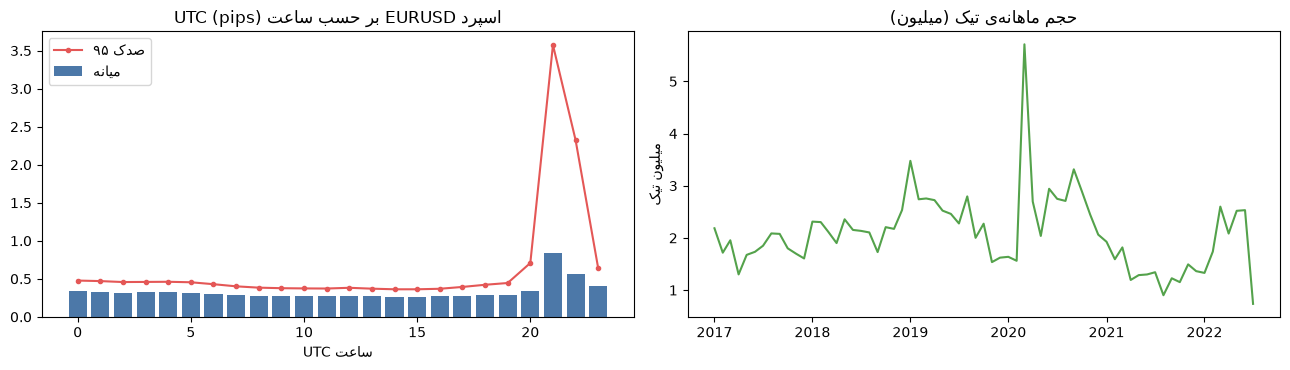

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
میانه (pips),0.339,0.330,0.320,0.321,0.323,0.320,0.306,0.287,0.278,0.277,...,0.267,0.266,0.269,0.276,0.283,0.292,0.336,0.843,0.564,0.400
صدک ۹۵,0.477,0.470,0.458,0.459,0.461,0.455,0.429,0.401,0.384,0.377,...,0.362,0.363,0.369,0.393,0.422,0.445,0.708,3.575,2.325,0.638
میانگین,0.362,0.353,0.337,0.340,0.339,0.337,0.322,0.309,0.287,0.283,...,0.275,0.275,0.279,0.290,0.303,0.321,0.400,1.219,0.846,0.442


In [3]:
# ==================================================================================
# Cell 2 — کنترل کیفیت داده (QA): تراکم تیک، اسپرد، شکاف‌ها و جهش‌های ناگهانی
# ==================================================================================
import matplotlib.pyplot as plt

_t = time.time()
_ts_all = np.asarray(TS)
_d = np.diff(_ts_all)
_big = np.where(_d > 30 * 60_000)[0]
gap_tbl = pd.DataFrame({
    "شروع (UTC)": pd.to_datetime(_ts_all[_big], unit="ms"),
    "پایان (UTC)": pd.to_datetime(_ts_all[_big + 1], unit="ms"),
    "مدت (ساعت)": (_d[_big] / 3.6e6).round(1)}).sort_values("مدت (ساعت)", ascending=False)
print(f"شکاف‌های بیش از ۳۰ دقیقه: {len(_big)} مورد (بیشتر تعطیلات آخر هفته/کریسمس/سال نو)")
display(gap_tbl.head(8).reset_index(drop=True))

# M1 از تیک‌ها (یک بار، کل بازه)
M1 = build_m1_frame(TS, BID, ASK)
print(f"دقیقه‌های دارای تیک: {len(M1):,} | زمان ساخت M1: {time.time() - _t:.1f}s")

_hr = M1.index.hour
spread_by_hour = M1.groupby(_hr)["spread"].agg(["median", lambda s: s.quantile(0.95), "mean"])
spread_by_hour.columns = ["میانه (pips)", "صدک ۹۵", "میانگین"]
_yr_ticks = M1.groupby(M1.index.year)["ticks"].sum()
_yr_tph = (M1.groupby(M1.index.year)["ticks"].sum() / M1.groupby(M1.index.year).size()).round(0)
qa_year = pd.DataFrame({"تیک (میلیون)": (_yr_ticks / 1e6).round(2), "میانگین تیک در دقیقه‌ی فعال": _yr_tph})
display(qa_year)
print("توجه: تراکم تیک در سال ۲۰۲۱ حدود نصف ۲۰۲۰ است؛ این تغییر ساختاری داده است و در گزارش نهایی به آن اشاره می‌شود.")

fig, ax = plt.subplots(1, 2, figsize=(13, 3.8))
ax[0].bar(spread_by_hour.index, spread_by_hour["میانه (pips)"], color="#4C78A8", label="میانه")
ax[0].plot(spread_by_hour.index, spread_by_hour["صدک ۹۵"], color="#E45756", marker="o", ms=3, label="صدک ۹۵")
ax[0].set_title("اسپرد EURUSD بر حسب ساعت UTC (pips)"); ax[0].set_xlabel("ساعت UTC"); ax[0].legend()
_m = M1["ticks"].resample("MS").sum()
ax[1].plot(_m.index, _m.values / 1e6, color="#54A24B")
ax[1].set_title("حجم ماهانه‌ی تیک (میلیون)"); ax[1].set_ylabel("میلیون تیک")
plt.tight_layout(); plt.show()
display(spread_by_hour.round(3).T)


## ۴. پروتکل ارزیابی (بدون نگاه به آینده و بدون تنظیم روی holdout)
| بخش | بازه | کاربرد |
|---|---|---|
| **پژوهش** | ۲۰۱۷-۰۱ تا ۲۰۲۰-۱۲ | توسعه‌ی قاعده‌ها و آموزش ML؛ **walk-forward** با ۱۲ فصل آزمون خارج از نمونه (۲۰۱۸Q1–۲۰۲۰Q4) |
| **holdout (گاوصندوق)** | ۲۰۲۱-۰۱ تا ۲۰۲۲-۰۶ | فقط یک‌بار، با پیکربندی منجمد (قاعده‌ها) یا بازآموزی فصلی با داده‌ی قبلی (ML) |
| **embargo** | ۱ روز | بین آموزش و آزمون؛ برچسب‌های هر نمونه‌ی آموزش باید قبل از شروع فصل آزمون (منهای embargo) تمام شده باشند |

**قواعد کلیدی:**
- در هر فصل، پارامترها فقط با داده‌ی **قبل از همان فصل** انتخاب می‌شوند (معیار: t-stat میانگین R معاملات آموزش، حداقل ۴۰ معامله).
- **کلید خاموشی:** اگر بهترین t-stat آموزش منفی باشد، آن فصل معامله نمی‌شود (در غیر این صورت سیستم بهترین زیان‌ده را انتخاب می‌کند).
- آستانه‌ی احتمال ML با صدک‌ها روی 25٪ انتهایی داده‌ی آموزش انتخاب می‌شود (اعتبارسنجی درون‌نمونه‌ای).
- **شفافیت:** نتایج holdout برای همه‌ی روش‌ها نشان داده شده‌اند، اما انتخاب استراتژی فقط با داده‌ی پژوهش انجام شده است.

In [4]:
# ==================================================================================
# Cell 3 — پروتکل ارزیابی و توابع کمکی (بدون نگاه به آینده)
# ==================================================================================
from itertools import combinations
from scipy.stats import norm, skew, kurtosis

EMBARGO_MS = MS_DAY  # فاصله‌ی احتیاطی بین آموزش و آزمون (و افق برچسب‌ها)


def ms(x):
    return int(pd.Timestamp(x).value // 10 ** 6)


def quarters(start, end):
    q = pd.date_range(start, end, freq="QS")
    return [(ms(a), ms(b), f"{a.year}Q{a.quarter}") for a, b in zip(q[:-1], q[1:])]


RP_START, RP_END = ms("2017-01-01"), ms("2021-01-01")   # پژوهش: توسعه و walk-forward
HO_START, HO_END = ms("2021-01-01"), ms("2022-07-01")   # گاوصندوق (holdout): یک‌بار، با پیکربندی منجمد؛ 2022-07 ناقص است و کنار گذاشته می‌شود
OOS_Q = quarters("2018-01-01", "2021-01-01")            # 12 فصل آزمون خارج از نمونه (walk-forward)
HO_Q = quarters("2021-01-01", "2022-07-01")             # 6 فصل holdout

PRM0 = default_params(equity=10_000.0, risk=0.005, max_lev=30.0, comm=3.5, slip_pips=0.1,
                      latency_ms=1000, fillwin_ms=30_000, max_spread_pips=2.0)
TRC = ["entry_ts", "exit_ts", "dir", "entry", "exit", "lots", "gross", "comm", "net", "reason",
       "risk", "sl", "tp", "mae", "mfe", "spread_in", "sig", "hold_min"]


def run_window(cands, t0, t1, prm=None, eq0=None):
    """اجرای موتور تیک‌به‌تیک روی بازه‌ی [t0, t1). پوزیشن‌های باز در t1 با آخرین تیک بسته می‌شوند."""
    prm = PRM0.copy() if prm is None else prm.copy()
    if eq0 is not None:
        prm[P_EQ0] = eq0
    i0 = int(np.searchsorted(TS, t0, side="left"))
    i1 = int(np.searchsorted(TS, t1, side="left"))
    d = cands["dec_ms"].values
    c = cands[(d >= t0) & (d < t1)]
    tr, eq, bal, dda, ddr, ntr = run_engine(
        TS[i0:i1], BID[i0:i1], ASK[i0:i1],
        c["dec_ms"].values.astype(np.int64), c["dir"].values.astype(np.float64),
        c["sl"].values.astype(np.float64), c["tp"].values.astype(np.float64),
        c["hold"].values.astype(np.int64), prm)
    return {"tr": tr, "eq": eq, "bal": bal, "dd_abs": dda, "dd_rel": ddr, "n_sig": len(c), "eq0": prm[P_EQ0]}


def trades_frame(tr):
    df = pd.DataFrame(tr, columns=TRC)
    if len(df) == 0:
        return df
    df["entry_time"] = pd.to_datetime(df["entry_ts"].astype(np.int64), unit="ms")
    df["exit_time"] = pd.to_datetime(df["exit_ts"].astype(np.int64), unit="ms")
    df["R"] = df["net"] / df["risk"]
    df["net_pips"] = df["net"] / (df["lots"] * PIP_VALUE_LOT * 10.0)  # ۱ pip = ۱۰ دلار برای هر لات
    df["exit_reason"] = df["reason"].astype(int).map(EXIT_NAMES)
    return df


def equity_series(eq, eq0):
    s = pd.Series(eq[:, 1], index=pd.to_datetime(eq[:, 0].astype(np.int64), unit="ms")).sort_index()
    return s[~s.index.duplicated(keep="last")]


def monthly_returns(eq, eq0):
    s = equity_series(eq, eq0)
    if len(s) == 0:
        return pd.Series(dtype=float)
    eom = s.resample("ME").last().ffill().fillna(eq0)
    prev = np.concatenate([[eq0], eom.values[:-1]])
    return pd.Series(eom.values / prev - 1.0, index=eom.index.to_period("M"))


def daily_returns(eq, eq0):
    s = equity_series(eq, eq0)
    if len(s) == 0:
        return pd.Series(dtype=float)
    eod = s.resample("D").last().ffill().fillna(eq0)
    eod = eod[eod.index.dayofweek < 5]
    return eod.pct_change().dropna()


def summarize(tr, eq, eq0, dd_rel, dd_abs, t0, t1, label=""):
    df = trades_frame(tr)
    out = {"strategy": label, "trades": int(len(df))}
    years = (t1 - t0) / (365.25 * MS_DAY)
    end_eq = float(eq[-1, 1]) if len(eq) else eq0
    out["net_profit_%"] = 100 * (end_eq / eq0 - 1)
    out["CAGR_%"] = 100 * ((max(end_eq, 1e-9) / eq0) ** (1 / years) - 1) if years > 0 else np.nan
    mr = monthly_returns(eq, eq0)
    out["months"] = int(len(mr))
    out["monthly_mean_%"] = 100 * mr.mean() if len(mr) else np.nan
    out["monthly_median_%"] = 100 * mr.median() if len(mr) else np.nan
    out["monthly_min_%"] = 100 * mr.min() if len(mr) else np.nan
    out["monthly_max_%"] = 100 * mr.max() if len(mr) else np.nan
    out["months_>=3%_%"] = 100 * (mr >= 0.03).mean() if len(mr) else np.nan
    out["months_>0_%"] = 100 * (mr > 0).mean() if len(mr) else np.nan
    out["maxDD_%"] = 100 * dd_rel
    out["maxDD_usd"] = dd_abs
    out["Calmar"] = out["CAGR_%"] / out["maxDD_%"] if out["maxDD_%"] > 0 else np.nan
    dr = daily_returns(eq, eq0)
    out["Sharpe_daily_ann"] = dr.mean() / dr.std() * np.sqrt(252) if len(dr) > 2 and dr.std() > 0 else np.nan
    if len(df):
        R = df["R"].values
        out["win_rate_%"] = 100 * (R > 0).mean()
        out["avg_R"] = R.mean()
        out["t_stat_R"] = R.mean() / (R.std(ddof=1) / np.sqrt(len(R))) if len(R) > 1 and R.std() > 0 else np.nan
        gp = df.loc[df.net > 0, "net"].sum()
        gl = -df.loc[df.net < 0, "net"].sum()
        out["profit_factor"] = gp / gl if gl > 0 else np.nan
        out["avg_net_pips"] = df["net_pips"].mean()
        out["avg_hold_h"] = df["hold_min"].mean() / 60
        out["spread_cost_usd_est"] = float((df["spread_in"] * df["lots"] * CONTRACT).sum())
        out["commission_usd"] = float(df["comm"].sum())
    return out


def boot_ci(x, stat=np.mean, B=2000, seed=0, alpha=0.05):
    x = np.asarray(x, dtype=float)
    if len(x) < 3:
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    idx = rng.integers(0, len(x), size=(B, len(x)))
    v = stat(x[idx], axis=1)
    return float(np.quantile(v, alpha / 2)), float(np.quantile(v, 1 - alpha / 2))


def deflated_sharpe(sr_hat, T, skew_, kurt_, n_trials, var_trials):
    """Bailey & López de Prado (2014). sr_hat و var_trials بر حسب واحد دوره (غیرسالانه)."""
    emc = 0.5772156649
    sr0 = np.sqrt(max(var_trials, 1e-12)) * ((1 - emc) * norm.ppf(1 - 1 / n_trials) + emc * norm.ppf(1 - 1 / (n_trials * np.e)))
    denom = np.sqrt(max(1 - skew_ * sr_hat + (kurt_ - 1) / 4 * sr_hat ** 2, 1e-12))
    z = (sr_hat - sr0) * np.sqrt(max(T - 1, 1)) / denom
    return float(norm.cdf(z)), float(sr0)


def pbo_cscv(M, S=12):
    """Probability of Backtest Overfitting با CSCV (Bailey et al. 2015). M: دوره‌ها × استراتژی‌ها."""
    T, N = M.shape
    blocks = np.array_split(np.arange(T), S)
    logits = []
    for comb in combinations(range(S), S // 2):
        is_idx = np.concatenate([blocks[b] for b in comb])
        oos_idx = np.concatenate([blocks[b] for b in range(S) if b not in comb])
        p_is = M[is_idx].mean(axis=0)
        p_oos = M[oos_idx].mean(axis=0)
        n_star = int(np.argmax(p_is))
        rank = (p_oos < p_oos[n_star]).sum() + 0.5 * ((p_oos == p_oos[n_star]).sum() - 1) + 1
        w = rank / (N + 1)
        logits.append(np.log(w / (1 - w)))
    logits = np.array(logits)
    return float((logits <= 0).mean()), logits


def tstat(x):
    x = np.asarray(x, dtype=float)
    return float(x.mean() / (x.std(ddof=1) / np.sqrt(len(x)))) if len(x) > 2 and x.std(ddof=1) > 0 else -np.inf


print("پروتکل:")
print(f"  پژوهش (walk-forward): {pd.Timestamp(RP_START, unit='ms').date()} تا {pd.Timestamp(RP_END, unit='ms').date()} | {len(OOS_Q)} فصل آزمون")
print(f"  گاوصندوق (holdout):   {pd.Timestamp(HO_START, unit='ms').date()} تا {pd.Timestamp(HO_END, unit='ms').date()} | {len(HO_Q)} فصل")
print(f"  embargo: {EMBARGO_MS // MS_DAY} روز | ورودی: تیک بعد از تأخیر {PRM0[P_LAT]:.0f}ms | اسپرد بیشینه: {PRM0[P_MAXSPREAD] / PIP:.1f} pips")


پروتکل:
  پژوهش (walk-forward): 2017-01-01 تا 2021-01-01 | 12 فصل آزمون
  گاوصندوق (holdout):   2021-01-01 تا 2022-07-01 | 6 فصل
  embargo: 1 روز | ورودی: تیک بعد از تأخیر 1000ms | اسپرد بیشینه: 2.0 pips


## ۵. سیگنال‌های قانون‌محور (چهار خانواده)
- **F1 شکست رنج آسیا در باز شدن لندن (M5):** بالا/پایین بازه‌ی ۰۰:۰۰–۰۷:۰۰ UTC؛ اولین شکست بعد از ۰۷:۰۰ تا ۱۰ یا ۱۲ UTC؛ فیلتر اندازه‌ی رنج.
- **F2 شکست دونچیان H1 با فیلتر EMA200:** شکست بالای/پایین ۲۴ یا ۴۸ کندل قبلی، در جهت روند EMA200، SL = k·ATR، TP = rr·SL، سقف زمانی ۵ روز.
- **F3 بازگشت به میانگین (M15):** خارج شدن از باند بولینگر و RSI افراطی در رژیم کم‌ADX؛ هدف = میانگین.
- **F4 الگوی پیوت (M15، بازتعریف ساده‌شده‌ی ایده‌ی Pivot Settlement قبلی):** فراکتال علّی (تأیید بعد از ۳ کندل)، موج AB با حداقل ۲ یا ۳ برابر ATR، اصلاح به ۵۰–۷۸.۶٪ و بسته‌شدن برگشتی. این نسخه ترجمه‌ی مستقیم کد قبلی نیست.

In [5]:
# ==================================================================================
# Cell 4 — ساخت نوار (bar) و سیگنال‌های چهار خانواده‌ی قانون‌محور
# F1 شکست رنج آسیا در باز شدن لندن | F2 شکست دونچیان H1 با فیلتر EMA200
# F3 بازگشت به میانگین (بولینگر+RSI+ADX پایین) | F4 الگوی پیوت: AB + اصلاح 50–78.6% + بسته‌شدن برگشتی
# ==================================================================================
BARS = {}
BARS["m1"] = M1
BARS["b5"] = resample_bars(M1, "5min")
BARS["b15"] = resample_bars(M1, "15min")
BARS["b1"] = resample_bars(M1, "1h")
for _k in ["b5", "b15", "b1"]:
    print(f"{_k}: {len(BARS[_k]):,} نوار با تیک")

FAMILY_FN = {
    "F1_AsiaBreakout": ("b5", f1_asia_breakout),
    "F2_Donchian": ("b1", f2_donchian),
    "F3_MeanRev": ("b15", f3_mean_reversion),
    "F4_PivotRetrace": ("b15", f4_pivot_retrace),
}
GRID_CFG = {
    "F1_AsiaBreakout": [dict(sl_mode=m, rr=r, win_end_h=w, buf_pips=b)
                        for m in ["range", "atr"] for r in [1.0, 1.5, 2.0] for w in [10, 12] for b in [0.0, 1.0]],
    "F2_Donchian": [dict(n=n, k=k, rr=r) for n in [24, 48] for k in [1.5, 2.5] for r in [1.5, 3.0]],
    "F3_MeanRev": [dict(bb_k=b, sl_atr=s) for b in [2.0, 2.5] for s in [1.5, 2.5]],
    "F4_PivotRetrace": [dict(ab_atr=a, rr=r, max_wait=w) for a in [2.0, 3.0] for r in [1.0, 2.0] for w in [20, 40]],
}
N_RULE_CONFIGS = sum(len(v) for v in GRID_CFG.values())


def cfg_name(fam, cfg):
    return fam + "|" + ",".join(f"{k}={v}" for k, v in cfg.items())


def make_cands(fam, cfg):
    bkey, fn = FAMILY_FN[fam]
    return fn(BARS[bkey], **cfg)


CANDS = {}
_rows = []
for _fam, _grid in GRID_CFG.items():
    CANDS[_fam] = {}
    for _cfg in _grid:
        _name = cfg_name(_fam, _cfg)
        _c = make_cands(_fam, _cfg)
        CANDS[_fam][_name] = _c
        _rows.append({"family": _fam, "config": ",".join(f"{k}={v}" for k, v in _cfg.items()),
                      "signals": len(_c), "long_%": 100 * (_c["dir"] > 0).mean() if len(_c) else np.nan})
display(pd.DataFrame(_rows).groupby("family").agg(configs=("config", "size"), min_signals=("signals", "min"),
                                                   median_signals=("signals", "median"), max_signals=("signals", "max")))


b5: 410,601 نوار با تیک
b15: 136,879 نوار با تیک
b1: 34,223 نوار با تیک


,configs,min_signals,median_signals,max_signals
family,,,,
F1_AsiaBreakout,24,1102,1180.0,1233
F2_Donchian,8,1457,1644.5,1832
F3_MeanRev,4,785,936.0,1087
F4_PivotRetrace,8,1727,2143.5,2561


### خودآزمایی موتور
قبل از هر آزمایش، موتور روی یک ماه داده بررسی می‌شود: تطابق موجودی با مجموع سود، زمان ورود، سطح TP/SL، حجم لات و تک‌پوزیشن بودن. اگر یکی از این‌ها شکست بخورد، اجرای بعدی متوقف می‌شود.

In [6]:
# ==================================================================================
# خودآزمایی موتور (Unit checks) روی یک ماه داده — اگر یکی شکست بخورد، اجرای بعدی متوقف می‌شود
# ==================================================================================
_c_name = list(CANDS["F2_Donchian"].keys())[0]
_cd_full = CANDS["F2_Donchian"][_c_name]
_t0, _t1 = ms("2019-03-01"), ms("2019-04-01")
_res = run_window(_cd_full, _t0, _t1)
_tr = _res["tr"]
_cwin = _cd_full[(_cd_full["dec_ms"].values >= _t0) & (_cd_full["dec_ms"].values < _t1)].reset_index(drop=True)
_checks = {}
_checks["مانده = سرمایه‌ی اولیه + مجموع خالص سود معاملات"] = bool(
    abs(_res["bal"] - (PRM0[P_EQ0] + _tr[:, TR_NET].sum())) < 1e-6)
if len(_tr):
    _sig = _tr[:, TR_SIG].astype(int)
    _lag = _tr[:, TR_ENTRY_TS] - _cwin["dec_ms"].values[_sig]
    _checks["ورود حداقل پس از تأخیر تنظیم‌شده است"] = bool(np.all(_lag >= PRM0[P_LAT] - 1e-9))
    _d = _tr[:, TR_DIR]
    _sl_lvl = _tr[:, TR_ENTRY] - _d * _tr[:, TR_SL]
    _tp_m = _tr[:, TR_REASON] == 1
    _checks["خروج TP دقیقاً روی سطح TP پر می‌شود"] = bool(
        np.all(np.abs(_tr[_tp_m, TR_EXIT] - (_tr[_tp_m, TR_ENTRY] + _d[_tp_m] * _tr[_tp_m, TR_TP])) < 1e-9)) if _tp_m.any() else True
    _sl_m = _tr[:, TR_REASON] == 0
    _checks["خروج SL همیشه در سمت زیان نسبت به سطح SL است"] = bool(
        np.all(_d[_sl_m] * (_tr[_sl_m, TR_EXIT] - _sl_lvl[_sl_m]) <= 1e-12)) if _sl_m.any() else True
    _checks["حجم لات: ریسک واقعی ≤ ریسک هدف"] = bool(
        np.all(_tr[:, TR_LOTS] * _tr[:, TR_SL] * CONTRACT <= _tr[:, TR_RISK] * (1 + 1e-7)))
    _checks["حداکثر یک پوزیشن هم‌زمان (ورود بعد از خروج قبلی)"] = bool(
        np.all(_tr[1:, TR_ENTRY_TS] >= _tr[:-1, TR_EXIT_TS]))
    _checks["زمان خروج بعد از زمان ورود است"] = bool(np.all(_tr[:, TR_EXIT_TS] >= _tr[:, TR_ENTRY_TS]))
print(f"خودآزمایی روی «{_c_name}» در مارس ۲۰۱۹ | {len(_tr)} معامله")
for _k, _v in _checks.items():
    print(("✔" if _v else "✘"), _k)
assert all(_checks.values()), "خودآزمایی موتور ناموفق بود"
print("همه‌ی خودآزمایی‌ها گذشت.")


خودآزمایی روی «F2_Donchian|n=24,k=1.5,rr=1.5» در مارس ۲۰۱۹ | 16 معامله
✔ مانده = سرمایه‌ی اولیه + مجموع خالص سود معاملات
✔ ورود حداقل پس از تأخیر تنظیم‌شده است
✔ خروج TP دقیقاً روی سطح TP پر می‌شود
✔ خروج SL همیشه در سمت زیان نسبت به سطح SL است
✔ حجم لات: ریسک واقعی ≤ ریسک هدف
✔ حداکثر یک پوزیشن هم‌زمان (ورود بعد از خروج قبلی)
✔ زمان خروج بعد از زمان ورود است
همه‌ی خودآزمایی‌ها گذشت.


## ۶. Walk-forward خانواده‌های قانون‌محور
پیکربندی هر فصل فقط با داده‌ی گذشته انتخاب می‌شود. جدول زیر نتیجه‌ی ادغام فصل‌های خارج از نمونه (2018–2020) و holdout را نشان می‌دهد.

**تفسیر:** F1 و F2 در پژوهش زیان‌ده‌اند (F2 با ضریب سود ۰.۹۶ کمی زیان‌ده است). F3 و F4 توسط کلید خاموشی در همه‌ی فصل‌ها غیرفعال شدند، زیرا بهترین t-stat آموزش آن‌ها منفی بود. در holdout، F2 حدود −۷٪ است. اجرای «بی‌قید» F4 در holdout ۲۹٪ زیان می‌دهد؛ یعنی این الگو با هزینه‌ی واقعی سودآور نیست.

In [7]:
# ==================================================================================
# Cell 5 — Walk-forward برای خانواده‌های قانون‌محور
# • انتخاب پارامتر در هر فصل فقط با داده‌ی قبل از همان فصل (+embargo) و معیار t-stat میانگین R
# • ادامه‌ی سرمایه بین فصل‌ها؛ DD سراسری از رویدادهای سرمایه (دقت تیک‌به‌تیک در هر اجرای مجزا)
# • پیکربندی منجمد برای holdout فقط با داده‌ی پژوهش (2017–2020) انتخاب می‌شود
# ==================================================================================
MIN_TRAIN_TRADES = 40
MIN_TSTAT_TRADE = 0.0   # کلید خاموشی: اگر بهترین t-stat آموزش منفی باشد، در آن فصل معامله نمی‌شود


def dd_from_events(eq):
    if len(eq) == 0:
        return 0.0, 0.0
    v = eq[:, 1]
    pk = np.maximum.accumulate(v)
    return float(((pk - v) / pk).max()), float((pk - v).max())


def score_cfg(cd, t0, t1):
    r = run_window(cd, t0, t1)
    tr = r["tr"]
    if len(tr) < MIN_TRAIN_TRADES:
        return -np.inf, r
    R = tr[:, TR_NET] / tr[:, TR_RISK]
    return tstat(R), r


WFO = {}
PBO_COLS = {}
for fam, grid in GRID_CFG.items():
    cd_map = CANDS[fam]
    for name, cd in cd_map.items():  # برای PBO: اجرای ثابت هر پیکربندی روی 2018–2020
        r = run_window(cd, ms("2018-01-01"), RP_END)
        PBO_COLS[name] = monthly_returns(r["eq"], PRM0[P_EQ0])

    oos_tr, oos_eq, folds = [], [], []
    bal = PRM0[P_EQ0]
    for qs, qe, lab in OOS_Q:
        best_sc, best_name = -np.inf, None
        for name, cd in cd_map.items():
            sc, _ = score_cfg(cd, RP_START, qs - EMBARGO_MS)
            if sc > best_sc:
                best_sc, best_name = sc, name
        if best_name is None or best_sc < MIN_TSTAT_TRADE:
            folds.append({"فصل": lab, "پیکربندی انتخابی": "— (کلید خاموشی)", "t-stat آموزش": round(best_sc, 2),
                          "معامله‌ی OOS": 0, "بازده‌ی فصل %": 0.0})
            oos_eq.append(np.array([[qs, bal], [qe - 1, bal]]))
            continue
        r = run_window(cd_map[best_name], qs, qe, eq0=bal)
        if len(r["tr"]):
            oos_tr.append(r["tr"])
        oos_eq.append(r["eq"])
        bal_prev = bal
        bal = r["bal"]
        folds.append({"فصل": lab, "پیکربندی انتخابی": best_name.split("|")[1], "t-stat آموزش": round(best_sc, 2),
                      "معامله‌ی OOS": len(r["tr"]), "بازده‌ی فصل %": round(100 * (bal / bal_prev - 1), 2)})

    tr_all = np.vstack(oos_tr) if oos_tr else np.zeros((0, TR_NCOL))
    eq_all = np.vstack(oos_eq)
    ddr, dda = dd_from_events(eq_all)
    summ_oos = summarize(tr_all, eq_all, PRM0[P_EQ0], ddr, dda, ms("2018-01-01"), RP_END, label=fam + " (WF-OOS)")

    best_full, name_full = -np.inf, None
    for name, cd in cd_map.items():
        sc, _ = score_cfg(cd, RP_START, RP_END)
        if sc > best_full:
            best_full, name_full = sc, name
    r_ho = run_window(cd_map[name_full], HO_START, HO_END)  # اجرای بی‌قید (برای شفافیت)
    summ_ho = summarize(r_ho["tr"], r_ho["eq"], PRM0[P_EQ0], r_ho["dd_rel"], r_ho["dd_abs"], HO_START, HO_END,
                        label=fam + " (holdout، بی‌قید)")
    kill = best_full < MIN_TSTAT_TRADE  # طبق پروتکل: اگر t-stat پژوهش منفی است، این خانواده در holdout معامله نمی‌کند
    summ_ho_p = summarize(np.zeros((0, TR_NCOL)), np.array([[HO_START, PRM0[P_EQ0]], [HO_END - 1, PRM0[P_EQ0]]]),
                          PRM0[P_EQ0], 0.0, 0.0, HO_START, HO_END, label=fam + " (holdout، طبق پروتکل)") if kill else \
        summarize(r_ho["tr"], r_ho["eq"], PRM0[P_EQ0], r_ho["dd_rel"], r_ho["dd_abs"], HO_START, HO_END,
                  label=fam + " (holdout، طبق پروتکل)")
    WFO[fam] = dict(oos_summary=summ_oos, oos_tr=tr_all, oos_eq=eq_all, folds=pd.DataFrame(folds),
                    frozen=name_full, frozen_score=best_full, holdout=r_ho, holdout_summary=summ_ho,
                    holdout_protocol=summ_ho_p, killed_holdout=kill)
    print(f"\n=== {fam} | پیکربندی منجمد: {name_full.split('|')[1]} (t-stat پژوهش={best_full:.2f})")
    display(WFO[fam]["folds"])

RULE_SUMMARY = pd.DataFrame([WFO[f]["oos_summary"] for f in WFO] + [WFO[f]["holdout_protocol"] for f in WFO]
                            + [WFO[f]["holdout_summary"] for f in WFO])
_cols = ["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%", "maxDD_%",
         "win_rate_%", "avg_R", "t_stat_R", "profit_factor", "Sharpe_daily_ann"]
display(RULE_SUMMARY[_cols].round(3).set_index("strategy"))



=== F1_AsiaBreakout | پیکربندی منجمد: sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0 (t-stat پژوهش=-1.18)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,"sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0",0.92,52,-0.83
1,2018Q2,"sl_mode=range,rr=2.0,win_end_h=10,buf_pips=1.0",0.72,60,-7.37
2,2018Q3,— (کلید خاموشی),-0.16,0,0.00
3,2018Q4,— (کلید خاموشی),-0.58,0,0.00
4,2019Q1,— (کلید خاموشی),-1.04,0,0.00
5,2019Q2,— (کلید خاموشی),-1.22,0,0.00
6,2019Q3,— (کلید خاموشی),-1.81,0,0.00
7,2019Q4,— (کلید خاموشی),-1.37,0,0.00
8,2020Q1,— (کلید خاموشی),-1.66,0,0.00
9,2020Q2,— (کلید خاموشی),-1.38,0,0.00



=== F2_Donchian | پیکربندی منجمد: n=24,k=2.5,rr=1.5 (t-stat پژوهش=0.27)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,"n=24,k=1.5,rr=1.5",0.74,64,2.48
1,2018Q2,"n=48,k=1.5,rr=1.5",1.10,47,0.58
2,2018Q3,"n=48,k=1.5,rr=1.5",1.07,49,2.17
3,2018Q4,"n=48,k=1.5,rr=1.5",1.20,44,-4.49
4,2019Q1,"n=48,k=1.5,rr=1.5",0.73,43,-1.94
5,2019Q2,"n=48,k=1.5,rr=1.5",0.53,42,0.09
6,2019Q3,"n=48,k=1.5,rr=1.5",0.51,42,1.81
7,2019Q4,"n=48,k=1.5,rr=1.5",0.63,45,-1.79
8,2020Q1,"n=48,k=2.5,rr=1.5",0.68,39,4.41
9,2020Q2,"n=48,k=2.5,rr=1.5",1.07,43,-6.33



=== F3_MeanRev | پیکربندی منجمد: bb_k=2.5,sl_atr=1.5 (t-stat پژوهش=-3.64)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,— (کلید خاموشی),-1.43,0,0.0
1,2018Q2,— (کلید خاموشی),-1.64,0,0.0
2,2018Q3,— (کلید خاموشی),-2.56,0,0.0
3,2018Q4,— (کلید خاموشی),-3.34,0,0.0
4,2019Q1,— (کلید خاموشی),-3.41,0,0.0
5,2019Q2,— (کلید خاموشی),-3.01,0,0.0
6,2019Q3,— (کلید خاموشی),-2.95,0,0.0
7,2019Q4,— (کلید خاموشی),-3.09,0,0.0
8,2020Q1,— (کلید خاموشی),-3.31,0,0.0
9,2020Q2,— (کلید خاموشی),-3.60,0,0.0



=== F4_PivotRetrace | پیکربندی منجمد: ab_atr=3.0,rr=1.0,max_wait=40 (t-stat پژوهش=-7.02)


,فصل,پیکربندی انتخابی,t-stat آموزش,معامله‌ی OOS,بازده‌ی فصل %
0,2018Q1,— (کلید خاموشی),-3.80,0,0.0
1,2018Q2,— (کلید خاموشی),-4.11,0,0.0
2,2018Q3,— (کلید خاموشی),-4.05,0,0.0
3,2018Q4,— (کلید خاموشی),-4.74,0,0.0
4,2019Q1,— (کلید خاموشی),-4.47,0,0.0
5,2019Q2,— (کلید خاموشی),-4.83,0,0.0
6,2019Q3,— (کلید خاموشی),-5.13,0,0.0
7,2019Q4,— (کلید خاموشی),-5.96,0,0.0
8,2020Q1,— (کلید خاموشی),-6.46,0,0.0
9,2020Q2,— (کلید خاموشی),-6.33,0,0.0


,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor,Sharpe_daily_ann
strategy,,,,,,,,,,,
F1_AsiaBreakout (WF-OOS),112,-8.136,-2.789,-0.225,0.0,11.513,44.643,-0.149,-1.696,0.696,-0.955
F2_Donchian (WF-OOS),550,-5.844,-1.987,-0.150,0.0,11.951,41.273,-0.019,-0.386,0.961,-0.217
F3_MeanRev (WF-OOS),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F4_PivotRetrace (WF-OOS),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F2_Donchian (holdout، طبق پروتکل),250,-6.958,-4.710,-0.386,0.0,11.035,42.800,-0.055,-0.801,0.894,-0.596
F3_MeanRev (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F4_PivotRetrace (holdout، طبق پروتکل),0,0.000,0.000,0.000,0.0,0.000,NaN,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، بی‌قید),313,-5.005,-3.376,-0.270,0.0,12.487,46.326,-0.031,-0.575,0.923,-0.487


## ۷. یادگیری ماشین: ویژگی‌ها و برچسب‌های سه‌مانعه‌ای از مسیر تیک
- **ویژگی‌ها (۲۶ ستون، کاملاً علّی):** بازده‌های نرمال‌شده با ATR در چند افق، RSI، ADX، موقعیت بولینگر و EMAها، موقعیت در کانال دونچیان ۴۸، ساعت (سینوسی)، روز هفته، اسپرد و نسبت به میانه‌ی ۲۴ ساعته، شدت تیک‌ها، سهم حرکت‌های صعودی تیک‌ها، زمینه‌ی روز قبل (بالا/پایین)، و روند H1 (با `merge_asof` علّی).
- **برچسب M2 (سه‌مانعه):** برای هر نوار M15 دو نامزد: خرید و فروش؛ SL = ۱·ATR، TP = ۱.۵·ATR، سقف زمانی ۴ ساعت. نتیجه با **مسیر تیک واقعی** و با هزینه‌ی کامل سنجیده می‌شود: برد اگر R خالص > 0.
- **برچسب M1 (متا-برچسب):** سیگنال‌های پایه‌ی چهار خانواده (پیکربندی میانی) را می‌گیرد و برچسب آن‌ها برد/باخت خالص همان معامله است. مدل فقط تشخیص می‌دهد کدام سیگنال‌ها ارزش اجرا دارند.
- **مدل:** `HistGradientBoostingClassifier` (جداگانه برای خرید و فروش در M2).

In [8]:
# ==================================================================================
# Cell 6 — ML: ویژگی‌های علّی (M15 + H1 + زمینه‌ی روز قبل) و برچسب‌های سه‌مانعه‌ای با مسیر تیک
#   M2 (مستقیم): هر نوار M15 دو نامزد (خرید/فروش) با SL=1·ATR، TP=1.5·ATR، سقف زمانی 4 ساعت
#   M1 (متا-برچسب): هر سیگنال خانواده‌های قانون‌محور، برچسب = برد/باخت خالص (با هزینه) همان معامله
# ==================================================================================
from sklearn.ensemble import HistGradientBoostingClassifier


def build_features(b15, b1):
    A = atr(b15)
    c = b15["close"]
    F = pd.DataFrame(index=b15.index)
    for k in [1, 4, 16, 64]:
        F[f"ret{k}"] = (c - c.shift(k)) / A
    F["atr_pips"] = A / PIP
    F["atr_ratio"] = A / A.rolling(96).mean()
    F["rsi14"] = rsi(c)
    F["adx14"] = adx(b15)
    m20 = c.rolling(20).mean()
    s20 = c.rolling(20).std()
    F["bbz20"] = (c - m20) / s20
    for n in [20, 50, 200]:
        F[f"ema{n}_d"] = (c - c.ewm(span=n, adjust=False).mean()) / A
    hi48 = b15["high"].rolling(48).max()
    lo48 = b15["low"].rolling(48).min()
    F["don48_pos"] = (c - lo48) / (hi48 - lo48)
    F["range_atr"] = (b15["high"] - b15["low"]) / A
    hr = b15.index.hour + b15.index.minute / 60.0
    F["hsin"] = np.sin(2 * np.pi * hr / 24)
    F["hcos"] = np.cos(2 * np.pi * hr / 24)
    F["dow"] = b15.index.dayofweek
    F["spread_pips"] = b15["spread"]
    F["spread_rel"] = b15["spread"] / b15["spread"].rolling(96).median()
    lt = np.log1p(b15["ticks"].astype(float))
    F["tick_rel"] = lt - lt.rolling(96).mean()
    F["upfrac"] = b15["up"] / (b15["up"] + b15["dn"]).replace(0, np.nan)
    F["upfrac4"] = b15["up"].rolling(4).sum() / (b15["up"] + b15["dn"]).rolling(4).sum()
    day = b15.index.normalize()
    dd = pd.DataFrame({"h": b15["high"].values, "l": b15["low"].values}, index=day).groupby(level=0).agg(h=("h", "max"), l=("l", "min"))
    F["pd_hi_d"] = (c.values - dd["h"].shift(1).reindex(day).values) / A.values
    F["pd_lo_d"] = (c.values - dd["l"].shift(1).reindex(day).values) / A.values
    A1 = atr(b1)
    c1 = b1["close"]
    H = pd.DataFrame({"dec_ms": b1["dec_ms"].values,
                      "h1_trend": ((c1.ewm(span=50, adjust=False).mean() - c1.ewm(span=200, adjust=False).mean()) / A1).values,
                      "h1_ret6": ((c1 - c1.shift(6)) / A1).values}).sort_values("dec_ms")
    F = F.reset_index(drop=True)
    F["dec_ms"] = b15["dec_ms"].values
    F = pd.merge_asof(F.sort_values("dec_ms"), H, on="dec_ms", direction="backward")  # علّی: H1 بسته‌شده قبل از همین لحظه
    return F


F15 = build_features(BARS["b15"], BARS["b1"])
FEAT_COLS = [c for c in F15.columns if c != "dec_ms"]
print(f"ویژگی‌ها: {len(FEAT_COLS)} ستون | نمونه‌ی نوار: {len(F15):,}")


def label_candidates(cd, prm=PRM0):
    o = candidate_outcomes(TS, BID, ASK, cd["dec_ms"].values.astype(np.int64), cd["dir"].values.astype(np.float64),
                           cd["sl"].values.astype(np.float64), cd["tp"].values.astype(np.float64),
                           cd["hold"].values.astype(np.int64), prm)
    out = cd.copy().reset_index(drop=True)
    out["filled"] = o[:, 0] == 1
    out["exit_ms"] = o[:, 3]
    out["reason"] = o[:, 4]
    out["net_pips"] = o[:, 5]
    out["R"] = o[:, 6]
    return out[out["filled"]].reset_index(drop=True)


# ---------- M2: نامزدهای مستقیم روی هر نوار M15 ----------
_b15 = BARS["b15"]
_A15 = atr(_b15).values
_base = pd.DataFrame({"dec_ms": _b15["dec_ms"].values, "sl": 1.0 * _A15, "tp": 1.5 * _A15,
                      "hold": np.full(len(_b15), 16 * 15 * MS_MIN, dtype=np.int64)})
_valid = F15[FEAT_COLS].notna().all(axis=1).values & np.isfinite(_A15) & (_A15 > 0)
_base = _base[_valid].reset_index(drop=True)
_parts = []
for _side in (1, -1):
    _cd = _base.copy()
    _cd["dir"] = float(_side)
    _lab = label_candidates(_cd)
    _lab["side"] = _side
    _parts.append(_lab)
M2S = pd.concat(_parts).sort_values(["dec_ms", "side"]).reset_index(drop=True)
M2S = M2S.merge(F15, on="dec_ms", how="left")
M2S["y"] = (M2S["R"] > 0).astype(int)
M2S["rid"] = np.arange(len(M2S))
print(f"M2: {len(M2S):,} نامزد پرشده | نرخ برد پایه = {100 * M2S['y'].mean():.1f}% | میانگین R = {M2S['R'].mean():.3f}")

# ---------- M1: متا-برچسب روی سیگنال‌های پایه‌ی هر چهار خانواده ----------
PRIMARY = {
    "F1_AsiaBreakout": dict(sl_mode="range", rr=1.5, win_end_h=10, buf_pips=0.0),
    "F2_Donchian": dict(n=48, k=2.0, rr=2.0),
    "F3_MeanRev": dict(bb_k=2.0, sl_atr=1.5),
    "F4_PivotRetrace": dict(ab_atr=2.0, rr=1.5, max_wait=40),
}
_pf = []
for _code, (_fam, _cfg) in enumerate(PRIMARY.items()):
    _cd = make_cands(_fam, _cfg).copy()
    _cd["fam"] = _code
    _pf.append(_cd)
PRIM = pd.concat(_pf).sort_values("dec_ms", kind="stable").reset_index(drop=True)
M1S = label_candidates(PRIM)
M1S = pd.merge_asof(M1S.sort_values("dec_ms"), F15.sort_values("dec_ms"), on="dec_ms", direction="backward")
M1S = M1S.dropna(subset=FEAT_COLS).reset_index(drop=True)
M1S["y"] = (M1S["R"] > 0).astype(int)
M1S["sl_pips"] = M1S["sl"] / PIP
M1S["tp_sl"] = M1S["tp"] / M1S["sl"]
M1S["rid"] = np.arange(len(M1S))
M1_FEATS = FEAT_COLS + ["fam", "sl_pips", "tp_sl", "dir"]
print(f"M1: {len(M1S):,} سیگنال پایه‌ی برچسب‌خورده | نرخ برد = {100 * M1S['y'].mean():.1f}% | میانگین R = {M1S['R'].mean():.3f}")


ویژگی‌ها: 26 ستون | نمونه‌ی نوار: 136,879


M2: 261,334 نامزد پرشده | نرخ برد پایه = 37.3% | میانگین R = -0.240


M1: 6,103 سیگنال پایه‌ی برچسب‌خورده | نرخ برد = 38.3% | میانگین R = -0.152


## ۸. Walk-forward ML، کنترل جایگشت و holdout با بازآموزی فصلی
- **کنترل جایگشت:** همان خط لوله با برچسب‌های آموزش به‌صورت تصادفی جابه‌جا می‌شود. اگر خط لوله حقیقتاً اطلاعات داشته باشد، نتیجه‌ی جایگشت‌یافته باید بدتر از نتیجه‌ی واقعی باشد.
- **تفسیر:** M2 در پژوهش و holdout زیان‌ده است و نتیجه‌ی جایگشت‌یافته حتی بدتر است؛ یعنی مدل اطلاعات نسبی دارد (نسبت به انتخاب تصادفی بهتر است)، اما این اطلاعات کوچک‌تر از هزینه‌ی اجرا است. M1 در پژوهش نزدیک صفر (+۰.۹٪) و در holdout مثبت (+۴.۸٪) است، ولی هنوز از نظر آماری معنادار نیست. آزمون جهت تصادفی در سلول نهایی این موضوع را بیشتر بررسی می‌کند.

In [9]:
# ==================================================================================
# Cell 7 — Walk-forward برای مدل‌های ML + آزمون جایگشت + holdout با بازآموزی فصلی (expanding)
# • آستانه‌ی احتمال (به‌صورت صدک) فقط روی 25% انتهایی داده‌ی آموزش (پیش از فصل آزمون) انتخاب می‌شود
# • هر فصل آزمون با مدلی آموزش می‌بیند که هیچ برچسبی از آینده (exit پس از فصل) در آن نیست
# ==================================================================================
def fit_hgb(X, y, seed=0):
    m = HistGradientBoostingClassifier(max_iter=150, learning_rate=0.05, max_leaf_nodes=31,
                                       min_samples_leaf=200, l2_regularization=1.0, random_state=seed)
    return m.fit(X, y)


QGRID = (0.80, 0.85, 0.90, 0.95, 0.97, 0.99)


def select_thr(p, R, min_n=100):
    best = None
    for q in QGRID:
        thr = np.quantile(p, q)
        m = p >= thr
        if m.sum() < min_n:
            continue
        mr = R[m].mean()
        if best is None or mr > best[1]:
            best = (q, mr, thr)
    return best


def ml_wfo(S, feats, quarters, seed=0, shuffle=False, max_train=100_000):
    rng = np.random.default_rng(seed)
    X = S[feats].values.astype(np.float64)
    dec = S["dec_ms"].values
    ex = S["exit_ms"].values.astype(np.float64)
    y = S["y"].values.astype(int)
    R = S["R"].values
    out, log = [], []
    for qs, qe, lab in quarters:
        train_end = qs - EMBARGO_MS
        tr_idx = np.where((ex < train_end) & (dec >= RP_START))[0]
        te_idx = np.where((dec >= qs) & (dec < qe))[0]
        if len(tr_idx) < 3000 or len(te_idx) == 0:
            continue
        y_w = y.copy()
        if shuffle:  # جایگشت برچسب‌های آموزش (آزمون صفر)
            y_w[tr_idx] = rng.permutation(y[tr_idx])
        t_tr = dec[tr_idx].astype(np.float64)
        cut = t_tr[0] + 0.75 * (t_tr[-1] - t_tr[0])
        a_idx = tr_idx[t_tr < cut - EMBARGO_MS]
        v_idx = tr_idx[t_tr >= cut]
        a_sub = a_idx if len(a_idx) <= max_train else np.sort(rng.choice(a_idx, max_train, replace=False))
        mA = fit_hgb(X[a_sub], y_w[a_sub], seed)
        pv = mA.predict_proba(X[v_idx])[:, 1]
        sel = select_thr(pv, R[v_idx])
        thr = sel[2] if sel else np.inf
        f_sub = tr_idx if len(tr_idx) <= max_train else np.sort(rng.choice(tr_idx, max_train, replace=False))
        mB = fit_hgb(X[f_sub], y_w[f_sub], seed)
        pt = mB.predict_proba(X[te_idx])[:, 1]
        out.append(pd.DataFrame({"rid": S["rid"].values[te_idx], "dec_ms": dec[te_idx], "p": pt,
                                 "thr": thr, "quarter": lab}))
        log.append({"فصل": lab, "نمونه‌ی آموزش": len(tr_idx), "صدک انتخابی": sel[0] if sel else np.nan,
                    "آستانه‌ی p": round(float(thr), 4) if sel else np.nan,
                    "میانگین R آموزش‌-اعتبارسنجی (انتخابی)": round(float(sel[1]), 3) if sel else np.nan})
    pred = pd.concat(out, ignore_index=True) if out else pd.DataFrame(columns=["rid", "dec_ms", "p", "thr", "quarter"])
    return pred, pd.DataFrame(log)


def signals_m1(pred):
    sel = pred[pred["p"].values >= pred["thr"].values]
    rows = M1S.set_index("rid").loc[sel["rid"].values]
    return rows.reset_index()[["dec_ms", "dir", "sl", "tp", "hold"]].sort_values("dec_ms").reset_index(drop=True)


def signals_m2(pred_L, pred_S):
    L = pred_L.set_index("dec_ms")[["p", "thr"]].rename(columns={"p": "pl", "thr": "tl"})
    Sh = pred_S.set_index("dec_ms")[["p", "thr"]].rename(columns={"p": "ps", "thr": "ts"})
    J = L.join(Sh, how="inner")
    lm = (J["pl"] >= J["tl"]) & (J["pl"] >= J["ps"])
    sm = (J["ps"] >= J["ts"]) & (J["ps"] > J["pl"])
    base = _base.set_index("dec_ms")
    lc = base.loc[J.index[lm.values]].reset_index()
    lc["dir"] = 1.0
    scd = base.loc[J.index[sm.values]].reset_index()
    scd["dir"] = -1.0
    return pd.concat([lc, scd]).sort_values("dec_ms").reset_index(drop=True)[["dec_ms", "dir", "sl", "tp", "hold"]]


ML_RES = {}
_S_L = M2S[M2S["side"] == 1].reset_index(drop=True)
_S_S = M2S[M2S["side"] == -1].reset_index(drop=True)
t_start = time.time()

# --- M2 (مستقیم): پیش‌بینی جدا برای خرید و فروش ---
pL_rs, logL = ml_wfo(_S_L, FEAT_COLS, OOS_Q, seed=0)
pS_rs, logS = ml_wfo(_S_S, FEAT_COLS, OOS_Q, seed=0)
sig_m2_rs = signals_m2(pL_rs, pS_rs)
r_m2_rs = run_window(sig_m2_rs, ms("2018-01-01"), RP_END)
ML_RES["M2_direct"] = dict(research=summarize(r_m2_rs["tr"], r_m2_rs["eq"], PRM0[P_EQ0], r_m2_rs["dd_rel"],
                                              r_m2_rs["dd_abs"], ms("2018-01-01"), RP_END, "M2 مستقیم (WF-OOS)"),
                           trades_rs=r_m2_rs["tr"], eq_rs=r_m2_rs["eq"])
print(f"M2 پژوهش در {time.time() - t_start:.0f}s | سیگنال‌ها: {len(sig_m2_rs):,}")
display(logL.assign(جهت="خرید").pipe(lambda d: pd.concat([d, logS.assign(جهت="فروش")])).reset_index(drop=True))

# --- M1 (متا-برچسب روی سیگنال‌های خانواده‌ها) ---
pM1_rs, logM1 = ml_wfo(M1S, M1_FEATS, OOS_Q, seed=0)
sig_m1_rs = signals_m1(pM1_rs)
r_m1_rs = run_window(sig_m1_rs, ms("2018-01-01"), RP_END)
ML_RES["M1_meta"] = dict(research=summarize(r_m1_rs["tr"], r_m1_rs["eq"], PRM0[P_EQ0], r_m1_rs["dd_rel"],
                                            r_m1_rs["dd_abs"], ms("2018-01-01"), RP_END, "M1 متا-برچسب (WF-OOS)"),
                         trades_rs=r_m1_rs["tr"], eq_rs=r_m1_rs["eq"])
print(f"M1 پژوهش در {time.time() - t_start:.0f}s | سیگنال‌ها: {len(sig_m1_rs):,}")
display(logM1)

# --- آزمون جایگشت: همان خط لوله با برچسب‌های آموزش جایگشت‌یافته ---
pL_p, _ = ml_wfo(_S_L, FEAT_COLS, OOS_Q, seed=1, shuffle=True)
pS_p, _ = ml_wfo(_S_S, FEAT_COLS, OOS_Q, seed=1, shuffle=True)
r_perm = run_window(signals_m2(pL_p, pS_p), ms("2018-01-01"), RP_END)
ML_RES["M2_permuted_null"] = dict(research=summarize(r_perm["tr"], r_perm["eq"], PRM0[P_EQ0], r_perm["dd_rel"],
                                                     r_perm["dd_abs"], ms("2018-01-01"), RP_END, "M2 جایگشت‌یافته (صفر)"))
pM1_p, _ = ml_wfo(M1S, M1_FEATS, OOS_Q, seed=1, shuffle=True)
r_perm1 = run_window(signals_m1(pM1_p), ms("2018-01-01"), RP_END)
ML_RES["M1_permuted_null"] = dict(research=summarize(r_perm1["tr"], r_perm1["eq"], PRM0[P_EQ0], r_perm1["dd_rel"],
                                                     r_perm1["dd_abs"], ms("2018-01-01"), RP_END, "M1 جایگشت‌یافته (صفر)"))
print(f"جایگشت در {time.time() - t_start:.0f}s")

# --- holdout: بازآموزی فصلی با داده‌ی کاملاً پیش از هر فصل ---
pL_ho, logL_ho = ml_wfo(_S_L, FEAT_COLS, HO_Q, seed=0)
pS_ho, logS_ho = ml_wfo(_S_S, FEAT_COLS, HO_Q, seed=0)
sig_m2_ho = signals_m2(pL_ho, pS_ho)
r_m2_ho = run_window(sig_m2_ho, HO_START, HO_END)
ML_RES["M2_direct"]["holdout"] = summarize(r_m2_ho["tr"], r_m2_ho["eq"], PRM0[P_EQ0], r_m2_ho["dd_rel"],
                                           r_m2_ho["dd_abs"], HO_START, HO_END, "M2 مستقیم (holdout)")
ML_RES["M2_direct"]["holdout_run"] = r_m2_ho
ML_RES["M2_direct"]["sig_ho"] = sig_m2_ho

pM1_ho, logM1_ho = ml_wfo(M1S, M1_FEATS, HO_Q, seed=0)
sig_m1_ho = signals_m1(pM1_ho)
r_m1_ho = run_window(sig_m1_ho, HO_START, HO_END)
ML_RES["M1_meta"]["holdout"] = summarize(r_m1_ho["tr"], r_m1_ho["eq"], PRM0[P_EQ0], r_m1_ho["dd_rel"],
                                         r_m1_ho["dd_abs"], HO_START, HO_END, "M1 متا-برچسب (holdout)")
ML_RES["M1_meta"]["holdout_run"] = r_m1_ho
ML_RES["M1_meta"]["sig_ho"] = sig_m1_ho
print(f"holdout در {time.time() - t_start:.0f}s")

ML_SUMMARY = pd.DataFrame([ML_RES["M2_direct"]["research"], ML_RES["M1_meta"]["research"],
                           ML_RES["M2_permuted_null"]["research"], ML_RES["M1_permuted_null"]["research"],
                           ML_RES["M2_direct"]["holdout"],
                           ML_RES["M1_meta"]["holdout"]])
display(ML_SUMMARY[["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%",
                    "maxDD_%", "win_rate_%", "avg_R", "t_stat_R", "profit_factor"]].round(3).set_index("strategy"))


M2 پژوهش در 61s | سیگنال‌ها: 4,081


,فصل,نمونه‌ی آموزش,صدک انتخابی,آستانه‌ی p,میانگین R آموزش‌-اعتبارسنجی (انتخابی),جهت
0,2018Q1,23829,0.90,0.5445,-0.113,خرید
1,2018Q2,29751,0.95,0.5858,-0.025,خرید
2,2018Q3,35752,0.90,0.5132,-0.064,خرید
3,2018Q4,41744,0.97,0.5829,0.009,خرید
4,2019Q1,47634,0.99,0.6137,-0.057,خرید
5,2019Q2,53538,0.99,0.6037,0.101,خرید
6,2019Q3,59543,0.99,0.5852,-0.015,خرید
7,2019Q4,65535,0.99,0.5645,-0.160,خرید
8,2020Q1,71537,0.99,0.5550,-0.154,خرید
9,2020Q2,77410,0.99,0.5493,-0.102,خرید


M1 پژوهش در 63s | سیگنال‌ها: 217


,فصل,نمونه‌ی آموزش,صدک انتخابی,آستانه‌ی p,میانگین R آموزش‌-اعتبارسنجی (انتخابی)
0,2019Q4,3104,0.80,0.4890,-0.185
1,2020Q1,3362,0.85,0.4991,-0.076
2,2020Q2,3623,0.85,0.4833,-0.239
3,2020Q3,3905,0.85,0.4826,-0.066
4,2020Q4,4191,0.85,0.4767,0.103


جایگشت در 78s


holdout در 133s


,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor
strategy,,,,,,,,,,
M2 مستقیم (WF-OOS),1794,-69.188,-32.452,-3.111,2.778,72.381,41.137,-0.128,-4.614,0.821
M1 متا-برچسب (WF-OOS),184,0.925,0.307,0.035,5.556,6.599,47.283,0.013,0.161,1.020
M2 جایگشت‌یافته (صفر),3391,-98.941,-78.036,-11.388,0.000,98.950,35.771,-0.265,-14.018,0.650
M1 جایگشت‌یافته (صفر),199,-18.310,-6.518,-0.547,0.000,21.524,35.678,-0.200,-2.421,0.683
M2 مستقیم (holdout),1111,-69.419,-54.732,-6.230,0.000,70.144,38.884,-0.209,-5.622,0.665
M1 متا-برچسب (holdout),172,4.818,3.198,0.273,0.000,5.798,51.744,0.057,0.720,1.123


## ۹. انتخاب، PBO و DSR (انتخاب فقط با داده‌ی پژوهش)
- **قاعده‌ی انتخاب (از پیش تعریف‌شده):** بیشترین t-stat میانگین R در walk-forward پژوهش، با حداقل ۵۰ معامله.
- **PBO (احتمال بیش‌برازش):** با CSCV روی ۴۴ پیکربندی قاعده‌ها و ۳۶ ماه پژوهش. مقدار پایین یعنی بهترین پیکربندی درون‌نمونه معمولاً در خارج از نمونه هم بالا می‌ماند؛ اما توجه: همه‌ی پیکربندی‌ها در این دوره زیان‌ده بودند، پس PBO پایین به معنای سودآوری نیست.
- **DSR (Deflated Sharpe):** Sharpe ماهانه‌ی holdout را با احتساب ۵۶ آزمون (۴۴ پیکربندی + ۱۲ آستانه) تصحیح می‌کند. مقدار نزدیک صفر یعنی Sharpe مشاهده‌شده با توجه به جست‌وجو قابل اتکا نیست.

In [10]:
# ==================================================================================
# Cell 8 — انتخاب استراتژی (فقط با داده‌ی پژوهش)، PBO، DSR و مقایسه‌ی نهایی با holdout
# قاعده‌ی انتخاب (از پیش تعریف‌شده): بیشترین t-stat میانگین R در walk-forward پژوهش، با حداقل ۵۰ معامله
# ==================================================================================
CAND_RES = {}
for _f in WFO:
    CAND_RES[_f] = WFO[_f]["oos_summary"]
CAND_RES["M2_direct"] = ML_RES["M2_direct"]["research"]
CAND_RES["M1_meta"] = ML_RES["M1_meta"]["research"]
sel_rows = []
for k, v in CAND_RES.items():
    sel_rows.append({"کاندید": k, "معامله": v["trades"], "t-stat (پژوهش OOS)": round(v["t_stat_R"], 3) if v["trades"] else np.nan,
                     "میانگین R": round(v["avg_R"], 4) if v["trades"] else np.nan,
                     "بازده کل پژوهش %": round(v["net_profit_%"], 2), "DD پژوهش %": round(v["maxDD_%"], 2)})
SEL_TABLE = pd.DataFrame(sel_rows).set_index("کاندید")
display(SEL_TABLE)
_elig = SEL_TABLE[SEL_TABLE["معامله"] >= 50]
SELECTED = _elig["t-stat (پژوهش OOS)"].astype(float).idxmax()
print(f"➜ انتخاب بر اساس پژوهش: {SELECTED}  (فقط داده‌ی 2018–2020 به کار رفت؛ holdout هنوز دیده نشده است)")

# ---- PBO روی پیکربندی‌های قانون‌محور (ماهانه، 2018–2020) ----
_idx = pd.period_range("2018-01", "2020-12", freq="M")
M_pbo = pd.DataFrame({k: v.reindex(_idx) for k, v in PBO_COLS.items()}).fillna(0.0)
pbo, _logits = pbo_cscv(M_pbo.values, S=12)
print(f"PBO (احتمال بیش‌برازش انتخاب بهترین پیکربندی): {pbo:.2f}  | {M_pbo.shape[1]} پیکربندی × {M_pbo.shape[0]} ماه | CSCV با ۱۲ بلوک")

# ---- DSR برای استراتژی انتخابی (ماهانه، holdout) ----
if SELECTED.startswith("M"):
    _hr = ML_RES[SELECTED]["holdout_run"]
else:
    _hr = WFO[SELECTED]["holdout"]
mr_ho = monthly_returns(_hr["eq"], PRM0[P_EQ0])
mr_ho = mr_ho[(mr_ho.index >= pd.Period("2021-01", "M")) & (mr_ho.index <= pd.Period("2022-06", "M"))]
_sr_m = mr_ho.mean() / mr_ho.std(ddof=1) if mr_ho.std(ddof=1) > 0 else 0.0
_sr_trials = M_pbo.apply(lambda s: s.mean() / s.std(ddof=1) if s.std(ddof=1) > 0 else 0.0)
N_TRIALS = N_RULE_CONFIGS + 2 * len(QGRID)
dsr_p, dsr_sr0 = deflated_sharpe(_sr_m, len(mr_ho), skew(mr_ho.values), kurtosis(mr_ho.values, fisher=False),
                                 N_TRIALS, _sr_trials.var(ddof=1))
DSR_TABLE = pd.DataFrame([{
    "استراتژی": SELECTED, "ماه‌های holdout": len(mr_ho), "Sharpe ماهانه (holdout)": round(_sr_m, 3),
    "کشیدگی": round(float(skew(mr_ho.values)), 2), "کشیدگی-کورتوزیس": round(float(kurtosis(mr_ho.values, fisher=False)), 2),
    "تعداد آزمون‌های مستقل (N)": N_TRIALS, "Sharpe آستانه‌ی شانس (SR0)": round(dsr_sr0, 3),
    "DSR (احتمال واقعی بودن Sharpe)": round(dsr_p, 3)}]).set_index("استراتژی")
display(DSR_TABLE.T)
print("تفسیر DSR: مقدار زیر 0.95 یعنی Sharpe مشاهده‌شده با توجه به تعداد آزمون‌ها قابل اتکا نیست.")

# ---- مقایسه‌ی نهایی: پژوهش (WF-OOS) و holdout با پروتکل ----
_rows = []
for f in WFO:
    _rows.append(dict(WFO[f]["oos_summary"], مرحله="پژوهش WF-OOS"))
    _rows.append(dict(WFO[f]["holdout_protocol"], مرحله="holdout (طبق پروتکل)"))
    _rows.append(dict(WFO[f]["holdout_summary"], مرحله="holdout (بی‌قید)"))
for k in ["M2_direct", "M1_meta"]:
    _rows.append(dict(ML_RES[k]["research"], مرحله="پژوهش WF-OOS"))
    _rows.append(dict(ML_RES[k]["holdout"], مرحله="holdout (بازآموزی فصلی)"))
for k in ["M2_permuted_null", "M1_permuted_null"]:
    _rows.append(dict(ML_RES[k]["research"], مرحله="کنترل: جایگشت برچسب"))
COMP = pd.DataFrame(_rows)
COMP_VIEW = COMP[["strategy", "مرحله", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "months_>=3%_%",
                  "maxDD_%", "win_rate_%", "avg_R", "t_stat_R", "profit_factor"]].round(3)
display(COMP_VIEW.set_index(["strategy", "مرحله"]))


,معامله,t-stat (پژوهش OOS),میانگین R,بازده کل پژوهش %,DD پژوهش %
کاندید,,,,,
F1_AsiaBreakout,112,-1.696,-0.1493,-8.14,11.51
F2_Donchian,550,-0.386,-0.0187,-5.84,11.95
F3_MeanRev,0,NaN,NaN,0.00,0.00
F4_PivotRetrace,0,NaN,NaN,0.00,0.00
M2_direct,1794,-4.614,-0.1278,-69.19,72.38
M1_meta,184,0.161,0.0130,0.92,6.60


➜ انتخاب بر اساس پژوهش: M1_meta  (فقط داده‌ی 2018–2020 به کار رفت؛ holdout هنوز دیده نشده است)
PBO (احتمال بیش‌برازش انتخاب بهترین پیکربندی): 0.04  | 44 پیکربندی × 36 ماه | CSCV با ۱۲ بلوک


استراتژی,M1_meta
ماه‌های holdout,18.000
Sharpe ماهانه (holdout),0.178
کشیدگی,0.090
کشیدگی-کورتوزیس,1.760
تعداد آزمون‌های مستقل (N),56.000
Sharpe آستانه‌ی شانس (SR0),1.029
DSR (احتمال واقعی بودن Sharpe),0.000


تفسیر DSR: مقدار زیر 0.95 یعنی Sharpe مشاهده‌شده با توجه به تعداد آزمون‌ها قابل اتکا نیست.


,,trades,net_profit_%,CAGR_%,monthly_mean_%,months_>=3%_%,maxDD_%,win_rate_%,avg_R,t_stat_R,profit_factor
strategy,مرحله,,,,,,,,,,
F1_AsiaBreakout (WF-OOS),پژوهش WF-OOS,112,-8.136,-2.789,-0.225,0.000,11.513,44.643,-0.149,-1.696,0.696
F1_AsiaBreakout (holdout، طبق پروتکل),holdout (طبق پروتکل),0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F1_AsiaBreakout (holdout، بی‌قید),holdout (بی‌قید),313,-5.005,-3.376,-0.270,0.000,12.487,46.326,-0.031,-0.575,0.923
F2_Donchian (WF-OOS),پژوهش WF-OOS,550,-5.844,-1.987,-0.150,0.000,11.951,41.273,-0.019,-0.386,0.961
F2_Donchian (holdout، طبق پروتکل),holdout (طبق پروتکل),250,-6.958,-4.710,-0.386,0.000,11.035,42.800,-0.055,-0.801,0.894
F2_Donchian (holdout، بی‌قید),holdout (بی‌قید),250,-6.958,-4.710,-0.386,0.000,11.035,42.800,-0.055,-0.801,0.894
F3_MeanRev (WF-OOS),پژوهش WF-OOS,0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F3_MeanRev (holdout، طبق پروتکل),holdout (طبق پروتکل),0,0.000,0.000,0.000,0.000,0.000,NaN,NaN,NaN,NaN
F3_MeanRev (holdout، بی‌قید),holdout (بی‌قید),224,-2.963,-1.992,-0.156,0.000,8.200,42.411,-0.023,-0.286,0.953


## ۱۰. مرز ریسک/بازده و بررسی هدف
این بخش یک سؤال را پاسخ می‌دهد: **اگر ریسک هر معامله را بالا ببریم، آیا می‌شود به ۳–۴٪ ماهانه رسید بدون اینکه DD از ۱۰٪ بگذرد؟**
- ردیف‌های جدول اجرای **دقیق تیک‌به‌تیک** روی holdout با ریسک‌های مختلف است.
- جدول بوت‌استرپ بلوکی ماهانه، احتمال‌ها (P(ماه ≥ ۳٪) و P(DD ≥ ۱۰٪)) را برآورد می‌کند.
- **نکته‌ی مهم:** با ریسک بالاتر، «درصد ماه‌های ≥ ۳٪» بالا می‌رود (مثلاً ~۴۰٪ در ریسک ۱.۵٪)، اما همزمان DD به ۱۶٪ تا ۳۰٪ می‌رسد. یعنی هدف «میانگین ماهانه‌ی ۳٪ با DD زیر ۱۰٪» با این سیگنال‌ها در هیچ ریسکی جمع نمی‌شود.

,trades,net_profit_%,CAGR_%,monthly_mean_%,monthly_median_%,months_>=3%_%,maxDD_%,Calmar,Sharpe_daily_ann
strategy,,,,,,,,,
ریسک 0.25%,172,2.317,1.544,0.130,0.229,0.000,2.967,0.521,0.509
ریسک 0.50%,172,4.818,3.198,0.273,0.453,0.000,5.798,0.552,0.521
ریسک 1.00%,172,10.751,7.070,0.615,0.773,22.222,11.365,0.622,0.597
ریسک 1.50%,172,18.655,12.123,1.060,1.102,38.889,16.347,0.742,0.699
ریسک 2.00%,172,21.290,13.782,1.252,1.108,44.444,22.337,0.617,0.630
ریسک 3.00%,172,23.180,14.966,1.504,1.666,44.444,30.383,0.493,0.518


,میانه‌ی بازده‌ی ماهانه %,P(ماه ≥ ۳٪),میانه‌ی DD %,صدک ۹۵ DD %,P(DD ≥ ۱۰٪),P(میانگین ماهانه ≥ ۳٪)
ریسک هر معامله %,,,,,,
0.25,0.09,0.004,3.12,5.63,0.000,0.000
0.50,0.17,0.114,6.18,10.98,0.093,0.000
1.00,0.32,0.298,12.10,20.93,0.684,0.001
1.50,0.46,0.371,17.78,29.94,0.926,0.028
2.00,0.58,0.406,23.18,38.01,0.981,0.117
3.00,0.71,0.439,33.20,51.81,0.998,0.326


یادداشت: DD در شبیه‌سازی بر پایان هر ماه سنجیده می‌شود (کمی خوش‌بینانه نسبت به DD تیک‌به‌تیک).


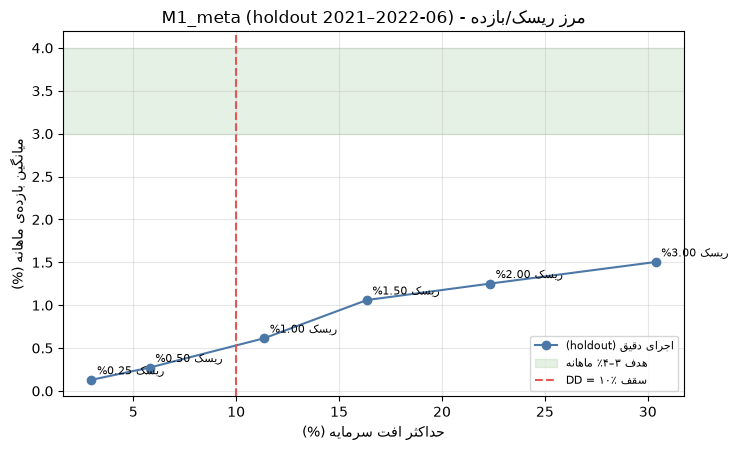

بالاترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ است: ریسک 0.50%


In [11]:
# ==================================================================================
# Cell 9 — مرز ریسک/بازده و بررسی هدف کاربر (۳–۴٪ ماهانه با DD کمتر از ۱۰٪)
# • اجرای دقیق تیک‌به‌تیک روی holdout برای چند سطح ریسک هر معامله
# • شبیه‌سازی بوت‌استرپ بلوک ماهانه برای احتمال رسیدن به هدف و احتمال DD ≥ ۱۰٪
# ==================================================================================
def selected_signals_ho():
    if SELECTED == "M1_meta":
        return ML_RES["M1_meta"]["sig_ho"]
    if SELECTED == "M2_direct":
        return ML_RES["M2_direct"]["sig_ho"]
    return CANDS[SELECTED][WFO[SELECTED]["frozen"]]


SIG_HO = selected_signals_ho()
RISKS = [0.0025, 0.005, 0.01, 0.015, 0.02, 0.03]
_front = []
for _rk in RISKS:
    _prm = PRM0.copy()
    _prm[P_RISK] = _rk
    _r = run_window(SIG_HO, HO_START, HO_END, prm=_prm)
    _front.append(summarize(_r["tr"], _r["eq"], PRM0[P_EQ0], _r["dd_rel"], _r["dd_abs"], HO_START, HO_END,
                            label=f"ریسک {_rk * 100:.2f}%"))
FRONT = pd.DataFrame(_front)[["strategy", "trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "monthly_median_%",
                              "months_>=3%_%", "maxDD_%", "Calmar", "Sharpe_daily_ann"]].round(3)
display(FRONT.set_index("strategy"))

# ---- بوت‌استرپ بلوکی ماهانه روی R معاملات holdout ----
_base_ho = run_window(SIG_HO, HO_START, HO_END)
_tf = trades_frame(_base_ho["tr"])
R_BY_MONTH = {}
for _m, _g in _tf.groupby(_tf["entry_time"].dt.to_period("M")):
    R_BY_MONTH[str(_m)] = _g["R"].values
for _m in pd.period_range("2021-01", "2022-06", freq="M"):
    R_BY_MONTH.setdefault(str(_m), np.zeros(0))
R_BY_MONTH = dict(sorted(R_BY_MONTH.items()))


def mc_monthly(R_by_month, r, B=4000, seed=0):
    rng = np.random.default_rng(seed)
    M = len(R_by_month)
    eq = np.ones(B)
    peak = np.ones(B)
    maxdd = np.zeros(B)
    mret = np.zeros((B, M))
    for j, (_, Rm) in enumerate(R_by_month.items()):
        n = len(Rm)
        if n == 0:
            continue
        draws = rng.integers(0, n, size=(B, n))
        prod = np.prod(np.clip(1 + r * Rm[draws], 1e-9, None), axis=1)
        mret[:, j] = prod - 1
        eq = eq * prod
        peak = np.maximum(peak, eq)
        maxdd = np.maximum(maxdd, 1 - eq / peak)
    return mret, maxdd


_mc = []
for _rk in RISKS:
    mret, mdd = mc_monthly(R_BY_MONTH, _rk)
    _mc.append({"ریسک هر معامله %": _rk * 100,
                "میانه‌ی بازده‌ی ماهانه %": round(100 * np.median(mret), 2),
                "P(ماه ≥ ۳٪)": round(float((mret >= 0.03).mean()), 3),
                "میانه‌ی DD %": round(100 * np.median(mdd), 2),
                "صدک ۹۵ DD %": round(100 * np.quantile(mdd, 0.95), 2),
                "P(DD ≥ ۱۰٪)": round(float((mdd >= 0.10).mean()), 3),
                "P(میانگین ماهانه ≥ ۳٪)": round(float((mret.mean(axis=1) >= 0.03).mean()), 3)})
MC_TABLE = pd.DataFrame(_mc).set_index("ریسک هر معامله %")
display(MC_TABLE)
print("یادداشت: DD در شبیه‌سازی بر پایان هر ماه سنجیده می‌شود (کمی خوش‌بینانه نسبت به DD تیک‌به‌تیک).")

# ---- نمودار مرز: بازده ماهانه در برابر DD ----
fig, ax = plt.subplots(figsize=(7.5, 4.6))
ax.plot(FRONT["maxDD_%"], FRONT["monthly_mean_%"], marker="o", color="#4C78A8", label="اجرای دقیق (holdout)")
for _, _row in FRONT.iterrows():
    ax.annotate(_row["strategy"], (_row["maxDD_%"], _row["monthly_mean_%"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.axhspan(3, 4, color="#54A24B", alpha=0.15, label="هدف ۳–۴٪ ماهانه")
ax.axvline(10, color="#E45756", ls="--", label="سقف DD = ۱۰٪")
ax.set_xlabel("حداکثر افت سرمایه (%)"); ax.set_ylabel("میانگین بازده‌ی ماهانه (%)")
ax.set_title(f"مرز ریسک/بازده - {SELECTED} (holdout 2021–2022-06)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

_best_for_dd = FRONT[FRONT["maxDD_%"] < 10]
print("بالاترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ است:",
      _best_for_dd["strategy"].iloc[-1] if len(_best_for_dd) else "هیچ‌کدام")


## ۱۰ب. ادامهٔ پژوهش (فاز ۲): داده‌ی ۱۶ ساله و خانواده‌های تازه

پس از نتیجهٔ فاز اول (هدف محقق نشد)، پژوهش با این موارد ادامه یافت. کد، پروتکل و نتایج کامل در `research/phase2_eurusd_2007_2022/` است (README فارسی، جدول خلاصه و لاگ بررسی‌های سلامت).

- **داده‌ی تازه:** EURUSD از ۲۰۰۷ تا ۲۰۱۶ (حدود ۲۲۰ میلیون تیک) که در هیچ تصمیمی قبلاً استفاده نشده بود، به‌عنوان **دیسکاوری**؛ بازهٔ ۲۰۱۷–۲۰۲۲ برای **تأیید**.
- **خانواده‌های آزمایش‌شده:** روند Donchian با حد ضرر و ترِیل ATR (۲۰ پیکربندی)، الگوهای ساعتی/نشست (۷۶۸ پیکربندی)، مومنتوم روزانه TSMOM (۸)، یادگیری ماشین روی M5 (۴) و همان ML با ویژگی‌های حجم bid/ask (۲).
- **پروتکل:** انتخاب فقط روی ۲۰۰۷–۲۰۱۶ انجام شد؛ هر کاندیدای مثبت یک‌بار روی ۲۰۱۷–۲۰۲۲ با پارامترهای منجمد تأیید شد.

| خانواده | دیسکاوری (۲۰۰۷–۲۰۱۶) | تأیید (۲۰۱۷–۲۰۲۲) | نتیجه |
|---|---|---|---|
| روند Donchian + ترِیل ATR | بهترین t = ۰٫۰۷ | میانگین R = −۰٫۱۲، t = −۲٫۹۷ | شکست |
| الگوی ساعتی (۷۶۸ پیکربندی) | بهترین t = ۲٫۴۶ (+۱٫۱۴ پیپ) | −۲٫۸۳ پیپ، t = −۸٫۱۶ | شکست |
| TSMOM روزانه | L=60، H=60: R = +۰٫۳۶، n=77 | R = +۰٫۰۵، n=49، t = ۰٫۲۴ | بی‌معنی |
| ML روی M5 (۴ پیکربندی) | خالص منفی (−۰٫۰۴ تا −۰٫۱۰ R)؛ ناخالص +۰٫۰۵ تا +۰٫۱۳ R | گیت رد شد؛ تشخیص منجمد خالص −۰٫۱۰ تا −۰٫۱۷ R | لبهٔ ناخالص هست، هزینه بزرگ‌تر است |
| ML + حجم bid/ask | بدون بهبود نسبت به ML | گیت رد شد | بی‌اثر |

**مرز هزینه** (موتور تیک‌به‌تیک با سیگنال منجمد ۲۰۱۷–۲۰۲۲): با هزینهٔ صفر حدود ۱٫۷٪ ماهانه با DD ≈ ۱۰٪؛ با هزینهٔ پیش‌فرض زیان (حدود −۴٪ ماهانه در ریسک ۰٫۵٪).

**نتیجه:** هدف ۳–۴٪ ماهانه با DD زیر ۱۰٪ در این فاز **به دست نیامد**. هزینهٔ هر معامله (حدود ۱٫۲ تا ۱٫۴ پیپ) از لبهٔ ناخالص ML (حدود ۱ پیپ) بیشتر است و حتی با هزینهٔ صفر هم به هدف نمی‌رسیم. بنابراین این نوت‌بوک گزارش **هدف‌نرسیده** را به‌عنوان نتیجهٔ معتبر ارائه می‌کند؛ هیچ پیکربندی تنظیم‌شده‌ای به‌عنوان «هدف محقق‌شده» معرفی نمی‌شود.


## ۱۰ج. دور ۲ — قاعدهٔ HIPO از PDF: پیاده‌سازی، آزمون، مقایسه با تصاویر و بهینه‌سازی روی دیسکاوری

**منبع قواعد:** PDF «ستاپ پیوت تسویه» (صفحه‌های رندرشده از `Doc/`) و ۲۰ تصویر معامله DAX/GER30 یک‌دقیقه‌ای (از ژانویه تا ژوئن ۲۰۲۶) و یک نمونهٔ NAS100 از همان PDF. متن PDF به‌صورت نوشتار راست‌به‌چپ مخدوش استخراج شد؛ قواعد از صفحه‌های تصویری خوانده شده‌اند.

**منطق ساده (SHORT؛ LONG آینهٔ آن است):**
1. **AB:** حرکت تیز با ≥ ۳ کندل هم‌جهت (یا دو کندل که هرکدام بزرگ‌تر از ATR‌اند)؛ حداکثر ۱ کندل نویز؛ بیش از ۳ کندل فقط اگر اندازه ۲۰۰–۵۰۰٪ ATR باشد.
2. **BC:** اصلاح ۲۰–۵۰٪ بدنهٔ AB با ≥ ۳ کندل؛ سایه‌ها می‌توانند عمیق‌تر باشند ولی A را لمس نمی‌کنند.
3. **CD:** بازگشت به سمت B با **واگرایی قیمتی الزامی** (CD < AB)؛ واگرایی زمانی اختیاری است (فقط نرخ برد را بالا می‌برد).
4. **جعبهٔ نقدینگی:** ارتفاع = |AB| که از C رسم می‌شود؛ بسته‌شدن بدنه‌ی کندلی بیرون جعبه، ستاپ را باطل می‌کند.
5. **کندل سیگنال:** اولین کندل CD که B را می‌شکند و از همهٔ کندل‌های بین B و خودش بالاتر است؛ بدنهٔ کامل یا سایهٔ بالایی کوچک؛ سایهٔ بالایی بزرگ رد می‌شود.
6. **تأیید:** کندل بدنه‌دار با بدنهٔ معتبر (ATR) که زیر کف سیگنال بسته می‌شود → ورود.
7. **حد ضرر** بالای سقف سیگنال؛ **هدف** ۲٫۵R (PDF: ۲٫۵R یا ۳R).

**پیاده‌سازی:** ماشین حالت علّی (causal) روی کندل‌های M1 و تجمیع به TF دلخواه. نسخهٔ اول (v1) باگ داشت: (۱) پس از شکست AB/BC/CD اسکن از `a+1` ادامه نمی‌یافت؛ (۲) پایین‌آمدن جدید در فاز ۲ قبل از سیگنال، BC را باز نمی‌کرد؛ (۳) ماشهٔ زودهنگام CD با کمتر از ۳ کندل BC باعث rewind می‌شد. این سه مورد در v2 اصلاح شد؛ نسخهٔ قبل برای حسابرسی در `research/phase3_hipo_pdf/code/hipo_core_v1_buggy.py` بایگانی شده است.


In [12]:
# Round-2 HIPO detector (v2): causal state machine implementing the PDF pivot-settlement rules.
# SHORT scan = scan_direction(..., +1); LONG = mirror (-1). Parameters: params_vector(**kw).
"""HIPO 'Pivot-Settlement' (ستاپ پیوت تسویه) rule engine — causal state machine on OHLC bars.

Orientation: the scanner treats the setup as a SHORT setup (AB is an up-leg, BC a pull-back,
CD a weaker up-leg, the signal candle breaks B, entry after a body close below the signal low).
LONG setups are the mirror image: the same scanner is run on negated prices.
All thresholds are ATR-relative, so the rules are scale-free (index CFD or FX).
"""
import numpy as np
from numba import njit

# parameter vector indices
P_AB_MIN_BARS, P_AB_MAX_NOISE, P_AB_LONG_LO, P_AB_LONG_HI, P_AB_THREE_MIN, P_AB2_BAR_ATR = 0, 1, 2, 3, 4, 5
P_BC_RET_LO, P_BC_RET_HI, P_BC_MIN_BARS, P_CD_START_ATR = 6, 7, 8, 9
P_SIG_MIN_RANGE, P_SIG_POS_LO, P_SIG_POS_HI, P_SIG_MAX_WICK, P_STRICT_BOX = 10, 11, 12, 13, 14
P_CONF_BODY_ATR, P_CONF_MAX_WAIT, P_SL_BUF_ATR, P_TP_R = 15, 16, 17, 18
N_PARAMS = 19

DEFAULTS = dict(
    AB_MIN_BARS=3, AB_MAX_NOISE=1, AB_LONG_LO=2.0, AB_LONG_HI=5.0, AB_THREE_MIN=1.5, AB2_BAR_ATR=1.0,
    BC_RET_LO=0.20, BC_RET_HI=0.50, BC_MIN_BARS=3, CD_START_ATR=0.5,
    SIG_MIN_RANGE=0.8, SIG_POS_LO=0.30, SIG_POS_HI=0.70, SIG_MAX_WICK=0.35, STRICT_BOX=1.0,
    CONF_BODY_ATR=0.5, CONF_MAX_WAIT=15, SL_BUF_ATR=0.25, TP_R=2.5,
)
_ORDER = ["AB_MIN_BARS", "AB_MAX_NOISE", "AB_LONG_LO", "AB_LONG_HI", "AB_THREE_MIN", "AB2_BAR_ATR",
          "BC_RET_LO", "BC_RET_HI", "BC_MIN_BARS", "CD_START_ATR",
          "SIG_MIN_RANGE", "SIG_POS_LO", "SIG_POS_HI", "SIG_MAX_WICK", "STRICT_BOX",
          "CONF_BODY_ATR", "CONF_MAX_WAIT", "SL_BUF_ATR", "TP_R"]

def params_vector(**kw):
    d = dict(DEFAULTS); d.update(kw)
    return np.array([float(d[k]) for k in _ORDER], dtype=np.float64)

# output columns of scan_short
OUT_COLS = ["entry_idx", "sig_idx", "a_idx", "b_idx", "c_idx", "entry", "sl", "tp",
            "ab_size", "atr", "minor_flag", "bc_bars", "ab_bars", "time_div"]
NOUT = len(OUT_COLS)

@njit(cache=True)
def _ab_valid(O, H, L, C, a, b, ab, atr, P):
    cnt = b - a + 1
    if cnt < 2:
        return False
    if cnt == 2:
        # PDF: two-candle AB is accepted (with discount) when each candle is larger than ATR
        if not (C[a] >= O[a] and C[b] >= O[b]):
            return False
        return (H[a] - L[a] > P[P_AB2_BAR_ATR] * atr) and (H[b] - L[b] > P[P_AB2_BAR_ATR] * atr)
    bull = 0; noise = 0
    for k in range(a, b + 1):
        if C[k] >= O[k]:
            bull += 1
        else:
            noise += 1
    if bull < int(P[P_AB_MIN_BARS]) or noise > int(P[P_AB_MAX_NOISE]):
        return False
    if cnt == 3:
        return ab >= P[P_AB_THREE_MIN] * atr
    # more than three candles: AB must be 200%-500% of ATR (PDF)
    return (ab >= P[P_AB_LONG_LO] * atr) and (ab <= P[P_AB_LONG_HI] * atr)

@njit(cache=True)
def scan_short(O, H, L, C, ATR, P):
    n = C.shape[0]
    out = np.zeros((n // 3 + 10, NOUT))
    k_out = 0
    phase = 0
    a = 0; la = L[0]; b = 0; hb = H[0]
    mlow = np.inf; mh = -np.inf
    c = -1; lc = np.inf; box_top = 0.0
    bodymin = np.inf
    s = -1; ls = 0.0; hs = 0.0; minor = -np.inf; wait = 0
    ab = 0.0
    i = 1
    while i < n:
        atr = ATR[i]
        if not (atr > 0.0):
            i += 1
            continue
        if phase == 0:
            if L[i] < la:                       # new lower low -> new candidate A
                a = i; la = L[i]; b = i; hb = H[i]; mlow = np.inf; mh = -np.inf
                i += 1; continue
            if H[i] > hb:                       # higher high -> candidate B moves up
                b = i; hb = H[i]; mlow = np.inf; mh = -np.inf
                i += 1; continue
            mlow = min(mlow, L[i])              # bar after B
            ab = hb - la
            if ab > 0.0 and (hb - mlow) >= P[P_BC_RET_LO] * ab and (b - a + 1) >= 2:
                if _ab_valid(O, H, L, C, a, b, ab, ATR[b], P):
                    phase = 1; c = -1; lc = np.inf; bodymin = np.inf
                    mh = -np.inf
                    # re-process this bar in phase 1 (it is the first BC candle)
                    continue
                elif (b - a + 1) >= 3:   # complete (>=3 candles) but invalid AB: rewind to bar after A
                    a = a + 1; la = L[a]; b = a; hb = H[a]; mlow = np.inf; mh = -np.inf
                    i = a + 1; continue
                # two-candle AB not yet valid: keep scanning (the impulse may still extend B)
            i += 1
            continue

        if phase == 1:  # ---------------- BC: pull-back from B to C
            if H[i] > hb:                       # B not the top any more -> extend AB
                b = i; hb = H[i]; phase = 0; mlow = np.inf; mh = -np.inf
                i += 1; continue
            if L[i] <= la:                      # BC touches A -> setup fails: rewind to bar after A
                a = a + 1; la = L[a]; b = a; hb = H[a]; phase = 0; mlow = np.inf; mh = -np.inf
                i = a + 1; continue
            bl = min(O[i], C[i])
            if bl < hb - P[P_BC_RET_HI] * ab:   # body closes beyond 50% of AB -> fail: rewind
                a = a + 1; la = L[a]; b = a; hb = H[a]; phase = 0; mlow = np.inf; mh = -np.inf
                i = a + 1; continue
            if L[i] < lc:                       # this bar is the lowest low so far -> C candidate
                lc = L[i]; c = i
            if i > c and H[i] >= lc + P[P_CD_START_ATR] * atr:   # CD starts (rally off the BC low)
                bc_bars = c - b
                ret_body = (hb - bodymin) / ab
                if bc_bars >= int(P[P_BC_MIN_BARS]) and ret_body >= P[P_BC_RET_LO] and ret_body <= P[P_BC_RET_HI]:
                    phase = 2; box_top = lc + ab; s = -1; minor = -np.inf; wait = 0
                    continue                    # re-process this bar in phase 2
                elif bc_bars < int(P[P_BC_MIN_BARS]):
                    pass                        # too early: the bounce may still be part of BC -> keep scanning
                else:   # BC/CD check failed: rewind to the bar after A
                    a = a + 1; la = L[a]; b = a; hb = H[a]; phase = 0; mlow = np.inf; mh = -np.inf
                    i = a + 1; continue
            bodymin = min(bodymin, bl)
            mh = max(mh, H[i])
            i += 1
            continue

        # ---------------- phase 2: CD, signal candle, confirmation candle
        if L[i] < lc and s < 0:            # C extended lower before any signal: back to BC phase
            phase = 1; c = i; lc = L[i]
            bodymin = min(bodymin, min(O[i], C[i])); mh = max(mh, H[i])
            i += 1; continue
        fail = False
        if (H[i] >= box_top and P[P_STRICT_BOX] > 0.5) or C[i] >= box_top:
            fail = True                         # CD >= AB (price divergence violated) or close beyond box
        if L[i] < lc:
            fail = True                         # C broken -> structure invalid
        if fail:
            # restart a new AB candidate from C (the pivot low), rescan from c+1
            a = c; la = lc; b = c; hb = H[c]; phase = 0; mlow = np.inf; mh = -np.inf
            i = c + 1
            continue

        if s < 0:
            if H[i] > hb:
                body_top = max(O[i], C[i])
                hh = (H[i] > mh) or (body_top > mh)          # higher high vs candles between B and i
                rng = H[i] - L[i]
                if hh and rng >= P[P_SIG_MIN_RANGE] * atr and C[i] < box_top:
                    pos = (hb - L[i]) / rng                    # B should sit near the middle of the candle
                    if pos >= P[P_SIG_POS_LO] and pos <= P[P_SIG_POS_HI]:
                        upper = H[i] - body_top
                        if upper <= P[P_SIG_MAX_WICK] * rng:   # no large upper wick (selling pressure)
                            s = i; ls = L[i]; hs = H[i]; minor = -np.inf; wait = 0
            mh = max(mh, H[i])
            i += 1
            continue

        # waiting for confirmation (bars after the signal candle)
        wait += 1
        if C[i] > hs:
            minor = max(minor, H[i])                   # a candle closed above the signal candle
        if (O[i] - C[i]) >= P[P_CONF_BODY_ATR] * atr and C[i] < ls and C[i] < O[i]:
            sl = max(hs, minor) + P[P_SL_BUF_ATR] * atr
            entry = C[i]
            R = sl - entry
            if R > 0.0:
                tp = entry - P[P_TP_R] * R
                if k_out < out.shape[0]:
                    out[k_out, 0] = i; out[k_out, 1] = s; out[k_out, 2] = a; out[k_out, 3] = b
                    out[k_out, 4] = c; out[k_out, 5] = entry; out[k_out, 6] = sl; out[k_out, 7] = tp
                    out[k_out, 8] = ab; out[k_out, 9] = atr
                    out[k_out, 10] = 1.0 if minor > -np.inf else 0.0
                    out[k_out, 11] = c - b; out[k_out, 12] = b - a + 1
                    out[k_out, 13] = 1.0 if (c - b) > (b - a + 1) else 0.0
                k_out += 1
            # one setup at a time: restart the AB search after the signal bar
            phase = 0; a = i; la = L[i]; b = i; hb = H[i]; mlow = np.inf; mh = -np.inf
            i += 1
            continue
        if C[i] >= box_top or wait > P[P_CONF_MAX_WAIT]:
            a = c; la = lc; b = c; hb = H[c]; phase = 0; mlow = np.inf; mh = -np.inf
            i = c + 1
            continue
        i += 1
    return out[:k_out]

def scan_direction(O, H, L, C, ATR, P, direction):
    """direction=+1 -> short setups (AB up); -1 -> long setups (mirror). Returns (k, NOUT) array."""
    if direction > 0:
        res = scan_short(O, H, L, C, ATR, P)
        return res
    res = scan_short(-O, -L, -H, -C, ATR, P)     # mirror: negate and swap high/low
    if len(res):
        res = res.copy()
        for col in (5, 6, 7):
            res[:, col] = -res[:, col]
    return res

def atr_wilder(H, L, C, n=14):
    H = np.asarray(H, float); L = np.asarray(L, float); C = np.asarray(C, float)
    prev_c = np.concatenate([[C[0]], C[:-1]])
    tr = np.maximum(H - L, np.maximum(np.abs(H - prev_c), np.abs(L - prev_c)))
    out = np.full(len(C), np.nan)
    if len(C) <= n:
        return out
    out[n] = tr[1:n+1].mean()
    a = 1.0 / n
    for i in range(n + 1, len(C)):
        out[i] = out[i-1] + a * (tr[i] - out[i-1])
    return out


### آزمون‌های قواعد (سنتتیک، نمونهٔ NAS، پایداری در برابر پیشوند)

این سلول ۲۱ آزمون سنتتیک و نمونهٔ NAS را اجرا می‌کند و آزمون پایداری جدیدی اضافه کرده است: نمونهٔ NAS با پیشوند تصادفی (۰، ۳، ۶، ۱۲، ۲۵ کندل × ۶ تکرار) باید همچنان تشخیص داده شود. نمونهٔ NAS از ۱۴ کندل منتخب ساخته شده، نه از کل سری؛ پس فقط «تطابق ساختار» را می‌سنجد، نه تشخیص کامل روی داده.


In [13]:
# Rule tests (synthetic cases, NAS golden window, prefix robustness). Runs without writing files.
def run_hipo_rule_tests():
    import numpy as np

    P = params_vector()

    def arrays(bars):
        a = np.array(bars, float)
        return a[:, 0].copy(), a[:, 1].copy(), a[:, 2].copy(), a[:, 3].copy()

    def run(bars, atr, direction=+1, **kw):
        O, H, L, C = arrays(bars)
        ATR = np.full(len(bars), float(atr))
        res = scan_direction(O, H, L, C, ATR, params_vector(**kw), direction)
        return [dict(zip(OUT_COLS, r)) for r in res]

    BASE = [
        (100, 108, 100, 107),   # 0  A-bar (bull)
        (107, 120, 106, 119),   # 1  AB (bull)
        (119, 132, 118, 131),   # 2  AB (bull)
        (131, 145, 130, 144),   # 3  B-bar: high 145 (bull)
        (144, 144.5, 134, 135), # 4  BC (bear)  body retrace 22%
        (135, 137, 131.5, 132.5),  # 5 BC (bear)
        (132.5, 133.5, 130, 131.5),# 6 BC (bear) C = 130 (lowest low)
        (131.5, 140, 131, 139.5),  # 7 CD (bull) reversal
        (142, 149, 140, 148),   # 8  signal candle: breaks B(145), straddles B, small upper wick
        (148, 150, 146, 149.5), # 9  candle closes above signal high -> minor high 150
        (147.5, 148, 136, 137), # 10 confirmation: body closes below signal low 140
    ]
    results = {}
    def check(name, cond, detail=""):
        results[name] = bool(cond)
        print(("PASS " if cond else "FAIL ") + name + (("  " + detail) if detail else ""))

    # ---- positive base case -------------------------------------------------------------
    r = run(BASE, 10.0)
    check("base: exactly one short signal", len(r) == 1, f"n={len(r)}")
    if r:
        s = r[0]
        check("base: entry bar = confirmation bar", s["entry_idx"] == 10)
        check("base: structure A,B,C,S = 0,3,6,8", (s["a_idx"], s["b_idx"], s["c_idx"], s["sig_idx"]) == (0, 3, 6, 8))
        check("base: entry = close of confirmation (137)", abs(s["entry"] - 137.0) < 1e-9)
        check("base: SL above signal high incl. minor high 150 + 0.25 ATR = 152.5", abs(s["sl"] - 152.5) < 1e-9, f"sl={s['sl']}")
        check("base: TP = entry - 2.5R = 98.25", abs(s["tp"] - 98.25) < 1e-9, f"tp={s['tp']:.3f}")
        check("base: AB has 4 candles (>3 -> 200-500% ATR rule), size 45", s["ab_bars"] == 4 and abs(s["ab_size"] - 45) < 1e-9)

    # ---- mirror (long setup) -----------------------------------------------------------
    M = [(300 - o, 300 - l, 300 - h, 300 - c) for (o, h, l, c) in BASE]    # reflect around 150
    r = run(M, 10.0, direction=-1)
    check("mirror: one long signal with mirrored levels", len(r) == 1 and abs(r[0]["entry"] - 163.0) < 1e-9
          and abs(r[0]["sl"] - 147.5) < 1e-9 and abs(r[0]["tp"] - 201.75) < 1e-9,
          f"{[(x['entry'], x['sl'], x['tp']) for x in r]}")

    # ---- negative tests (each must remove the trade at bar 10) -------------------------
    def mutate(idx, new):
        b = list(BASE); b[idx] = new; return b

    cases = {
      "AB: two candles, each < ATR -> reject":
          [(100, 108, 100, 107), (107, 145, 107, 144)] + BASE[4:],          # bar0 range 8 < ATR 10
      "AB: >3 candles but size > 5 ATR (60 > 50) -> reject":
          mutate(3, (131, 160, 130, 144)),
      "BC: body closes beyond 50% of AB -> reject":
          mutate(6, (132.5, 133.5, 130, 121)),
      "BC: wick touches A (99.5 <= 100) -> reject":
          mutate(6, (132.5, 133.5, 99.5, 131.5)),
      "CD >= AB (box top 175 broken) -> reject":
          mutate(7, (131.5, 180, 131, 179)),
      "signal: large upper wick -> reject":
          mutate(8, (141, 149, 140, 141.5)),
      "signal: range < 0.8 ATR -> reject (bar 9 then cannot be signal)":
          mutate(8, (142, 146, 141, 145)),
      "confirmation body < 0.5 ATR -> no entry":
          mutate(10, (137.5, 148, 136, 136.5)),
      "close beyond liquidity box before entry -> setup fails":
          mutate(9, (148, 178, 146, 176)),
    }
    for name, bars in cases.items():
        r = run(bars, 10.0)
        ok = not any(x["entry_idx"] == 10 for x in r)
        check(name, ok, f"signals={[(x['entry_idx'], round(x['entry'],2)) for x in r]}")

    # ---- golden: NAS100 example from the PDF (bars digitised from the chart, ATR14=14.02) --
    NAS = [
     (30702.37, 30718.56, 30697.16, 30714.09),  # b0  20:51 A-candle (low = A)
     (30714.47, 30720.98, 30711.86, 30720.98),  # b1
     (30721.72, 30734.93, 30721.72, 30733.07),  # b2
     (30733.07, 30755.40, 30730.28, 30746.65),  # b3  B-candle (high = B = 30755.4)
     (30746.28, 30748.14, 30737.91, 30740.51),  # b4  BC
     (30739.95, 30742.37, 30732.70, 30736.42),  # b5  BC
     (30735.67, 30739.77, 30718.56, 30733.07),  # b6  C (low 30718.56)
     (30733.81, 30750.00, 30728.60, 30745.53),  # b7  CD
     (30745.91, 30748.51, 30743.30, 30748.51),  # b8  small candle below B
     (30748.88, 30763.95, 30746.65, 30760.80),  # b9  SIGNAL candle (high breaks B, low 30746.65)
     (30762.09, 30769.72, 30756.88, 30766.56),  # b10 D-candle
     (30766.56, 30768.42, 30758.00, 30760.98),  # b11
     (30760.23, 30762.65, 30752.98, 30756.51),  # b12
     (30755.95, 30760.05, 30734.93, 30742.93),  # b13 CONFIRMATION (closes below 30746.65)
    ]
    r = run(NAS, 14.02)
    check("NAS golden: one short signal at confirmation candle b13", len(r) == 1 and r[0]["entry_idx"] == 13,
          f"{[(x['entry_idx'], x['sig_idx']) for x in r]}")
    if r:
        s = r[0]
        print("   NAS golden detail:", {k: round(s[k], 2) for k in ["entry", "sl", "tp", "ab_size", "minor_flag"]},
              "R=", round(s["sl"] - s["entry"], 2), "| trader drew SL 30774.55, entry 30743.13, TP 30676.88 (2.1R)")
        check("NAS golden: entry within 0.5 pt of chart entry (30743.13)", abs(s["entry"] - 30743.13) < 0.5)
        check("NAS golden: SL within 2 pt of drawn SL (30774.55)", abs(s["sl"] - 30774.55) < 2.0, f"sl={s['sl']:.2f}")
        check("NAS golden: TP at 2.5R (PDF) vs drawn 2.1R", abs((s["entry"] - s["tp"]) / (s["sl"] - s["entry"]) - 2.5) < 1e-6)

    print("\nSUMMARY:", sum(results.values()), "/", len(results), "checks passed")

    # ---- prefix robustness (added in round 2): NAS window preceded by random-walk bars (6 reps per length)
    _pass = []
    for _p in (0, 3, 6, 12, 25):
        for _rep in range(6):
            _rng = np.random.default_rng(1000 * _p + _rep)
            _px, _pre = 30700.0, []
            for _i in range(_p):
                _o = _px; _c = _px + float(_rng.normal(0, 8.0))
                _h = max(_o, _c) + abs(float(_rng.normal(0, 4.0)))
                _l = min(_o, _c) - abs(float(_rng.normal(0, 4.0)))
                _pre.append((_o, _h, _l, _c)); _px = _c
            _rr = run(_pre + NAS, 14.02)
            _pass.append(any(s["entry_idx"] == _p + 13 for s in _rr))
    check("NAS golden still found after random prefixes 0/3/6/12/25 (6 reps each)", all(_pass),
          f"{sum(_pass)}/{len(_pass)}")
    return results

r2_test_results = run_hipo_rule_tests()
import json as _json
if os.path.isdir(os.path.join('research', 'phase3_hipo_pdf', 'results')):
    _json.dump(r2_test_results, open(os.path.join('research', 'phase3_hipo_pdf', 'results', 'test_results_v2.json'), 'w'), indent=1)
print(f"\n{sum(r2_test_results.values())}/{len(r2_test_results)} checks PASS")
print('FAILED:', [k for k, v in r2_test_results.items() if not v] or 'none')


PASS base: exactly one short signal  n=1
PASS base: entry bar = confirmation bar
PASS base: structure A,B,C,S = 0,3,6,8
PASS base: entry = close of confirmation (137)
PASS base: SL above signal high incl. minor high 150 + 0.25 ATR = 152.5  sl=152.5
PASS base: TP = entry - 2.5R = 98.25  tp=98.250
PASS base: AB has 4 candles (>3 -> 200-500% ATR rule), size 45
PASS mirror: one long signal with mirrored levels  [(np.float64(163.0), np.float64(147.5), np.float64(201.75))]
PASS AB: two candles, each < ATR -> reject  signals=[]
PASS AB: >3 candles but size > 5 ATR (60 > 50) -> reject  signals=[]
PASS BC: body closes beyond 50% of AB -> reject  signals=[]
PASS BC: wick touches A (99.5 <= 100) -> reject  signals=[]
PASS CD >= AB (box top 175 broken) -> reject  signals=[]
PASS signal: large upper wick -> reject  signals=[]
PASS signal: range < 0.8 ATR -> reject (bar 9 then cannot be signal)  signals=[]
PASS confirmation body < 0.5 ATR -> no entry  signals=[]
PASS close beyond liquidity box befor

### مقایسه با تصاویر معامله (DAX/GER30)

کندل‌ها و سطوح ترسیم‌شده (ورود، SL، TP) با دیجیتال‌سازی پیکسلی از تصاویر استخراج شده‌اند (`data/dax_candles_px.csv`، `data/dax_levels_px.csv`، کد در `code/dax_digitize.py`). از ۲۰ تصویر، **۱۵ نمودار** ناحیهٔ ریسک قابل‌اندازه‌گیری دارند (≥ ۲۰ پیکسل و ≥ ۴۰ کندل)؛ پنج نمودار (۰۱-۰۸، ۰۵-۰۵، ۰۵-۲۰، ۰۵-۲۲، ۰۵-۲۶) ناحیه‌ای با ارتفاع ۰–۱ پیکسل یا تعداد کندل بسیار کم دارند و کنار گذاشته شده‌اند.

**معیار تطابق:** سیگنال هم‌جهت با ورود ترسیم‌شده، با فاصلهٔ افقی ≤ ۰٫۷ فاصلهٔ کندل. برای هر تطابق، خطای SL بر حسب ATR و نسبت R (ریسک ما ÷ ریسک ترسیم‌شده) گزارش می‌شود.


In [14]:
import io, os, urllib.request
import numpy as np, pandas as pd

R2_DIR = os.path.join("research", "phase3_hipo_pdf")
R2_RAW = "https://raw.githubusercontent.com/khajavy8056/Hippoalgorithm-/arena/bde522c5-hippoalgorithm/research/phase3_hipo_pdf"

def r2_read_csv(sub, name):
    local = os.path.join(R2_DIR, sub, name)
    if os.path.exists(local):
        return pd.read_csv(local)
    raw = urllib.request.urlopen(f"{R2_RAW}/{sub}/{name}", timeout=60).read()
    return pd.read_csv(io.BytesIO(raw))

r2_cands = r2_read_csv("data", "dax_candles_px.csv")
r2_lv = r2_read_csv("data", "dax_levels_px.csv")
r2_comp = r2_lv[r2_lv.drawn_dir.isin(["SHORT", "LONG"]) & (r2_lv.drawn_R_px >= 20) & (r2_lv.n_candles >= 40)].reset_index(drop=True)

def r2_chart_arrays(name):
    c = r2_cands[r2_cands.image == name].sort_values("k")
    bu = c.bullish.values == 1
    top, bot = c.body_top.values.astype(float), c.body_bot.values.astype(float)
    wt, wb = c.wick_top.values.astype(float), c.wick_bot.values.astype(float)
    # pixel-price convention: price = -y (image y grows downwards)
    O = np.where(bu, -bot, -top); C = np.where(bu, -top, -bot)
    H, L = -wt, -wb
    return c.x.values.astype(float), O, H, L, C

def r2_detect(name, **kw):
    x, O, H, L, C = r2_chart_arrays(name)
    ATR = atr_wilder(H, L, C, 14)
    P_CH = params_vector(**kw)
    out = []
    for d in (+1, -1):                       # +1 = SHORT scan, -1 = LONG scan (mirror inside scan_direction)
        for row in scan_direction(O, H, L, C, ATR, P_CH, d):
            k = int(row[0])
            out.append(dict(dir=(-1 if d > 0 else 1), k=k, x=x[k], entry=row[5], sl=row[6], tp=row[7], atr=ATR[k]))
    return out

def r2_match_table(**kw):
    rows = []
    for _, r in r2_comp.iterrows():
        dsign = -1 if r.drawn_dir == "SHORT" else 1
        sigs = r2_detect(r.image, **kw)
        same = [s for s in sigs if s["dir"] == dsign and abs(s["x"] - r.drawn_x) <= 0.7 * r.spacing_px]
        row = dict(chart=r.image.replace("DAX-", "")[:-4], drawn=r.drawn_dir, drawn_x=int(r.drawn_x),
                   detector_signals=len(sigs), entry_matched=len(same) > 0,
                   sl_err_ATR=np.nan, R_ratio=np.nan)
        if same:
            s = min(same, key=lambda q: abs(q["x"] - r.drawn_x))
            row["sl_err_ATR"] = round((s["sl"] + r.sl_y) / s["atr"], 2)      # drawn SL in pixel-price = -sl_y
            row["R_ratio"] = round(abs(s["entry"] - s["sl"]) / r.drawn_R_px, 2)
        rows.append(row)
    return pd.DataFrame(rows)

r2_dax = r2_match_table()
if os.path.isdir(os.path.join(R2_DIR, "results")):
    r2_dax.to_csv(os.path.join(R2_DIR, "results", "dax_match_v2.csv"), index=False)
print(f"Comparable drawn charts: {len(r2_comp)} (of {len(r2_lv)} images)")
print(r2_dax.to_string(index=False))
print(f"\nEntry matched (same direction, within 0.7 candle spacing): {int(r2_dax.entry_matched.sum())} of {len(r2_dax)}")
print("Mismatches (drawn entry, no same-direction signal):", int((~r2_dax.entry_matched).sum()))

print("\nSensitivity (diagnostic on the trader's charts only, NOT used for any EURUSD decision):")
SENS = {
    "default v2 rules": {},
    "SIG_POS 0..1 (no half-range rule)": dict(SIG_POS_LO=0.0, SIG_POS_HI=1.0),
    "SIG_MIN_RANGE 0": dict(SIG_MIN_RANGE=0.0),
    "SIG_MAX_WICK 1": dict(SIG_MAX_WICK=1.0),
    "CONF_BODY_ATR 0": dict(CONF_BODY_ATR=0.0),
    "CONF_MAX_WAIT 60": dict(CONF_MAX_WAIT=60),
    "AB_MAX_NOISE 2": dict(AB_MAX_NOISE=2),
    "AB_LONG_HI 8": dict(AB_LONG_HI=8.0),
    "BC_RET_HI 0.7": dict(BC_RET_HI=0.7),
    "STRICT_BOX 0": dict(STRICT_BOX=0.0),
    "ALL relaxed together": dict(SIG_POS_LO=0.0, SIG_POS_HI=1.0, SIG_MIN_RANGE=0.0, SIG_MAX_WICK=1.0,
                                 CONF_BODY_ATR=0.0, CONF_MAX_WAIT=60, AB_MAX_NOISE=2, AB_LONG_HI=8.0,
                                 BC_RET_HI=0.7, STRICT_BOX=0.0),
}
for _name, _kw in SENS.items():
    _t = r2_match_table(**_kw)
    print(f"  {_name:36s} matched {int(_t.entry_matched.sum()):2d}/{len(_t)}   detector signals {int(_t.detector_signals.sum())}")


Comparable drawn charts: 15 (of 20 images)
               chart drawn  drawn_x  detector_signals  entry_matched  sl_err_ATR  R_ratio
 2026-03-31-002-3.2R SHORT      839                 0          False         NaN      NaN
 2026-04-26-001-5.3R  LONG     1004                 0          False         NaN      NaN
 2026-05-08-001-1.3R SHORT     1161                 0          False         NaN      NaN
 2026-05-11-001-1.6R SHORT      795                 0          False         NaN      NaN
2026-05-13-001-13.1R  LONG      560                 0          False         NaN      NaN
 2026-05-13-002-2.2R  LONG      886                 0          False         NaN      NaN
 2026-05-15-001-5.5R SHORT      629                 0          False         NaN      NaN
 2026-05-19-001-2.1R SHORT      648                 0          False         NaN      NaN
   2026-05-21-001-SL SHORT      765                 1           True       -0.38     0.89
2026-05-28-001-12.9R  LONG      307                 0    

  SIG_MIN_RANGE 0                      matched  1/15   detector signals 1
  SIG_MAX_WICK 1                       matched  1/15   detector signals 1
  CONF_BODY_ATR 0                      matched  0/15   detector signals 1
  CONF_MAX_WAIT 60                     matched  1/15   detector signals 1


  AB_MAX_NOISE 2                       matched  1/15   detector signals 1
  AB_LONG_HI 8                         matched  1/15   detector signals 1
  BC_RET_HI 0.7                        matched  1/15   detector signals 1


  STRICT_BOX 0                         matched  1/15   detector signals 1
  ALL relaxed together                 matched  0/15   detector signals 8


### داده‌ی M1 دیسکاوری (۲۰۰۷–۲۰۱۶) و پروتکل

**قاعدهٔ پروتکل:** انتخاب فقط روی ۲۰۰۷–۲۰۱۶ انجام می‌شود. بازهٔ ۲۰۱۷–۲۰۲۲ (holdout) در این بخش **بارگذاری نمی‌شود**. ETL، تیک‌های هر سال را جریانی از FX-Data می‌خواند، M1 بید/اسک می‌سازد و تیک‌ها را نگه نمی‌دارد. اگر کش محلی موجود باشد، دوباره دانلود نمی‌شود. موتور تیک‌به‌تیک راند ۱ (سلول‌های بالاتر) همچنان مرجع آزمون نهایی است.


In [15]:
# M1 bid/ask bar helpers (from m1bars.py) and discovery ETL (round-1 parser reused)
import numpy as np, glob, os
from numba import njit

MS_MIN = 60_000
MS_DAY = 86_400_000
PRICE_SCALE = 1e5          # stored bid/ask are integers scaled by 1e5 (EURUSD 5-decimal)

@njit(cache=True)
def m1_bars_bidask(ts, bid, ask, scale):
    """Minute OHLC of bid and ask from sorted ticks. Returns arrays trimmed to the bars that exist."""
    n = ts.shape[0]
    key = np.empty(n, np.int64)
    bo = np.empty(n); bh = np.empty(n); bl = np.empty(n); bc = np.empty(n)
    ao = np.empty(n); ah = np.empty(n); al = np.empty(n); ac = np.empty(n)
    cnt = np.empty(n, np.int64)
    m = -1
    cur = -1
    for i in range(n):
        k = ts[i] // 60000
        b = bid[i] / scale
        a = ask[i] / scale
        if k != cur:
            m += 1; cur = k
            key[m] = k
            bo[m] = b; bh[m] = b; bl[m] = b; bc[m] = b
            ao[m] = a; ah[m] = a; al[m] = a; ac[m] = a
            cnt[m] = 0
        else:
            if b > bh[m]: bh[m] = b
            if b < bl[m]: bl[m] = b
            bc[m] = b
            if a > ah[m]: ah[m] = a
            if a < al[m]: al[m] = a
            ac[m] = a
        cnt[m] += 1
    m += 1
    return key[:m], bo[:m], bh[:m], bl[:m], bc[:m], ao[:m], ah[:m], al[:m], ac[:m], cnt[:m]

def bars_from_month_files(files):
    out = [[] for _ in range(10)]
    for f in files:
        z = np.load(f)
        res = m1_bars_bidask(z["ts"], z["bid"], z["ask"], PRICE_SCALE)
        for j, arr in enumerate(res):
            out[j].append(arr)
    return [np.concatenate(x) for x in out]

def save_bars(path, cols):
    names = ["key", "bo", "bh", "bl", "bc", "ao", "ah", "al", "ac", "cnt"]
    np.savez(path, **dict(zip(names, cols)))

def load_bars(path):
    z = np.load(path)
    return [z[k] for k in ["key", "bo", "bh", "bl", "bc", "ao", "ah", "al", "ac", "cnt"]]

def weekday_tow(key):
    """key = minute index since epoch -> (weekday Mon=0..Sun=6, ms of week)"""
    ms = key * MS_MIN
    d = ms // MS_DAY
    wd = (d + 3) % 7
    tow = wd * MS_DAY + (ms % MS_DAY)
    return wd, tow


import subprocess, tarfile

M1_DIR = os.path.join(CACHE_DIR, "m1_bidask_r2")
os.makedirs(M1_DIR, exist_ok=True)
TICK_SCALE = 100000.0
FXDATA_REPO = "FX-Data/FX-Data-EURUSD-DS"

def stream_year_to_m1(year, out_path):
    """Stream one FX-Data yearly branch with curl (requests fails TLS to codeload here), parse ticks, build M1 bid/ask bars."""
    url = f"https://codeload.github.com/{FXDATA_REPO}/tar.gz/refs/heads/EURUSD-{year}"
    proc = subprocess.Popen(["curl", "-sSfL", "--retry", "3", "--retry-delay", "5", "-m", "3000", url],
                            stdout=subprocess.PIPE)
    tf = tarfile.open(fileobj=proc.stdout, mode="r|gz")
    TS, BID, ASK = [], [], []
    for m in tf:
        if not (m.isfile() and m.name.endswith("_ticks.csv")):
            continue
        data = tf.extractfile(m).read()
        if not data:
            continue
        buf = np.frombuffer(data, dtype=np.uint8)
        ts, bid, ask, bv, av = parse_tick_csv(buf, TICK_SCALE)     # round-1 numba parser (cell above)
        if len(ts) == 0:
            continue
        keep = ~((bid > ask) | (bid <= 0) | (ask <= 0))           # drop crossed / non-positive quotes
        TS.append(ts[keep]); BID.append(bid[keep].astype(np.int32)); ASK.append(ask[keep].astype(np.int32))
    proc.stdout.close(); proc.kill()
    ts = np.concatenate(TS); bid = np.concatenate(BID); ask = np.concatenate(ASK)
    order = np.argsort(ts, kind="stable")
    ts, bid, ask = ts[order], bid[order], ask[order]
    cols = m1_bars_bidask(ts, bid, ask, TICK_SCALE)
    save_bars(out_path, cols)
    return len(ts)

def ensure_m1_years(years):
    for y in years:
        p = os.path.join(M1_DIR, f"m1_{y}.npz")
        if not os.path.exists(p):
            print(f"{y}: streaming FX-Data (no cache) ...", flush=True)
            n = stream_year_to_m1(y, p)
            print(f"{y}: {n:,} ticks -> M1 bars saved", flush=True)
        else:
            print(f"{y}: M1 bars from cache", flush=True)

ensure_m1_years(range(2007, 2017))      # discovery only


2007: M1 bars from cache


2008: M1 bars from cache


2009: M1 bars from cache


2010: M1 bars from cache


2011: M1 bars from cache


2012: M1 bars from cache


2013: M1 bars from cache


2014: M1 bars from cache


2015: M1 bars from cache


2016: M1 bars from cache


### موتور اجرای کندلی و معیارها (سیگنال → معامله روی M1 bid/ask)

ورود روی باز کندل بعدی M1 با اسپرد واقعی bid/ask، کارمزد ۳٫۵ دلار به ازای هر لات و لغزش ۰٫۱ پیپ هر طرف، حد ضرر/هدف روی قیمت میانی سیگنال (قیمت‌های SL/TP داخل ماشین سیگنال). حداکثر اسپرد ۲ پیپ. نتیجه‌ها به‌صورت R و بازدهی ماهانهٔ هندسی با DD حداکثر گزارش می‌شوند.


In [16]:
# Bar-level executor (exec_bar.py) and helpers: signals per TF, trade simulation on M1 bid/ask, metrics
import numpy as np, pandas as pd
from numba import njit
"""Bar-level (M1 bid/ask) execution of HIPO signals. One position at a time, risk-based sizing."""
import numpy as np
from numba import njit

PIP = 1e-4
UNITS_PER_LOT = 100_000.0
MS_DAY = 86_400_000
MS_MIN = 60_000

# executor parameter vector
E_EQ0, E_RISK, E_MAXLEV, E_COMM, E_SLIP, E_MAXSPREAD, E_MAXHOLD, E_NOENTRY_TOW, E_FCLOSE_TOW, E_MINLOT = range(10)
def exec_params(equity=10_000.0, risk=0.005, maxlev=30.0, comm=3.5, slip_pips=0.1, max_spread_pips=2.0,
                max_hold_min=1440, minlot=0.01):
    p = np.zeros(10)
    p[E_EQ0] = equity; p[E_RISK] = risk; p[E_MAXLEV] = maxlev; p[E_COMM] = comm
    p[E_SLIP] = slip_pips * PIP; p[E_MAXSPREAD] = max_spread_pips * PIP
    p[E_MAXHOLD] = max_hold_min
    p[E_NOENTRY_TOW] = 4 * MS_DAY + 20 * 3_600_000          # Fri 20:00 UTC
    p[E_FCLOSE_TOW] = 4 * MS_DAY + 20 * 3_600_000 + 30 * MS_MIN  # Fri 20:30 UTC
    p[E_MINLOT] = minlot
    return p

TR_COLS = ["entry_k", "exit_k", "dir", "fill", "exit_px", "sl", "tp", "lots", "pnl", "R", "reason", "equity_after"]
REASON = {0: "SL", 1: "TP", 2: "TIME", 3: "WEEKEND"}

@njit(cache=True)
def _tow_ms(key_min):
    ms = key_min * 60000
    d = ms // 86400000
    wd = (d + 3) % 7
    return wd * 86400000 + (ms % 86400000)

@njit(cache=True)
def exec_bars(key, bo, bh, bl, bc, ao, ah, al, ac, s_k, s_dir, s_entry, s_sl, s_tp, prm):
    """s_k: entry bar index (sorted), s_dir: +1 long / -1 short, s_entry/s_sl/s_tp: MID prices."""
    n = key.shape[0]
    ns = s_k.shape[0]
    out = np.full((ns, 12), np.nan)
    eq = prm[E_EQ0]
    risk = prm[E_RISK]; maxlev = prm[E_MAXLEV]; comm = prm[E_COMM]; slip = prm[E_SLIP]
    maxsp = prm[E_MAXSPREAD]; maxhold = int(prm[E_MAXHOLD]); fclose = prm[E_FCLOSE_TOW]
    noentry = prm[E_NOENTRY_TOW]; minlot = prm[E_MINLOT]
    busy_until = -1
    nt = 0
    for q in range(ns):
        k = s_k[q]
        if k <= busy_until or k >= n - 1:
            continue
        d = s_dir[q]
        hs = 0.5 * (ac[k] - bc[k])                 # half spread at entry bar
        if (ac[k] - bc[k]) > maxsp:
            continue
        if _tow_ms(key[k]) >= noentry:
            continue
        if d < 0:                                  # SHORT: sell at bid, stop/target are buy-side (ask)
            fill = bc[k] - slip
            sl_t = s_sl[q] + hs; tp_t = s_tp[q] + hs
            R = sl_t - fill
        else:                                      # LONG: buy at ask
            fill = ac[k] + slip
            sl_t = s_sl[q] - hs; tp_t = s_tp[q] - hs
            R = fill - sl_t
        if not (R > 0.0):
            continue
        lots = np.floor(risk * eq / (R * UNITS_PER_LOT) / minlot) * minlot
        if lots < minlot:
            lots = minlot
        if lots * UNITS_PER_LOT * fill > maxlev * eq:      # leverage cap
            lots = np.floor(maxlev * eq / (UNITS_PER_LOT * fill) / minlot) * minlot
            if lots < minlot:
                continue
        # simulate on subsequent bars
        exit_j = -1; exit_px = np.nan; reason = -1
        j = k + 1
        while j < n:
            if _tow_ms(key[j]) >= fclose and key[j] - key[k] >= 0:
                # forced weekend close at bar close
                exit_px = (ac[j] + slip) if d < 0 else (bc[j] - slip)
                exit_j = j; reason = 3; break
            if j - k >= maxhold:
                exit_px = (ac[j] + slip) if d < 0 else (bc[j] - slip)
                exit_j = j; reason = 2; break
            if d < 0:
                sl_hit = ah[j] >= sl_t
                tp_hit = al[j] <= tp_t
                if sl_hit:
                    exit_px = sl_t + slip; exit_j = j; reason = 0; break     # SL first if both (conservative)
                if tp_hit:
                    exit_px = tp_t; exit_j = j; reason = 1; break
            else:
                sl_hit = bl[j] <= sl_t
                tp_hit = bh[j] >= tp_t
                if sl_hit:
                    exit_px = sl_t - slip; exit_j = j; reason = 0; break
                if tp_hit:
                    exit_px = tp_t; exit_j = j; reason = 1; break
            j += 1
        if exit_j < 0:
            break                                  # data ended with an open position
        if d < 0:
            gross = (fill - exit_px) * UNITS_PER_LOT * lots
        else:
            gross = (exit_px - fill) * UNITS_PER_LOT * lots
        cost = 2.0 * comm * lots
        pnl = gross - cost
        eq = eq + pnl
        Rreal = pnl / (risk * (eq - pnl) if False else (risk * (eq - pnl)))
        out[nt, 0] = k; out[nt, 1] = exit_j; out[nt, 2] = d; out[nt, 3] = fill; out[nt, 4] = exit_px
        out[nt, 5] = sl_t; out[nt, 6] = tp_t; out[nt, 7] = lots; out[nt, 8] = pnl; out[nt, 9] = Rreal
        out[nt, 10] = reason; out[nt, 11] = eq
        nt += 1
        busy_until = exit_j
    return out[:nt]

def mid_bars(bo, bh, bl, bc, ao, ah, al, ac):
    return ((bo + ao) / 2, (bh + ah) / 2, (bl + al) / 2, (bc + ac) / 2)

import numpy as np
import pandas as pd
from numba import njit

@njit(cache=True)
def resample_bidask(key, bo, bh, bl, bc, ao, ah, al, ac, tf):
    n = key.shape[0]
    rk = np.empty(n, np.int64)
    R = np.empty((n, 8))
    m = -1; cur = -1
    for i in range(n):
        bk = key[i] // tf
        if bk != cur:
            m += 1; cur = bk
            rk[m] = bk * tf                     # bucket start minute
            R[m, 0] = bo[i]; R[m, 1] = bh[i]; R[m, 2] = bl[i]; R[m, 3] = bc[i]
            R[m, 4] = ao[i]; R[m, 5] = ah[i]; R[m, 6] = al[i]; R[m, 7] = ac[i]
        else:
            if bh[i] > R[m, 1]: R[m, 1] = bh[i]
            if bl[i] < R[m, 2]: R[m, 2] = bl[i]
            R[m, 3] = bc[i]
            if ah[i] > R[m, 5]: R[m, 5] = ah[i]
            if al[i] < R[m, 6]: R[m, 6] = al[i]
            R[m, 7] = ac[i]
    m += 1
    return rk[:m], R[:m, 0].copy(), R[:m, 1].copy(), R[:m, 2].copy(), R[:m, 3].copy(), \
        R[:m, 4].copy(), R[:m, 5].copy(), R[:m, 6].copy(), R[:m, 7].copy()

def signals_for_tf(m1, tf, prm_kw):
    """Detect HIPO setups on TF-minute mid bars; return signals mapped to M1 entry indices."""
    key, bo, bh, bl, bc, ao, ah, al, ac, cnt = m1
    rk, RBO, RBH, RBL, RBC, RAO, RAH, RAL, RAC = resample_bidask(key, bo, bh, bl, bc, ao, ah, al, ac, tf)
    mo, mh, ml, mc = (RBO + RAO) / 2, (RBH + RAH) / 2, (RBL + RAL) / 2, (RBC + RAC) / 2
    atr = atr_wilder(mh, ml, mc, 14)
    P = params_vector(**prm_kw)
    rs = []
    for d in (+1, -1):
        r = scan_direction(mo, mh, ml, mc, atr, P, d)
        if len(r):
            r = np.column_stack([r, np.full(len(r), -d, float)])   # col 14: trade dir (-1 short, +1 long)
            rs.append(r)
    if not rs:
        return None
    S = np.vstack(rs)
    S = S[np.argsort(S[:, 0], kind="stable")]
    # map TF-bar entry index -> M1 index of the last minute of that bucket (bar close time)
    close_min = rk[S[:, 0].astype(np.int64)] + tf - 1
    k_m1 = np.searchsorted(key, close_min, side="right") - 1
    keep = (k_m1 >= 0) & (key[np.clip(k_m1, 0, len(key)-1)] == close_min)
    S = S[keep]; k_m1 = k_m1[keep]
    order = np.argsort(k_m1, kind="stable")
    return dict(k=k_m1[order].astype(np.int64), dir=S[order, 14].astype(np.int64),
                entry=S[order, 5], sl=S[order, 6], tp=S[order, 7], ab=S[order, 8], atr=S[order, 9],
                tf=tf, n_tf_bars=len(rk), raw=S[order])

def metrics_from_trades(tr, eq0=10_000.0):
    if len(tr) == 0:
        return dict(trades=0)
    pnl = tr[:, 8]; R = tr[:, 9]; reason = tr[:, 10].astype(int)
    eq = np.concatenate([[eq0], tr[:, 11]])
    peak = np.maximum.accumulate(eq)
    dd = np.max(1 - eq / peak) * 100
    wins = pnl[pnl > 0].sum(); losses = -pnl[pnl < 0].sum()
    # monthly geometric returns from equity at last trade of each month
    exit_ts = pd.to_datetime(tr[:, 1].astype(np.int64), unit="m")
    s = pd.Series(tr[:, 11], index=exit_ts)
    me = s.groupby(s.index.to_period("M")).last()
    prev = np.concatenate([[eq0], me.values[:-1]])
    mret = me.values / prev - 1
    n_months = len(me)
    total = (tr[-1, 11] / eq0 - 1) * 100
    monthly_geo = ((tr[-1, 11] / eq0) ** (1 / max(n_months, 1)) - 1) * 100 if tr[-1, 11] > 0 else -100
    return dict(trades=len(tr), win_pct=float((pnl > 0).mean() * 100), mean_R=float(R.mean()),
                pf=float(wins / losses) if losses > 0 else np.nan, total_pct=float(total),
                monthly_geo_pct=float(monthly_geo), max_dd_pct=float(dd),
                worst_month_pct=float(mret.min() * 100), pos_months_pct=float((mret > 0).mean() * 100),
                n_months=int(n_months), tp_share=float((reason == 1).mean() * 100),
                sl_share=float((reason == 0).mean() * 100))

def run_bar_backtest(m1, sig, risk, max_spread=2.0, max_hold=1440):
    prm = exec_params(risk=risk, max_spread_pips=max_spread, max_hold_min=max_hold)
    key, bo, bh, bl, bc, ao, ah, al, ac, cnt = m1
    if sig is None:
        return np.zeros((0, 12))
    tr = exec_bars(key, bo, bh, bl, bc, ao, ah, al, ac, sig["k"], sig["dir"], sig["entry"], sig["sl"], sig["tp"], prm)
    return tr

# discovery loaders / filters
def year_range_minutes(y):
    t0 = np.datetime64(f"{y}-01-01T00:00").astype("datetime64[m]").astype(np.int64)
    t1 = np.datetime64(f"{y+1}-01-01T00:00").astype("datetime64[m]").astype(np.int64)
    return t0, t1

def load_years(years):
    parts = []
    for y in years:
        cols = load_bars(os.path.join(M1_DIR, f"m1_{y}.npz"))
        t0, t1 = year_range_minutes(y)
        k = cols[0]
        sel = (k >= t0) & (k < t1)
        parts.append([c[sel] for c in cols])
        print(f"  {y}: kept {sel.sum():,} of {len(k):,} bars")
    cols = [np.concatenate([p[j] for p in parts]) for j in range(10)]
    assert np.all(np.diff(cols[0]) > 0), "keys not strictly increasing"
    return cols

def max_stop_atr_filter(sig, min_stop_atr):
    if sig is None or min_stop_atr <= 0:
        return sig
    R = np.abs(sig["entry"] - sig["sl"])
    keep = R >= min_stop_atr * sig["atr"]
    out = {}
    for kk, vv in sig.items():
        if kk in ("tf", "n_tf_bars"):
            out[kk] = vv
        else:
            out[kk] = vv[keep]
    return out


def filt(sig, mask):
    out = {}
    for kk, vv in sig.items():
        out[kk] = vv if kk in ("tf", "n_tf_bars") else vv[mask]
    return out

def session_mask(m1, sig, h0=7, h1=21):
    key = m1[0]
    hh = (key[sig["k"]] // 60) % 24
    return (hh >= h0) & (hh < h1)


# gross (no-cost) outcome of each setup
@njit(cache=True)
def gross_outcomes(mh, ml, k_arr, d_arr, sl_arr, tp_arr, maxbars):
    n = mh.shape[0]
    out = np.full((k_arr.shape[0], 3), np.nan)   # R, reason(0 SL,1 TP,2 timeout), bars held
    for q in range(k_arr.shape[0]):
        k = k_arr[q]; d = d_arr[q]; sl = sl_arr[q]; tp = tp_arr[q]
        R = abs(tp_arr[q] - sl_arr[q]) / 2.5
        out[q, 0] = np.nan
        j = k + 1; done = False
        while j < n and j - k <= maxbars:
            if d < 0:
                if mh[j] >= sl:
                    out[q, 0] = -1.0; out[q, 1] = 0; out[q, 2] = j - k; done = True; break
                if ml[j] <= tp:
                    out[q, 0] = 2.5; out[q, 1] = 1; out[q, 2] = j - k; done = True; break
            else:
                if ml[j] <= sl:
                    out[q, 0] = -1.0; out[q, 1] = 0; out[q, 2] = j - k; done = True; break
                if mh[j] >= tp:
                    out[q, 0] = 2.5; out[q, 1] = 1; out[q, 2] = j - k; done = True; break
            j += 1
        if not done:
            out[q, 1] = 2
    return out



### بهینه‌سازی فقط روی دیسکاوری ۲۰۰۷–۲۰۱۶ (موتور HIPO نسخهٔ ۲)

**پیش‌ثبت (قبل از اجرا):**
- **شبکهٔ کامل:** TF ∈ {۱، ۵، ۱۵} دقیقه × TP ∈ {۲٫۵، ۳٫۰}R × بافر SL ∈ {۰٫۱۰، ۰٫۲۵} ATR × حداقل فاصلهٔ SL ∈ {۰، ۲} ATR = **۲۴ پیکربندی**؛ هرکدام با ریسک ۰٫۲۵، ۰٫۵، ۱، ۲٪ هر معامله.
- **OFAT:** ۹ تغییر تک‌عاملی روی پایهٔ TF5/TP2.5/SLB0.25/MSA2 (پایه خودش عضو شبکه است، پس ۹ پیکربندی تازه).
- **ترکیب v1 منتخب:** V2 + V4 (همان پیکربندی که در راند ۱ دیسکاوری v1 انتخاب و روی holdout آزمون شد؛ اکنون روی v2 دیسکاوری تکرار می‌شود). این یک آزمون شمارش‌شده است.
- **جمع:** ۳۴ پیکربندی ساختاری متمایز × ۴ سطح ریسک = ۱۳۶ ارزیابی روی دیسکاوری. داده‌ی ۲۰۱۷–۲۰۲۲ اینجا استفاده نمی‌شود.

**جدول‌های گروه گزارش:** نتایج هر ارزیابی (تعداد معامله، R میانگین، برد، بازدهی ماهانهٔ هندسی، DD حداکثر). ناخالص (بدون هزینه) هم برای هر پیکربندی جدا محاسبه می‌شود تا نشان دهد هزینه یا لبهٔ ناخالص مشکل است.


  2007: kept 282,261 of 282,261 bars
  2008: kept 376,843 of 376,843 bars


  2009: kept 375,275 of 375,275 bars
  2010: kept 375,458 of 375,458 bars


  2011: kept 374,099 of 374,099 bars
  2012: kept 375,675 of 375,675 bars


  2013: kept 372,520 of 372,520 bars
  2014: kept 371,463 of 493,924 bars


  2015: kept 372,942 of 372,942 bars
  2016: kept 373,641 of 373,641 bars


discovery M1 bars 2007-2016: 3,650,177


grid done (28s)


OFAT done (32s)


all evaluations: 136 rows = 34 configurations x 4 risk levels (32s)



Gross expectancy (no costs):
 TF  MIN_STOP_ATR  setups  resolved  gross_mean_R  tp_hit_pct  breakeven_tp_pct_at_2_5R
  1           0.0    2266      2266        0.0271        29.3                      28.6
  1           2.0    1437      1437        0.0400        29.7                      28.6
  5           0.0     522       515       -0.1301        24.9                      28.6
  5           2.0     307       301       -0.0930        25.9                      28.6
 15           0.0     187       171       -0.0380        27.5                      28.6
 15           2.0     110        98       -0.1786        23.5                      28.6

Discovery (2007-2016) at 0.5% risk, all configurations:
family                          config  risk_pct  signals  trades   win_pct    mean_R       pf  monthly_geo_pct  max_dd_pct
  grid         TF1 TP2.5 SLB0.1 MSA0.0       0.5     2266    2127 29.055007 -0.275362 0.631200        -3.482271   95.190479
  grid         TF1 TP2.5 SLB0.1 MSA2.0       0.5 

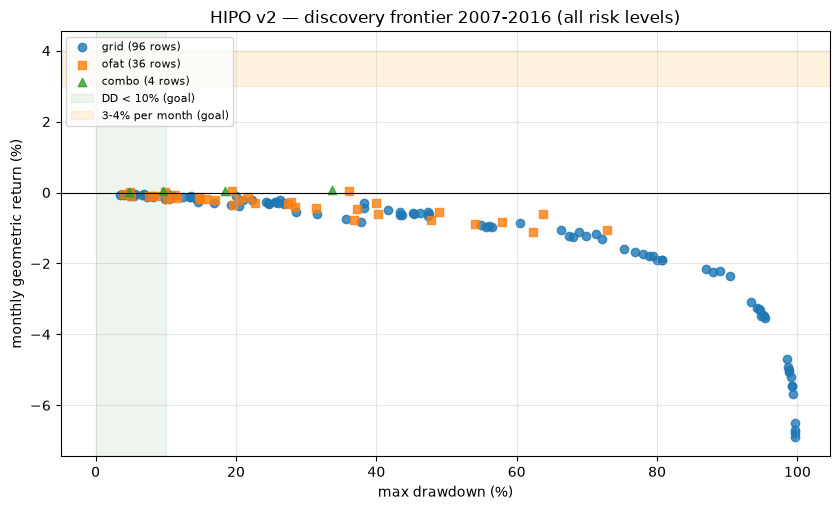

In [17]:
import itertools, time
r2_t0 = time.time()
R2_RISKS = [0.0025, 0.005, 0.01, 0.02]
R2_M1 = load_years(list(range(2007, 2017)))           # discovery only
print(f"discovery M1 bars 2007-2016: {len(R2_M1[0]):,}")

def r2_eval(family, config, sig, extra):
    n_sig = 0 if sig is None else len(sig["k"])
    out = []
    for risk in R2_RISKS:
        met = metrics_from_trades(run_bar_backtest(R2_M1, sig, risk))
        out.append(dict(family=family, config=config, risk_pct=risk * 100, signals=n_sig, **extra, **met))
    return out

r2_rows = []
# (A) pre-declared grid: 24 configurations
for tf, tpr, sbuf, msa in itertools.product([1, 5, 15], [2.5, 3.0], [0.10, 0.25], [0.0, 2.0]):
    sig = max_stop_atr_filter(signals_for_tf(R2_M1, tf, dict(TP_R=tpr, SL_BUF_ATR=sbuf)), msa)
    r2_rows += r2_eval("grid", f"TF{tf} TP{tpr} SLB{sbuf} MSA{msa}", sig,
                       dict(TF=tf, TP_R=tpr, SL_BUF_ATR=sbuf, MIN_STOP_ATR=msa))
print(f"grid done ({time.time() - r2_t0:.0f}s)", flush=True)

# (B) one-factor-at-a-time around TF5/TP2.5/SLB0.25/MSA2 (9 new configurations)
R2_BASE = dict(TP_R=2.5, SL_BUF_ATR=0.25)
R2_OFAT = [
    ("V1 time divergence required", {}, "tdiv"),
    ("V2 confirmation body >= 0.8 ATR", dict(CONF_BODY_ATR=0.8), None),
    ("V3 signal range >= 1.2 ATR", dict(SIG_MIN_RANGE=1.2), None),
    ("V4 entries 07:00-21:00 UTC only", {}, "session"),
    ("V5 confirmation wait <= 5 bars", dict(CONF_MAX_WAIT=5), None),
    ("V6 confirmation wait <= 30 bars", dict(CONF_MAX_WAIT=30), None),
    ("V7 B position 0.4-0.6 of signal", dict(SIG_POS_LO=0.4, SIG_POS_HI=0.6), None),
    ("V8 signal upper wick <= 0.20", dict(SIG_MAX_WICK=0.20), None),
    ("V9 AB noise candles = 0", dict(AB_MAX_NOISE=0), None),
]
def r2_apply_filter(sig, flt):
    if sig is None or flt is None:
        return sig
    if flt == "tdiv":
        return filt(sig, sig["raw"][:, 13] == 1)
    if flt == "session":
        return filt(sig, session_mask(R2_M1, sig))
    raise ValueError(flt)

for name, extra, flt in R2_OFAT:
    kw = dict(R2_BASE); kw.update(extra)
    sig = r2_apply_filter(max_stop_atr_filter(signals_for_tf(R2_M1, 5, kw), 2.0), flt)
    r2_rows += r2_eval("ofat", name, sig, dict(TF=5, TP_R=2.5, SL_BUF_ATR=0.25, MIN_STOP_ATR=2.0))
print(f"OFAT done ({time.time() - r2_t0:.0f}s)", flush=True)

# (C) combination that was selected on v1 discovery (V2 + V4), replicated on v2 discovery (counted trial)
kw = dict(R2_BASE); kw.update(CONF_BODY_ATR=0.8)
sig_combo = r2_apply_filter(max_stop_atr_filter(signals_for_tf(R2_M1, 5, kw), 2.0), "session")
r2_rows += r2_eval("combo", "V2+V4 (v1-selected)", sig_combo, dict(TF=5, TP_R=2.5, SL_BUF_ATR=0.25, MIN_STOP_ATR=2.0))

r2_all = pd.DataFrame(r2_rows)
print(f"all evaluations: {len(r2_all)} rows = {r2_all.config.nunique()} configurations x {len(R2_RISKS)} risk levels "
      f"({time.time() - r2_t0:.0f}s)")

# gross (no costs) diagnostic: mid prices, entry at the signal's confirmation M1 bar, SL/TP as in the signal
r2_gross = []
mh_all = (R2_M1[2] + R2_M1[6]) / 2; ml_all = (R2_M1[3] + R2_M1[7]) / 2
for tf in (1, 5, 15):
    for msa in (0.0, 2.0):
        sig = max_stop_atr_filter(signals_for_tf(R2_M1, tf, dict(TP_R=2.5, SL_BUF_ATR=0.25)), msa)
        o = gross_outcomes(mh_all, ml_all, sig["k"], sig["dir"], sig["sl"], sig["tp"], 1440)
        valid = ~np.isnan(o[:, 0])
        r2_gross.append(dict(TF=tf, MIN_STOP_ATR=msa, setups=len(o), resolved=int(valid.sum()),
                             gross_mean_R=round(float(np.nanmean(o[:, 0])), 4),
                             tp_hit_pct=round(float((o[valid, 1] == 1).mean() * 100), 1),
                             breakeven_tp_pct_at_2_5R=round(100 / 3.5, 1)))
r2_gross = pd.DataFrame(r2_gross)
print("\nGross expectancy (no costs):")
print(r2_gross.to_string(index=False))

R2_RES = os.path.join(R2_DIR, "results")
os.makedirs(R2_RES, exist_ok=True)
r2_all.to_csv(os.path.join(R2_RES, "disc_all_v2.csv"), index=False)
r2_gross.to_csv(os.path.join(R2_RES, "disc_gross_v2.csv"), index=False)

show = ["family", "config", "risk_pct", "signals", "trades", "win_pct", "mean_R", "pf", "monthly_geo_pct", "max_dd_pct"]
show = [c for c in show if c in r2_all.columns]
print("\nDiscovery (2007-2016) at 0.5% risk, all configurations:")
print(r2_all[r2_all.risk_pct == 0.5][show].to_string(index=False))

import matplotlib.pyplot as plt
r2_fig, r2_ax = plt.subplots(figsize=(8.5, 5.2))
for fam, mk in (("grid", "o"), ("ofat", "s"), ("combo", "^")):
    s = r2_all[r2_all.family == fam]
    r2_ax.scatter(s.max_dd_pct, s.monthly_geo_pct, marker=mk, alpha=0.8, label=f"{fam} ({len(s)} rows)")
r2_ax.axvspan(0, 10, color="#2e7d32", alpha=0.08, label="DD < 10% (goal)")
r2_ax.axhspan(3, 4, color="#f9a825", alpha=0.15, label="3-4% per month (goal)")
r2_ax.axhline(0, color="k", lw=0.8)
r2_ax.set_xlabel("max drawdown (%)"); r2_ax.set_ylabel("monthly geometric return (%)")
r2_ax.set_title("HIPO v2 — discovery frontier 2007-2016 (all risk levels)")
r2_ax.legend(fontsize=8, loc="upper left"); r2_ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(R2_RES, "frontier_discovery_v2.png"), dpi=110)
plt.show()


### انتخاب (قانون پیش‌ثبت‌شده، فقط دیسکاوری) و تصمیم دربارهٔ تأیید

**قانون:** بیشینه‌کردن بازدهی ماهانهٔ هندسی با شرط DD حداکثر ≤ ۱۰٪ روی دیسکاوری. اگر کاندیدای مثبت وجود داشته باشد، طبق پروتکل یک بار روی ۲۰۱۷–۲۰۲۲ با پارامترهای منجمد تأیید می‌شود.

**تصمیم:** holdout ۲۰۱۷–۲۰۲۲ برای HIPO دو بار دیده شده است (یک بار پیک با تنظیمات پیش‌فرض نسخهٔ اول و یک بار تأیید کاندیدای نسخهٔ اول). همچنین بازهٔ ۲۰۲۱-۰۱ تا ۲۰۲۲-۰۶ که در راند ۱ holdout بود، داخل ۲۰۱۷–۲۰۲۲ است؛ پس این بازه برای هیچ استراتژی‌ای «تازه» نیست. اگر کاندیدای منتخب نزدیک صفر باشد، تأیید دوباره روی همین داده نتیجهٔ معناداری نمی‌دهد. سلول زیر تصمیم را بر اساس نتایج محاسبه‌شده اعلام می‌کند.


In [18]:
import json
ok_rows = r2_all[r2_all.max_dd_pct <= 10.0]
top5 = ok_rows.sort_values("monthly_geo_pct", ascending=False).head(5)
print("Top-5 discovery rows with DD <= 10% (pre-declared rule):")
print(top5[["family", "config", "risk_pct", "signals", "trades", "mean_R", "monthly_geo_pct", "max_dd_pct"]].to_string(index=False))
rule_top = top5.iloc[0] if len(top5) else None
n_target = int(((r2_all.monthly_geo_pct >= 3.0) & (r2_all.max_dd_pct < 10.0)).sum())
best_mo = r2_all.loc[r2_all.monthly_geo_pct.idxmax()]
print(f"\nRows reaching 3%/month with DD < 10% on discovery: {n_target} of {len(r2_all)}")
print(f"Best monthly on discovery (any DD): {best_mo.monthly_geo_pct:+.3f}%  [{best_mo.config}, risk {best_mo.risk_pct}%, DD {best_mo.max_dd_pct:.2f}%]")
if rule_top is not None:
    print(f"Rule-selected candidate: {rule_top.config} at {rule_top.risk_pct}% risk  "
          f"(monthly {rule_top.monthly_geo_pct:+.3f}%, DD {rule_top.max_dd_pct:.2f}%)")
    if rule_top.monthly_geo_pct < 0.5:
        print("Decision: discovery edge is ~0 (far below the 3% goal). Confirmation on 2017-2022 is NOT run: "
              "holdout already used twice for HIPO and a second look cannot change the target status.")
    else:
        print("Decision: candidate has a positive discovery edge -> one frozen confirmation on 2017-2022 is required "
              "and must be disclosed as a contaminated second look.")

hold = json.load(open(os.path.join(R2_RES, "holdout_v1_record.json"))) if os.path.exists(os.path.join(R2_RES, "holdout_v1_record.json")) else None
if hold:
    print("\nHoldout record for HIPO (v1 detector, recorded; not re-run):")
    print("  frozen v1 candidate, bar-level:", hold["bar_level_M1_bidask"])
    print("  frozen v1 candidate, tick-level:", hold["tick_level_round1_engine"])

trials = pd.DataFrame([
    dict(stage="v1 discovery grid", configs=24, evaluations=96, note="superseded by v2 (bug)"),
    dict(stage="v1 discovery OFAT", configs=10, evaluations=40, note="superseded by v2"),
    dict(stage="v1 discovery combo", configs=1, evaluations=5, note="selected; holdout run once"),
    dict(stage="v1 holdout looks (2017-2022)", configs=2, evaluations=2, note="peek + frozen confirmation"),
    dict(stage="v2 discovery grid", configs=24, evaluations=96, note="this section"),
    dict(stage="v2 discovery OFAT (new)", configs=9, evaluations=36, note="base is a grid member"),
    dict(stage="v2 discovery combo", configs=1, evaluations=4, note="v1-selected combo replicated"),
    dict(stage="v2 holdout looks", configs=0, evaluations=0, note="none (not run)"),
])
print("\nTrial counts (HIPO round 2):")
print(trials.to_string(index=False))


Top-5 discovery rows with DD <= 10% (pre-declared rule):
family                          config  risk_pct  signals  trades    mean_R  monthly_geo_pct  max_dd_pct
 combo             V2+V4 (v1-selected)      0.50      114     109  0.036447         0.029189    9.559663
  ofat V4 entries 07:00-21:00 UTC only      0.50      182     171  0.027559         0.026384    9.878242
  ofat V4 entries 07:00-21:00 UTC only      0.25      182     171  0.023747         0.012579    4.922311
 combo             V2+V4 (v1-selected)      0.25      114     109  0.022804         0.009531    4.749242
  grid       TF15 TP3.0 SLB0.25 MSA0.0      0.25      187     176 -0.032018        -0.020988    5.008021

Rows reaching 3%/month with DD < 10% on discovery: 0 of 136
Best monthly on discovery (any DD): +0.077%  [V2+V4 (v1-selected), risk 2.0%, DD 33.67%]
Rule-selected candidate: V2+V4 (v1-selected) at 0.5% risk  (monthly +0.029%, DD 9.56%)
Decision: discovery edge is ~0 (far below the 3% goal). Confirmation on 2017

### جمع‌بندی دور ۲ و وضعیت هدف

**وضعیت هدف: ❌ محقق نشد.** هدف ۳–۴٪ ماهانه با DD کمتر از ۱۰٪ با هیچ پیکربندی HIPO روی دیسکاوری (۲۰۰۷–۲۰۱۶) به دست نیامد. بهترین بازدهی ماهانه با DD ≤ ۱۰٪ حدود **+۰٫۰۳٪** است (ترکیب V2+V4، ریسک ۰٫۵٪، DD ۹٫۵۶٪).

**۱. پیاده‌سازی قواعد PDF**
- قواعد AB، BC، CD، جعبهٔ نقدینگی، کندل سیگنال، تأیید، حد ضرر و هدف ۲٫۵R پیاده شده‌اند.
- نسخهٔ اول سه باگ در rewind و بازگشت به BC داشت؛ در نسخهٔ ۲ اصلاح شد. نسخهٔ قبلی برای حسابرسی بایگانی است.
- آزمون‌ها: **۲۲ از ۲۲ گذشت** (۲۱ آزمون سنتتیک و نمونهٔ NAS، به‌علاوهٔ پایداری نمونهٔ NAS با پیشوند تصادفی: ۳۰ از ۳۰).
- نمونهٔ NAS: ورود ۳۰۷۴۲٫۹۳ در برابر ۳۰۷۴۳٫۱۳ ترسیم‌شده؛ SL ≈ ۳۰۷۷۳٫۲ در برابر ۳۰۷۷۴٫۵۵؛ هدف ۲٫۵R برابر ۳۰۶۶۷٫۱۹.

**۲. مقایسه با تصاویر DAX/GER30**
- ۲۰ تصویر دیجیتال شد (۱٬۷۷۴ کندل)؛ ۱۵ تصویر ناحیهٔ ریسک قابل‌اندازه‌گیری دارند.
- **تطابق: ۱ از ۱۵** (05-21: جهت و نقطهٔ ورود یکسان؛ SL حدود ۰٫۳۸ ATR نزدیک‌تر؛ ریسک ۰٫۸۹ برابر ترسیم‌شده).
- **۱۴ عدم‌تطابق.** آزمون حساسیت روی تصاویر: حذف تک‌تک فیلترها تغییری نمی‌دهد؛ حذف همه، ۸ سیگنال می‌دهد ولی هیچ‌کدام در نقطهٔ ورود ترسیم‌شده نیست. پس مشکل فقط آستانه‌ها نیست. احتمال اصلی: دقت دیجیتال‌سازی (±۱–۲ پیکسل) و تعریف دقیق «شکستن B» و ساختار BC/CD.
- **نتیجه:** پیاده‌سازی با قواعد PDF همخوان است، ولی با تصاویر **هنوز کامل تأیید نشده**.
- عددهای R روی تصاویر (از نام فایل‌ها؛ جمع تقریبی +۹۴٫۹R) بیشتر از هدف ترسیم‌شده‌اند؛ یعنی معامله‌گر بعد از هدف مدیریت می‌کند. قانون ثابت ۲٫۵R این را شبیه‌سازی نمی‌کند.

**۳. بهینه‌سازی (فقط دیسکاوری ۲۰۰۷–۲۰۱۶)**
- ۳۴ پیکربندی × ۴ ریسک = ۱۳۶ ارزیابی: شبکهٔ ۲۴تایی پیش‌ثبت‌شده، ۹ تغییر OFAT و ترکیب V2+V4 منتخب نسخهٔ اول.
- **ناخالص (بدون هزینه):** TF1 حدود +۰٫۰۳R (در حد هزینه)، TF5 حدود −۰٫۰۹ تا −۰٫۱۳R، TF15 حدود −۰٫۰۴ تا −۰٫۱۸R. نقطهٔ سربه‌سر در ۲٫۵R برابر ۲۸٫۶٪ برد است.
- **قانون انتخاب:** بیشینهٔ بازدهی ماهانه با DD ≤ ۱۰٪. کاندیدای منتخب ≈ صفر است، پس تأیید روی ۲۰۱۷–۲۰۲۲ **اجرا نشد** (شرح در سلول انتخاب).

**۴. holdout و شمارش آزمون‌ها**
- HIPO دو بار روی ۲۰۱۷–۲۰۲۲ دیده شده است (هر دو با نسخهٔ اول): پیک با تنظیمات پیش‌فرض (کل −۴۳٫۹٪) و تأیید یک‌باره‌ی کاندیدای منجمد (بار-سطح −۲٫۵۲٪؛ تیک-سطح −۳٫۳۷٪ با DD ۱۱٫۵۲٪).
- نسخهٔ ۲ هیچ‌گاه روی این بازه ارزیابی نشده است. بازهٔ ۲۰۲۱–۲۰۲۲ (holdout راند ۱) داخل ۲۰۱۷–۲۰۲۲ است؛ پس این بازه برای هیچ استراتژی‌ای دیگر «تازه» نیست.
- شمارش: ۳۴ پیکربندی ساختاری v2 روی دیسکاوری + ۳۴ پیکربندی v1 (بایگانی‌شده)؛ جزئیات در سلول انتخاب.

**۵. مرز بازده/DD**
- نمودار `research/phase3_hipo_pdf/results/frontier_discovery_v2.png` و جدول `disc_all_v2.csv`. هیچ نقطه‌ای در ناحیهٔ هدف نیست. مرز راند ۱ (holdout، EURUSD) همچنان: ریسک ۰٫۵٪ → ۰٫۲۷٪ ماهانه با DD ۵٫۸٪ (هدف بازدهی برآورده نشد).

**۶. آیا می‌توان بهتر کرد؟ قدم بعدی**
1. **داده‌ی هم‌بازار با تصاویر (مهم‌ترین):** تصاویر روی DAX/GER30 یک‌دقیقه‌ای هستند؛ EURUSD ممکن است بازار مناسبی برای این الگو نباشد. با یک فایل CSV از DAX/GER30 (زمان، باز/بالا/پایین/بسته و در صورت امکان اسپرد) همین خط لوله را با همان پروتکل (دیسکاوری قدیمی، تأیید جدید) اجرا می‌کنم.
2. **بازبینی دستی ۱۴ تصویر ناهمخوان:** مشخص کردن دقیق کندل‌های BC و CD و اینکه «شکستن B» با بدنه است یا سایه.
3. **قاعدهٔ خروج:** اگر معامله‌گر بعد از هدف خارج می‌شود (trailing یا خروج جزئی)، باید قاعده‌اش مشخص شود؛ بدون آن، بازدهی ترسیم‌شده قابل شبیه‌سازی نیست.
4. **holdout تازه:** هر آزمون تأییدی بعدی به داده‌ی تازه (بعد از ۲۰۲۲ یا بازار دیگر) نیاز دارد.

**نتیجهٔ صریح:** در این دور، قواعد HIPO (همان‌طور که از PDF و تصاویر برمی‌آید) با داده‌ی EURUSD لبهٔ قابل‌اعتمادی نشان نداد و هدف ۳–۴٪ ماهانه با DD کمتر از ۱۰٪ محقق نشد. فاز ۲ (کامیت Phase 2 روی همین شاخه) نیز به نتیجهٔ مشابهی رسیده است.


## ۱۰د. دور ۳ — منطق‌های تازه: بازگشت به میانگین، شکست در بازار فشرده و آینهٔ آن (فقط دیسکاوری)

**چرا این سه خانواده؟** خانواده‌های فاز ۲ (کانال دانچیان، الگوهای ساعتی، TSMOM روزانه، ML) و HIPO پیش‌تر آزموده شده‌اند. اینجا سه مکانیسم متفاوت، با هزینه‌ی واقعی موتور، آزموده می‌شوند:

- **MR — بازگشت به میانگین:** انحراف قیمت از EMA بر حسب ATR روی کندل‌های M5 یا M15. ورود معکوس انحراف وقتی |z| ≥ ۲ یا ۲٫۵؛ حد ضرر ۱٫۵ ATR؛ هدف ۱ یا ۲ ATR؛ توقف زمانی ۱۲ کندل.
- **VB — شکست در بازار فشرده:** شکست سقف/کف N کندل قبل (N = ۲۰ یا ۴۸)، فقط وقتی ATR کندل قبل در صدک ۲۵ یا ۵۰ پایینیِ ۵۰۰ کندل گذشته باشد. حد ضرر ۱ یا ۱٫۵ ATR؛ هدف ۱٫۵ یا ۲٫۵ برابر فاصلهٔ حد ضرر.
- **VBI — آینهٔ VB:** چون گراس VB منفی بود، همان رویدادها با جهت و سطوح قرینه نسبت به قیمت ورود آزموده شد. این یک خانوادهٔ جداست و ۱۶ آزمون جدا دارد که جداگانه شمرده می‌شود.

**پروتکل:**
1. شبکهٔ MR و VB (۳۲ پیکربندی) پیش از اجرا ثبت شد. VBI (۱۶ پیکربندی، آینهٔ VB) پس از دیدن گراس منفی VB اضافه شد و پیش از اجرای خودش ثبت گردید؛ بنابراین فرضیه‌ای جداگانه است و شمارش جدا دارد. جمع ۴۸ پیکربندی، هر کدام با ۴ سطح ریسک (۰٫۲۵، ۰٫۵، ۱، ۲٪)، یعنی ۱۹۲ ردیف.
2. فقط دیسکاوری ۲۰۰۷–۲۰۱۶ استفاده شد. تقسیم داخلی (۲۰۰۷–۲۰۱۱ و ۲۰۱۲–۲۰۱۶) فقط برای بررسی پایداری است و تأیید مستقل نیست.
3. قاعدهٔ انتخاب پیش‌ثبت‌شده: DD ≤ ۱۰٪، حداقل ۲۰۰ معامله، و میانگین R مثبت در هر دو نیمه. از میان کاندیدهای قبول‌شده، بیشترین بازدهٔ ماهانه انتخاب می‌شود.
4. **holdout:** این دور به هیچ holdout نگاه نکرد. منبع FX-Data فقط تا ۲۰۲۲ داده دارد (شاخه‌های ۲۰۲۳ به بعد وجود ندارند) و بازهٔ ۲۰۱۷–۲۰۲۲ در چند دور قبلی مصرف شده است. بنابراین هر کاندیدی که تأیید شود، تأیید آلوده خواهد بود.
5. تشخیص‌ها: سود ناخالص (بدون هزینه) و تجزیهٔ هزینه (کامل در برابر فقط اسپرد) روی همان سیگنال‌ها.

In [19]:
# ── دور ۳: سه خانواده‌ی تازه (MR/VB پیش‌ثبت؛ VBI فرضیهٔ جدا) — فقط دیسکاوری ۲۰۰۷–۲۰۱۶ ─────────────────────
import os, time
from numba import njit
import matplotlib.pyplot as plt

ALT_RISKS = [0.0025, 0.005, 0.01, 0.02]
ALT_SPLIT_YEAR = 2012            # بررسی پایداری داخل دیسکاوری: ۲۰۰۷–۲۰۱۱ | ۲۰۱۲–۲۰۱۶ (این holdout نیست)
ALT_DIR = "research/phase4_alt_logics/results"
os.makedirs(ALT_DIR, exist_ok=True)
assert "R2_M1" in globals() and "exec_bars" in globals() and "atr_wilder" in globals(), "سلول‌های دور ۲ باید اجرا شده باشند"

def alt_tf_arrays(m1, tf):
    """کندل‌های TF با قیمت میانگین bid/ask. last = اندیس M1 آخرین دقیقهٔ کندل TF (لحظهٔ دانستن سیگنال)."""
    key, bo, bh, bl, bc, ao, ah, al, ac, cnt = m1
    rk, RBO, RBH, RBL, RBC, RAO, RAH, RAL, RAC = resample_bidask(key, bo, bh, bl, bc, ao, ah, al, ac, tf)
    mh = (RBH + RAH) / 2; ml = (RBL + RAL) / 2; mc = (RBC + RAC) / 2
    last = np.searchsorted(key, rk + tf - 1, side="right") - 1
    return dict(last=last.astype(np.int64), mh=mh, ml=ml, mc=mc, tf=tf)

def _alt_pack(t, idx, d, e, sl, tp, atr):
    return dict(k=t["last"][idx].astype(np.int64), dir=np.asarray(d, np.float64), entry=np.asarray(e, np.float64),
                sl=np.asarray(sl, np.float64), tp=np.asarray(tp, np.float64), atr=np.asarray(atr, np.float64))

def alt_gen_mr(t, n=20, zk=2.0, tmult=1.0, smult=1.5):
    """MR: z = (close - EMA_n) / ATR14؛ اگر |z| ≥ zk، در جهت بازگشت به EMA وارد می‌شویم. EMA علّی است."""
    mc, mh, ml = t["mc"], t["mh"], t["ml"]
    atr = atr_wilder(mh, ml, mc, 14)
    ema = pd.Series(mc).ewm(span=n, adjust=False).mean().values
    z = (mc - ema) / atr
    ok = np.isfinite(z) & np.isfinite(atr) & (atr > 0)
    sh = ok & (z >= zk); lg = ok & (z <= -zk)
    idx = np.nonzero(sh | lg)[0]
    d = np.where(sh[idx], -1.0, 1.0); e = mc[idx]
    sl = e + np.where(d < 0, smult, -smult) * atr[idx]
    tp = e + np.where(d < 0, -tmult, tmult) * atr[idx]
    return _alt_pack(t, idx, d, e, sl, tp, atr[idx])

def alt_gen_vb(t, N=20, pq=0.25, smult=1.0, rmult=2.0, W=500, mirror=False):
    """VB: شکست سقف/کف N کندل قبل، فقط وقتی ATR کندل قبل در صدک pq پایینِ W کندل گذشته است.
    mirror=True ⇒ VBI: همان رویدادها با جهت و سطوح قرینه نسبت به قیمت ورود."""
    mc, mh, ml = t["mc"], t["mh"], t["ml"]
    atr = atr_wilder(mh, ml, mc, 14)
    hi = pd.Series(mh).shift(1).rolling(N).max().values
    lo = pd.Series(ml).shift(1).rolling(N).min().values
    a = pd.Series(atr)
    q = a.shift(1).rolling(W).quantile(pq).values
    quiet = np.isfinite(q) & (a.shift(1).values <= q)
    up = quiet & (mc > hi); dn = quiet & (mc < lo)
    ok = np.isfinite(atr) & (atr > 0)
    idx = np.nonzero((up | dn) & ok)[0]
    d = np.where(up[idx], 1.0, -1.0); e = mc[idx]; R = smult * atr[idx]
    sl = e - d * R; tp = e + d * rmult * R
    if mirror:
        d = -d; sl, tp = 2 * e - sl, 2 * e - tp
    return _alt_pack(t, idx, d, e, sl, tp, atr[idx])

# ۱۶ MR + ۱۶ VB پیش‌ثبت‌شده؛ ۱۶ VBI پس از گراس منفی VB (فرضیهٔ جدا، شمارش جدا) = ۴۸ پیکربندی × ۴ ریسک
ALT_GRID = (
    [dict(family="MR", TF=tf, n=n, zk=zk, tm=tm, sm=1.5) for tf in (5, 15) for n in (20, 60) for zk in (2.0, 2.5) for tm in (1.0, 2.0)]
    + [dict(family=fam, TF=15, N=N, pq=pq, sm=sm, rm=rm) for fam in ("VB", "VBI") for N in (20, 48) for pq in (0.25, 0.5) for sm in (1.0, 1.5) for rm in (1.5, 2.5)]
)
assert len(ALT_GRID) == 48, len(ALT_GRID)

def alt_eval(sig, max_hold, base):
    rows = []; key = R2_M1[0]
    for risk in ALT_RISKS:
        tr = run_bar_backtest(R2_M1, sig, risk, max_hold=max_hold)
        row = dict(base, risk_pct=risk * 100, signals=int(len(sig["k"])))
        if tr.shape[0] == 0:
            row.update(trades=0, mean_R=np.nan, monthly_geo_pct=np.nan, max_dd_pct=np.nan,
                       n_h1=0, n_h2=0, mean_R_h1=np.nan, mean_R_h2=np.nan)
        else:
            row.update(metrics_from_trades(tr))
            yrs = pd.to_datetime(key[tr[:, 0].astype(np.int64)], unit="m").year.values
            R = tr[:, 9]; h1 = R[yrs < ALT_SPLIT_YEAR]; h2 = R[yrs >= ALT_SPLIT_YEAR]
            row.update(n_h1=int(h1.size), mean_R_h1=float(h1.mean()) if h1.size else np.nan,
                       n_h2=int(h2.size), mean_R_h2=float(h2.mean()) if h2.size else np.nan)
        rows.append(row)
    return rows

alt_cache = {}
def alt_make(cfg):
    tf = cfg["TF"]
    if tf not in alt_cache:
        alt_cache[tf] = alt_tf_arrays(R2_M1, tf)
    t = alt_cache[tf]
    if cfg["family"] == "MR":
        sig = alt_gen_mr(t, cfg["n"], cfg["zk"], cfg["tm"], cfg["sm"]); mh_ = 12 * tf          # توقف زمانی: ۱۲ کندل TF
        name = f"MR TF{tf} EMA{cfg['n']} z{cfg['zk']} TP{cfg['tm']}ATR"
        base = dict(family="MR", config=name, TF=tf, n=cfg["n"], zk=cfg["zk"], tp_ATR=cfg["tm"], sl_ATR=cfg["sm"])
    else:
        sig = alt_gen_vb(t, cfg["N"], cfg["pq"], cfg["sm"], cfg["rm"], mirror=(cfg["family"] == "VBI")); mh_ = 1440
        name = f"{cfg['family']} TF{tf} N{cfg['N']} pq{cfg['pq']} SL{cfg['sm']}ATR R{cfg['rm']}"
        base = dict(family=cfg["family"], config=name, TF=tf, N=cfg["N"], pq=cfg["pq"], sl_ATR=cfg["sm"], rmult=cfg["rm"])
    return name, sig, mh_, base

t_alt = time.time()
ALT_ROWS = []
for cfg in ALT_GRID:
    name, sig, mh_, base = alt_make(cfg)
    ALT_ROWS += alt_eval(sig, mh_, base)
ALT_RES = pd.DataFrame(ALT_ROWS)
ALT_RES.to_csv(os.path.join(ALT_DIR, "disc_alt_v1.csv"), index=False)
print(f"شبکهٔ دور ۳: {ALT_RES.config.nunique()} پیکربندی × {len(ALT_RISKS)} ریسک = {len(ALT_RES)} ردیف ({time.time()-t_alt:.0f}s)")
show = ["family", "config", "signals", "trades", "mean_R", "win_pct", "monthly_geo_pct", "max_dd_pct", "mean_R_h1", "mean_R_h2"]
print(ALT_RES[ALT_RES.risk_pct == 0.5][show].sort_values("monthly_geo_pct", ascending=False).round(3).to_string(index=False))

شبکهٔ دور ۳: 48 پیکربندی × 4 ریسک = 192 ردیف (11s)
family                            config  signals  trades  mean_R  win_pct  monthly_geo_pct  max_dd_pct  mean_R_h1  mean_R_h2
   VBI VBI TF15 N48 pq0.25 SL1.5ATR R2.5     2983    2168  -0.044   31.504           -0.638      51.215     -0.034     -0.052
   VBI VBI TF15 N48 pq0.25 SL1.5ATR R1.5     2983    2199  -0.077   42.519           -1.045      60.819     -0.068     -0.084
   VBI VBI TF15 N20 pq0.25 SL1.5ATR R2.5     6827    4002  -0.049   31.409           -1.279      70.261     -0.026     -0.066
   VBI VBI TF15 N48 pq0.25 SL1.0ATR R2.5     2983    2443  -0.131   30.700           -1.959      81.833     -0.115     -0.144
   VBI VBI TF15 N48 pq0.25 SL1.0ATR R1.5     2983    2477  -0.133   42.753           -1.988      81.697     -0.139     -0.128
   VBI  VBI TF15 N48 pq0.5 SL1.5ATR R2.5     6427    4398  -0.073   30.036           -2.027      85.989     -0.062     -0.081
   VBI  VBI TF15 N48 pq0.5 SL1.5ATR R1.5     6427    4538  -0.083  

In [20]:
# ── تشخیص: سود ناخالص (بدون هزینه) و تجزیهٔ هزینه — همان سیگنال‌ها و همان موتور ─────────────
@njit
def first_touch_R(mh, ml, mc1, k_arr, d_arr, e_arr, sl_arr, tp_arr, maxbars):
    """R ناخالص به‌ازای هر سیگنال: اولین لمس SL (-1R) یا TP؛ در پایان مهلت، ارزش بازار به قیمت پایان."""
    n = mh.shape[0]; out = np.full(k_arr.shape[0], np.nan); kind = np.zeros(k_arr.shape[0], np.int64)
    for q in range(k_arr.shape[0]):
        k = k_arr[q]; d = d_arr[q]; e = e_arr[q]; sl = sl_arr[q]; tp = tp_arr[q]
        dist = abs(sl - e)
        if dist <= 0:
            continue
        res = np.nan; j = k + 1; done = False
        while j < n and j - k <= maxbars:
            if d < 0:
                if mh[j] >= sl:
                    res = -1.0; kind[q] = 0; done = True; break
                if ml[j] <= tp:
                    res = abs(tp - e) / dist; kind[q] = 1; done = True; break
            else:
                if ml[j] <= sl:
                    res = -1.0; kind[q] = 0; done = True; break
                if mh[j] >= tp:
                    res = abs(tp - e) / dist; kind[q] = 1; done = True; break
            j += 1
        if not done and k + 1 < n:
            jj = min(k + maxbars, n - 1)
            res = d * (mc1[jj] - e) / dist; kind[q] = 2
        out[q] = res
    return out, kind

key, bo, bh, bl, bc, ao, ah, al, ac, cnt = R2_M1
mh1 = (bh + ah) / 2; ml1 = (bl + al) / 2; mc1 = (bc + ac) / 2
gross_rows = []
for cfg in ALT_GRID:
    name, sig, mh_, base = alt_make(cfg)
    R_g, kind = first_touch_R(mh1, ml1, mc1, sig["k"], sig["dir"], sig["entry"], sig["sl"], sig["tp"], mh_)
    v = ~np.isnan(R_g)
    gross_rows.append(dict(family=base["family"], config=name, setups=int(len(R_g)),
                           gross_mean_R=round(float(np.nanmean(R_g)), 4),
                           tp_first_pct=round(float((kind[v] == 1).mean() * 100), 1),
                           sl_first_pct=round(float((kind[v] == 0).mean() * 100), 1),
                           timeout_pct=round(float((kind[v] == 2).mean() * 100), 1)))
GROSS = pd.DataFrame(gross_rows)
GROSS.to_csv(os.path.join(ALT_DIR, "gross_alt_v1.csv"), index=False)
print("میانگین R ناخالص به‌ازای هر سیگنال، به تفکیک خانواده:")
print(GROSS.groupby("family").gross_mean_R.agg(["mean", "max", "min"]).round(4).to_string())

# تجزیهٔ هزینه روی سه پیکربندی نمایندهٔ: کامل | فقط اسپرد (کمیسیون و لغزش صفر) — ریسک ۰٫۵٪
COST_CASES = [("MR TF5 EMA20 z2.0 TP1.0 SL1.5", dict(family="MR", TF=5, n=20, zk=2.0, tm=1.0, sm=1.5)),
              ("MR TF15 EMA60 z2.5 TP1.0 SL1.5", dict(family="MR", TF=15, n=60, zk=2.5, tm=1.0, sm=1.5)),
              ("VBI TF15 N48 pq0.25 SL1.5 R2.5", dict(family="VBI", TF=15, N=48, pq=0.25, sm=1.5, rm=2.5))]
cost_rows = []
for label, cfg in COST_CASES:
    _, sig, mh_, _ = alt_make(cfg)
    row = dict(config=label, signals=int(len(sig["k"])))
    for tag, comm, slip in (("full", 3.5, 0.1), ("spread_only", 0.0, 0.0)):
        prm = exec_params(risk=0.005, max_spread_pips=2.0, max_hold_min=mh_, comm=comm, slip_pips=slip)
        tr = exec_bars(key, bo, bh, bl, bc, ao, ah, al, ac, sig["k"], sig["dir"], sig["entry"], sig["sl"], sig["tp"], prm)
        row[f"{tag}_trades"] = int(tr.shape[0]); row[f"{tag}_meanR"] = round(float(tr[:, 9].mean()), 4)
    cost_rows.append(row)
COST = pd.DataFrame(cost_rows)
COST.to_csv(os.path.join(ALT_DIR, "cost_split_v1.csv"), index=False)
print(COST.to_string(index=False))

میانگین R ناخالص به‌ازای هر سیگنال، به تفکیک خانواده:
          mean     max     min
family                        
MR      0.0336  0.0610 -0.0086
VB     -0.1054 -0.0793 -0.1599
VBI     0.0732  0.1189  0.0429


                        config  signals  full_trades  full_meanR  spread_only_trades  spread_only_meanR
 MR TF5 EMA20 z2.0 TP1.0 SL1.5    76643         8567     -0.1303               17523            -0.0625
MR TF15 EMA60 z2.5 TP1.0 SL1.5    70205        14654     -0.0738               18436            -0.0094
VBI TF15 N48 pq0.25 SL1.5 R2.5     2983         2168     -0.0440                2168             0.0366


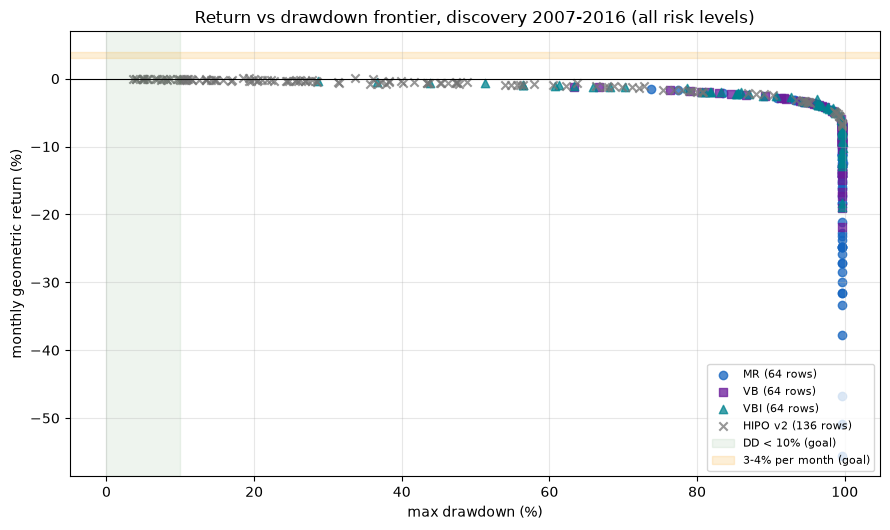

قاعدهٔ پیش‌ثبت‌شده: DD ≤ 10٪، معامله ≥ 200، میانگین R مثبت در هر دو نیمه → کاندیدهای قبول‌شده: 0
بهترین بازدهٔ ماهانه (دور ۳، همهٔ ریسک‌ها): VBI TF15 N48 pq0.25 SL1.5ATR R2.5 @ 0.25% → -0.294% ماهانه، DD 28.66%
ردیف‌های با بازدهٔ مثبت: 0 از 192 | DD ≤ 10٪: 0 | بازدهٔ ≥ ۳٪ ماهانه: 0 | کمترین DD: 28.66٪
شمارش آزمون: 48 پیکربندی جدید (192 ردیف با چهار ریسک) | نگاه به holdout در این دور: ۰ | تأیید: انجام نشد (کاندیدی قبول نشد)


In [21]:
# ── مرز بازده/DD، قاعدهٔ انتخاب پیش‌ثبت‌شده و شمارش آزمون‌ها ───────────────────────────────────
COLS = ["family", "config", "risk_pct", "monthly_geo_pct", "max_dd_pct", "trades", "mean_R_h1", "mean_R_h2"]
parts = [ALT_RES.reindex(columns=COLS).assign(origin="round3")]
if "r2_all" in globals():
    parts.append(r2_all.reindex(columns=COLS).assign(family="HIPO v2", origin="round2"))
ALL = pd.concat(parts, ignore_index=True)

fig, ax = plt.subplots(figsize=(9, 5.4))
styles = {"MR": ("o", "#1565c0"), "VB": ("s", "#6a1b9a"), "VBI": ("^", "#00838f"), "HIPO v2": ("x", "#757575")}
for fam, (mk, col) in styles.items():
    s = ALL[ALL.family == fam]
    if len(s):
        ax.scatter(s.max_dd_pct, s.monthly_geo_pct, marker=mk, color=col, alpha=0.75, label=f"{fam} ({len(s)} rows)")
ax.axvspan(0, 10, color="#2e7d32", alpha=0.08, label="DD < 10% (goal)")
ax.axhspan(3, 4, color="#f9a825", alpha=0.18, label="3-4% per month (goal)")
ax.axhline(0, color="k", lw=0.8)
ax.set_xlabel("max drawdown (%)"); ax.set_ylabel("monthly geometric return (%)")
ax.set_title("Return vs drawdown frontier, discovery 2007-2016 (all risk levels)")
ax.legend(fontsize=8, loc="lower right"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig(os.path.join(ALT_DIR, "frontier_alt_v1.png"), dpi=110); plt.show()

RULE_MAX_DD, RULE_MIN_TRADES = 10.0, 200
new = ALL[ALL.origin == "round3"]
elig = new[(new.max_dd_pct <= RULE_MAX_DD) & (new.trades >= RULE_MIN_TRADES) & (new.mean_R_h1 > 0) & (new.mean_R_h2 > 0)]
best = new.loc[new.monthly_geo_pct.idxmax()]
print(f"قاعدهٔ پیش‌ثبت‌شده: DD ≤ {RULE_MAX_DD:.0f}٪، معامله ≥ {RULE_MIN_TRADES}، میانگین R مثبت در هر دو نیمه → کاندیدهای قبول‌شده: {len(elig)}")
print(f"بهترین بازدهٔ ماهانه (دور ۳، همهٔ ریسک‌ها): {best.config} @ {best.risk_pct}% → {best.monthly_geo_pct:+.3f}% ماهانه، DD {best.max_dd_pct:.2f}%")
print(f"ردیف‌های با بازدهٔ مثبت: {int((new.monthly_geo_pct > 0).sum())} از {len(new)} | DD ≤ {RULE_MAX_DD:.0f}٪: {int((new.max_dd_pct <= RULE_MAX_DD).sum())} | بازدهٔ ≥ ۳٪ ماهانه: {int((new.monthly_geo_pct >= 3).sum())} | کمترین DD: {new.max_dd_pct.min():.2f}٪")
print(f"شمارش آزمون: {ALT_RES.config.nunique()} پیکربندی جدید ({len(ALT_RES)} ردیف با چهار ریسک) | نگاه به holdout در این دور: ۰ | تأیید: انجام نشد (کاندیدی قبول نشد)")

### جمع‌بندی دور ۳ و وضعیت هدف

**نتیجه:** هیچ‌کدام از ۴۸ پیکربندی (۱۹۲ ردیف با چهار ریسک) در دیسکاوری بازدهٔ ماهانهٔ مثبت ندارد. بهترین ردیف −۰٫۲۹٪ ماهانه با DD ≈ ۲۹٪ است و هیچ ردیفی DD ≤ ۱۰٪ یا بازدهٔ ۳٪ ماهانه ندارد. کاندیدی از قاعدهٔ پیش‌ثبت‌شده عبور نکرد، بنابراین تأیید (holdout) اجرا نشد.

**سه یافتهٔ اصلی:**
- **MR:** اثر بازگشت به میانگین واقعی ولی کوچک است: گراس میانگین ≈ +۰٫۰۳۴R به‌ازای هر سیگنال (بیشینه ≈ +۰٫۰۶R). هزینه‌ی هر معامله (حدود ۰٫۱ تا ۰٫۱۸R) آن را از بین می‌برد.
- **VB:** شکست در بازار فشرده پیش از هزینه میانگین ≈ −۰٫۱۰R دارد؛ یعنی بیشترِ این شکست‌ها ناکام می‌شوند.
- **VBI (آینهٔ VB):** بیشترین گراس بین سه خانواده، میانگین ≈ +۰٫۰۷۳R به‌ازای هر سیگنال. ولی کمیسیون و لغزش آن را منفی می‌کند: با اسپرد تنها ≈ +۰٫۰۳۷R و با هزینهٔ کامل ≈ −۰٫۰۴۴R در هر معامله.

**هزینه به‌صورت عددی:** در حساب ۱۰٬۰۰۰ دلاری با ریسک ثابت، کمیسیون ۷ دلار رفت‌وبرگشت هر لات بر حسب R تقریباً ۰٫۷ ÷ (حد ضرر بر حسب پیپ) است. پس حد ضرر ۹ پیپ حدود ۰٫۰۸R و حد ضرر ۵ پیپ حدود ۰٫۱۴R کمیسیون دارد.

**فاصلهٔ تا هدف:** ۳٪ ماهانه با ریسک ۰٫۵٪ یعنی حدود ۶R خالص در ماه. با ۱۸ معامله در ماه (VBI) باید میانگین ≈ ۰٫۳۳R خالص باشد؛ با ۷۱ معامله در ماه (MR TF5) ≈ ۰٫۰۸R. حتی با کمیسیون صفر، VBI با ۱۸ معامله در ماه حدود ۰٫۳٪ ماهانه در ریسک ۰٫۵٪ می‌دهد (تقریب تعداد معامله × میانگین R × ریسک).

**شمارش آزمون‌ها در کل پروژه (تقریبی):** فاز ۲ (نشست دیگر) ≈ ۸۰۲ پیکربندی، HIPO دور ۲: ۳۴، این دور: ۴۸، دور ۱: حدود ۵۶ انتخاب؛ جمع ≈ ۹۴۰. با این تعداد آزمون، حتی با p ≈ ۰٫۰۵ حدود ۴۷ نتیجهٔ «معنادار» تصادفی انتظار می‌رود. آستانهٔ تصحیح‌شده (Bonferroni) ≈ ۵×۱۰⁻⁵ است و هر ادعای مثبت بدون داده‌ی تازه قابل اتکا نیست.

**وضعیت هدف:** ۳–۴٪ ماهانه با DD کمتر از ۱۰٪ **هنوز به‌دست نیامده.** نقطهٔ گیر مشخص است: هزینه‌ی هر معامله (عمدتاً کمیسیون، که در حد ضرر کوچک سهم بزرگی از R را می‌خورد) از گراس خانواده‌ها بیشتر است، و فرکانس معاملات برای رسیدن به ۳٪ کافی نیست. برای ادامه تصمیم شما لازم است: داده‌ی EURUSD بعد از ۲۰۲۲ برای holdout تمیز، یا تغییر هدف/دامنهٔ جست‌وجو.

## ۱۱. 🏁 سلول نهایی: بک‌تستر حرفه‌ای تیک‌به‌تیک و گزارش جامع
موتور تیک‌به‌تیک در بخش ۲ تعریف شده است تا همه‌ی آزمایش‌های بالا از **همان** موتور استفاده کنند. این سلول آن موتور را روی استراتژی منجمد انتخاب‌شده در holdout اجرا می‌کند و گزارش کامل تولید می‌کند:
1. پیکربندی موتور و فرض‌های هزینه
2. خلاصه‌ی عملکرد (بازده، DD، Sharpe، Calmar، PF، زمان زیر آب، اکسپوژر)
3. بازده‌ی ماهانه (جدول سال × ماه)
4. تحلیل معاملات: علت خروج، جهت، ساعت ورود، MAE/MFE
5. **حساسیت هزینه و اجرا:** اسپرد ×۱.۵/×۲/×۳، اسلیپیج، تأخیر، کمیسیون، فیلتر اسپرد
6. آمار استنباطی: فاصله‌ی اطمینان بوت‌استرپ، t-test، **آزمون جهت تصادفی** روی همان سیگنال‌ها، DSR و PBO
7. نمودارها: منحنی سرمایه، افت از اوج، بازده ماهانه، توزیع R، نتیجه‌ی آزمون جهت تصادفی
8. داوری هدف با اعداد محاسبه‌شده
9. خروجی: CSV معاملات و ماهانه، و گزارش HTML در `CACHE_DIR/reports`

> **محدودیت‌ها:** فقط یک جفت‌ارز؛ swap ناشناخته؛ عمق بازار و قیمت‌های لیمیت در نظر گرفته نشده‌اند؛ تراکم تیک ۲۰۲۱ متفاوت است؛ و holdout شش ماه است، بنابراین آمار ماهانه کم‌تعداد است.

=== پیکربندی موتور تیک‌به‌تیک ===


,مقدار
پارامتر,
سرمایه‌ی اولیه (USD),10000.0
ریسک هر معامله,0.50% از سرمایه‌ی لحظه‌ای
سقف اهرم,30.0
کمیسیون (USD/لات/طرف),3.5
اسلیپیج (pip، هر طرف),0.1
تأخیر اجرا (ms),1000.0
پنجره‌ی پرشدن (ms),30000.0
فیلتر اسپرد بیشینه (pip),2.0
ورود جدید تا,جمعه ۲۰:۰۰ UTC


=== خلاصه‌ی عملکرد (holdout، تیک‌به‌تیک، ریسک پایه) ===


,M1_meta
trades,172.000
net_profit_%,4.818
CAGR_%,3.198
monthly_mean_%,0.273
monthly_median_%,0.453
monthly_min_%,-1.932
monthly_max_%,2.853
months_>=3%_%,0.000
months_>0_%,55.556
maxDD_%,5.798


=== بازده‌ی ماهانه (%) ===


...

entry_time,0,2,3,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
تعداد,4.00,1.00,1.00,3.00,4.00,56.00,45.00,13.00,5.00,3.00,4.00,2.00,2.00,8.00,8.00,5.00,4.00,2.00,1.00,1.00
میانگین_R,-0.43,1.55,-1.15,-1.09,0.21,0.28,-0.08,0.07,1.06,-0.40,0.72,-1.05,0.23,-0.13,0.08,-0.67,-0.45,0.11,0.04,0.26
جمع_خالص_USD,-91.69,80.30,-60.90,-172.52,43.36,808.72,-187.64,41.37,273.85,-58.11,149.46,-107.11,23.75,-59.23,35.67,-175.02,-89.84,11.76,2.34,13.23


=== تحلیل حساسیت هزینه و اجرا (هر سطر یک اجرای کامل تیک‌به‌تیک) ===


,معامله,بازده‌ی کل %,میانگین ماهانه %,DD %,میانگین R,ضریب سود
سناریو,,,,,,
پایه,172,4.82,0.273,5.80,0.0574,1.123
اسپرد ×1.5,172,3.88,0.224,6.67,0.0470,1.099
اسپرد ×2,172,2.48,0.150,6.73,0.0312,1.062
اسپرد ×3,172,1.41,0.091,6.94,0.0190,1.035
اسلیپیج = ۰,172,5.31,0.299,5.63,0.0629,1.137
اسلیپیج = ۰.۳ pip,172,3.04,0.178,7.02,0.0376,1.077
تأخیر ۰.۵ ثانیه,172,4.77,0.270,5.87,0.0569,1.122
تأخیر ۳ ثانیه,172,5.00,0.282,5.71,0.0595,1.129
تأخیر ۵ ثانیه,172,4.96,0.280,5.71,0.0590,1.127


=== آمار استنباطی ===


,مقدار
آماره,
میانگین R (holdout),0.0574
CI 95% میانگین R (bootstrap),"[-0.0898, 0.2191]"
t-stat میانگین R,0.72
p-value دوطرفه (t-test),0.4725
میانگین R در جهت تصادفی (300 اجرا),-0.0579
p-value یک‌طرفه در برابر جهت تصادفی,0.0567
DSR (از سلول ۸),0.0
PBO پیکربندی‌ها (از سلول ۸),0.039
P(ماه ≥ ۳٪) با بوت‌استرپ ریسک پایه,0.114


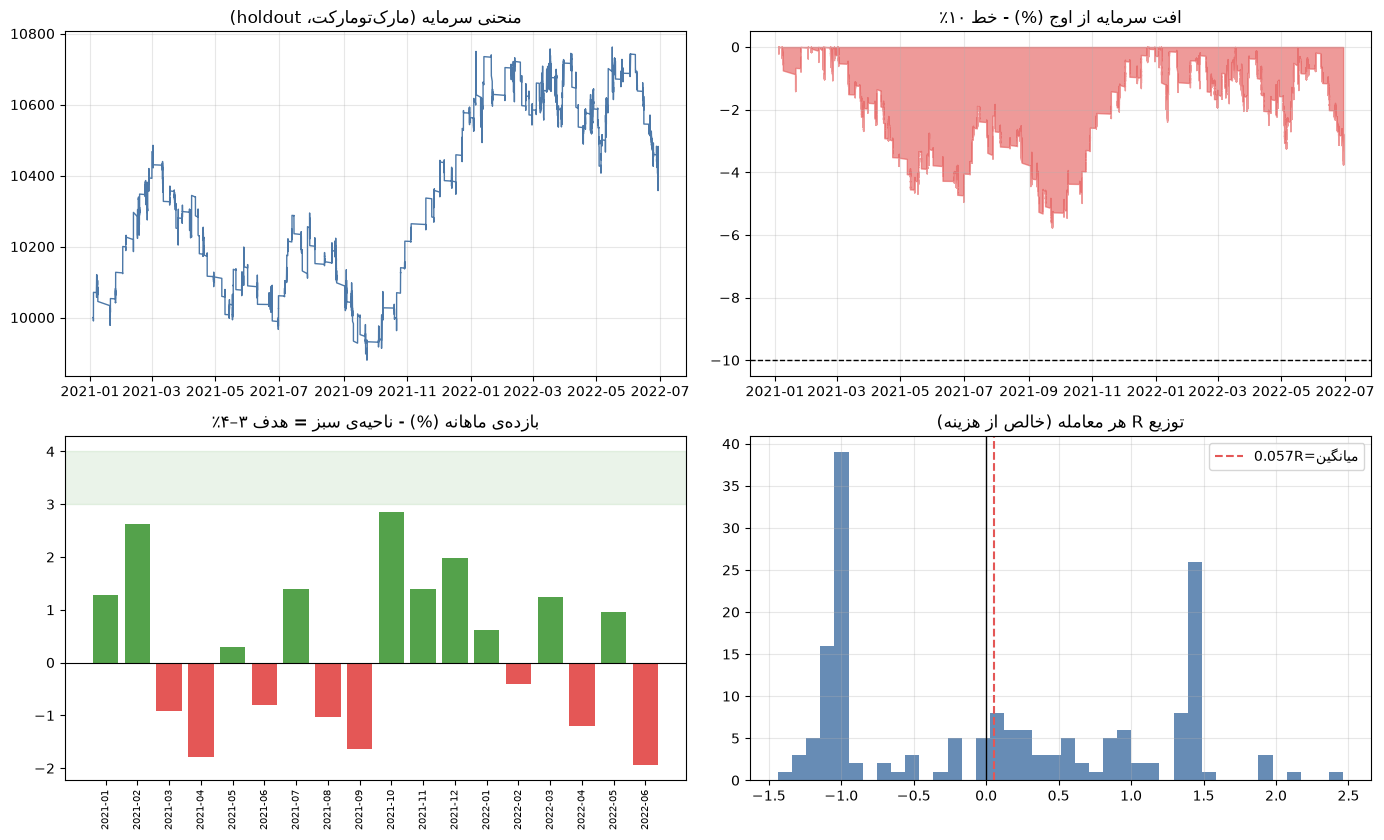

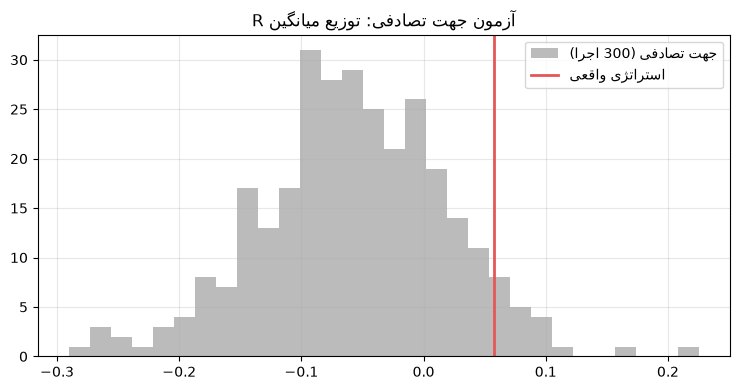

=== داوری هدف ===
  میانگین بازده‌ی ماهانه (holdout، ریسک 0.50%): 0.273%  → هدف ۳–۴٪: خیر
  حداکثر افت سرمایه (تیک‌به‌تیک): 5.80%  → سقف ۱۰٪: بله
  نتیجه: ❌ هدف برآورده نشد
  بزرگ‌ترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ مانده (از مرز ریسک): ریسک 0.50%
  احتمال (بوت‌استرپ) رسیدن میانگین ماهانه به ۳٪ در ریسک پایه: 0.00%


فایل‌های گزارش: /tmp/hipo_tick_cache/reports/EURUSD_M1_meta_holdout_report.html | /tmp/hipo_tick_cache/reports/EURUSD_M1_meta_holdout_charts.png


In [22]:
# ==================================================================================
# Cell 10 — 🏁 بک‌تستر حرفه‌ای تیک‌به‌تیک و گزارش جامع (سلول نهایی)
# استراتژی منجمد انتخابی روی holdout (2021-01 تا 2022-06) • بدون بهینه‌سازی روی این داده
# ==================================================================================
from scipy.stats import ttest_1samp
import base64, io as _io

REPORT_DIR = os.path.join(CACHE_DIR, "reports")
os.makedirs(REPORT_DIR, exist_ok=True)
RUN_TAG = f"{PAIR}_{SELECTED}_holdout"
pd.set_option("display.width", 200)

# ---------- ۱) اجرای پایه: تیک‌به‌تیک، ریسک پیش‌فرض ----------
BASE = run_window(SIG_HO, HO_START, HO_END)
TR = trades_frame(BASE["tr"])
EQ = equity_series(BASE["eq"], PRM0[P_EQ0])
BASE_SUM = summarize(BASE["tr"], BASE["eq"], PRM0[P_EQ0], BASE["dd_rel"], BASE["dd_abs"], HO_START, HO_END,
                     label=SELECTED)

# طول دوره‌ی زیر آب (underwater) بر حسب روز
_peak = EQ.cummax()
_uw = (EQ < _peak).values
_t = EQ.index.values
_longest, _start = 0.0, None
for _i in range(len(_uw)):
    if _uw[_i] and _start is None:
        _start = _t[_i]
    if (not _uw[_i]) and _start is not None:
        _longest = max(_longest, (_t[_i] - _start) / np.timedelta64(1, "D"))
        _start = None
if _start is not None:
    _longest = max(_longest, (_t[-1] - _start) / np.timedelta64(1, "D"))

_months_total = (HO_END - HO_START) / (30.44 * MS_DAY)
_exposure = float(TR["hold_min"].sum() / ((HO_END - HO_START) / MS_MIN)) * 100 if len(TR) else 0.0

CFG_TBL = pd.DataFrame([
    ("سرمایه‌ی اولیه (USD)", PRM0[P_EQ0]), ("ریسک هر معامله", f"{PRM0[P_RISK] * 100:.2f}% از سرمایه‌ی لحظه‌ای"),
    ("سقف اهرم", PRM0[P_MAXLEV]), ("کمیسیون (USD/لات/طرف)", PRM0[P_COMM]),
    ("اسلیپیج (pip، هر طرف)", round(PRM0[P_SLIP] / PIP, 2)), ("تأخیر اجرا (ms)", PRM0[P_LAT]),
    ("پنجره‌ی پرشدن (ms)", PRM0[P_FILLWIN]), ("فیلتر اسپرد بیشینه (pip)", round(PRM0[P_MAXSPREAD] / PIP, 2)),
    ("ورود جدید تا", "جمعه ۲۰:۰۰ UTC"), ("بستن اجباری", "جمعه ۲۰:۳۰ UTC"),
    ("جهت‌گیری", "یک پوزیشن هم‌زمان؛ سیگنال‌های زمانِ باز بودن نادیده گرفته می‌شوند"),
    ("بهره‌ی شبانه (swap)", "نادیده گرفته شده (داده‌ی swap در دسترس نیست)"),
    ("مبنای قیمت", "خرید با ask، فروش با bid؛ همه‌ی خروج‌ها با تیک واقعی"),
], columns=["پارامتر", "مقدار"]).set_index("پارامتر")
print("=== پیکربندی موتور تیک‌به‌تیک ===")
display(CFG_TBL)

# ---------- ۲) خلاصه‌ی عملکرد ----------
_keys = ["trades", "net_profit_%", "CAGR_%", "monthly_mean_%", "monthly_median_%", "monthly_min_%", "monthly_max_%",
         "months_>=3%_%", "months_>0_%", "maxDD_%", "maxDD_usd", "Calmar", "Sharpe_daily_ann", "win_rate_%", "avg_R",
         "t_stat_R", "profit_factor", "avg_net_pips", "avg_hold_h", "commission_usd", "spread_cost_usd_est"]
_sum = {k: BASE_SUM.get(k, np.nan) for k in _keys}
_sum["exposure_%_of_time"] = _exposure
_sum["longest_underwater_days"] = _longest
_sum["trades_per_month"] = BASE_SUM["trades"] / _months_total
SUMMARY_TBL = pd.Series(_sum, name=SELECTED).to_frame()
print("=== خلاصه‌ی عملکرد (holdout، تیک‌به‌تیک، ریسک پایه) ===")
display(SUMMARY_TBL.round(3))

# ---------- ۳) بازده‌ی ماهانه ----------
MR = monthly_returns(BASE["eq"], PRM0[P_EQ0])
MR_TBL = pd.DataFrame({"سال": MR.index.year, "ماه": MR.index.month, "بازده %": (100 * MR.values).round(2)})
MR_PIV = MR_TBL.pivot(index="سال", columns="ماه", values="بازده %")
MR_PIV["سال"] = MR_PIV.sum(axis=1).round(2)
print("=== بازده‌ی ماهانه (%) ===")
display(MR_PIV)

# ---------- ۴) تحلیل معاملات ----------
if len(TR):
    _gx = TR.groupby("exit_reason").agg(تعداد=("R", "size"), میانگین_R=("R", "mean"), برد_درصد=("R", lambda s: 100 * (s > 0).mean()),
                                          جمع_خالص_USD=("net", "sum"))
    _gh = TR.groupby(TR["entry_time"].dt.hour).agg(تعداد=("R", "size"), میانگین_R=("R", "mean"), جمع_خالص_USD=("net", "sum"))
    _gd = TR.groupby(np.where(TR["dir"] > 0, "خرید", "فروش")).agg(تعداد=("R", "size"), میانگین_R=("R", "mean"),
                                                                    برد_درصد=("R", lambda s: 100 * (s > 0).mean()))
    _mae = (TR["mae"] / PIP)
    _mfe = (TR["mfe"] / PIP)
    print("=== علت خروج ===")
    display(_gx.round(3))
    print("=== جهت معامله ===")
    display(_gd.round(3))
    print(f"میانگین MAE: {_mae.mean():.1f} pip | میانگین MFE: {_mfe.mean():.1f} pip | میانه‌ی مدت نگهداری: {TR['hold_min'].median() / 60:.1f} ساعت")
    print("=== عملکرد بر حسب ساعت ورود (UTC) ===")
    display(_gh.round(2).T)

# ---------- ۵) حساسیت به هزینه، تأخیر و فیلتر اسپرد ----------
SCEN = [
    ("پایه", {}), ("اسپرد ×1.5", {P_SPREADMULT: 1.5}), ("اسپرد ×2", {P_SPREADMULT: 2.0}),
    ("اسپرد ×3", {P_SPREADMULT: 3.0}), ("اسلیپیج = ۰", {P_SLIP: 0.0}), ("اسلیپیج = ۰.۳ pip", {P_SLIP: 0.3 * PIP}),
    ("تأخیر ۰.۵ ثانیه", {P_LAT: 500}), ("تأخیر ۳ ثانیه", {P_LAT: 3000}), ("تأخیر ۵ ثانیه", {P_LAT: 5000}),
    ("کمیسیون = ۰", {P_COMM: 0.0}), ("کمیسیون = ۷ دلار", {P_COMM: 7.0}),
    ("بدون فیلتر اسپرد", {P_MAXSPREAD: 0.0}), ("فیلتر اسپرد ۱ pip", {P_MAXSPREAD: 1.0 * PIP}),
]
_scen_rows = []
for _name, _chg in SCEN:
    _p = PRM0.copy()
    for _k, _v in _chg.items():
        _p[_k] = _v
    _r = run_window(SIG_HO, HO_START, HO_END, prm=_p)
    _s = summarize(_r["tr"], _r["eq"], PRM0[P_EQ0], _r["dd_rel"], _r["dd_abs"], HO_START, HO_END, label=_name)
    _scen_rows.append({"سناریو": _name, "معامله": _s["trades"], "بازده‌ی کل %": round(_s["net_profit_%"], 2),
                       "میانگین ماهانه %": round(_s["monthly_mean_%"], 3), "DD %": round(_s["maxDD_%"], 2),
                       "میانگین R": round(_s.get("avg_R", np.nan), 4), "ضریب سود": round(_s.get("profit_factor", np.nan), 3)})
SCEN_TBL = pd.DataFrame(_scen_rows).set_index("سناریو")
print("=== تحلیل حساسیت هزینه و اجرا (هر سطر یک اجرای کامل تیک‌به‌تیک) ===")
display(SCEN_TBL)

# ---------- ۶) آمار استنباطی ----------
_Rv = TR["R"].values if len(TR) else np.array([0.0])
_ci = boot_ci(_Rv, np.mean, B=3000)
_tt = ttest_1samp(_Rv, 0.0) if len(_Rv) > 2 else None
_rng = np.random.default_rng(7)
_null_means = []
for _b in range(300):
    _sc = SIG_HO.copy()
    _sc["dir"] = _rng.choice([-1.0, 1.0], size=len(_sc))  # همان زمان/فاصله‌ی SL/TP/نگهداری، جهت تصادفی
    _rr = run_window(_sc, HO_START, HO_END)
    _tn = trades_frame(_rr["tr"])
    if len(_tn):
        _null_means.append(_tn["R"].mean())
_null_means = np.array(_null_means) if _null_means else np.array([0.0])
_p_null = float((_null_means >= _Rv.mean()).mean())
STAT_TBL = pd.DataFrame([
    ("میانگین R (holdout)", round(_Rv.mean(), 4)), ("CI 95% میانگین R (bootstrap)", f"[{_ci[0]:.4f}, {_ci[1]:.4f}]"),
    ("t-stat میانگین R", round(float(_tt.statistic), 3) if _tt is not None else np.nan),
    ("p-value دوطرفه (t-test)", round(float(_tt.pvalue), 4) if _tt is not None else np.nan),
    ("میانگین R در جهت تصادفی (300 اجرا)", round(float(_null_means.mean()), 4)),
    ("p-value یک‌طرفه در برابر جهت تصادفی", round(_p_null, 4)),
    ("DSR (از سلول ۸)", round(float(dsr_p), 3)), ("PBO پیکربندی‌ها (از سلول ۸)", round(float(pbo), 3)),
    ("P(ماه ≥ ۳٪) با بوت‌استرپ ریسک پایه", round(float((mc_monthly(R_BY_MONTH, PRM0[P_RISK])[0] >= 0.03).mean()), 3)),
], columns=["آماره", "مقدار"]).set_index("آماره")
print("=== آمار استنباطی ===")
display(STAT_TBL)

# ---------- ۷) نمودارهای گزارش ----------
fig, axes = plt.subplots(2, 2, figsize=(14, 8.5))
ax = axes[0, 0]
ax.plot(EQ.index, EQ.values, color="#4C78A8", lw=1)
ax.set_title("منحنی سرمایه (مارک‌تو‌مارکت، holdout)"); ax.grid(alpha=0.3)
ax = axes[0, 1]
_dd = 100 * (EQ.cummax() - EQ) / EQ.cummax()
ax.fill_between(_dd.index, -_dd.values, 0, color="#E45756", alpha=0.6)
ax.axhline(-10, color="black", ls="--", lw=1); ax.set_title("افت سرمایه از اوج (%) - خط ۱۰٪"); ax.grid(alpha=0.3)
ax = axes[1, 0]
_mrv = 100 * MR.values
ax.bar([str(p) for p in MR.index], _mrv, color=np.where(_mrv >= 0, "#54A24B", "#E45756"))
ax.axhspan(3, 4, color="#54A24B", alpha=0.12); ax.axhline(0, color="black", lw=0.8)
ax.set_title("بازده‌ی ماهانه (%) - ناحیه‌ی سبز = هدف ۳–۴٪"); ax.tick_params(axis="x", rotation=90, labelsize=7)
ax = axes[1, 1]
ax.hist(_Rv, bins=40, color="#4C78A8", alpha=0.85)
ax.axvline(0, color="black", lw=1); ax.axvline(_Rv.mean(), color="#E45756", ls="--", label=f"میانگین={_Rv.mean():.3f}R")
ax.set_title("توزیع R هر معامله (خالص از هزینه)"); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
_png = os.path.join(REPORT_DIR, f"{RUN_TAG}_charts.png")
plt.savefig(_png, dpi=110)
plt.show()

fig2, ax2 = plt.subplots(figsize=(7.5, 4))
ax2.hist(_null_means, bins=30, color="#BBBBBB", label="جهت تصادفی (300 اجرا)")
ax2.axvline(_Rv.mean(), color="#E45756", lw=2, label="استراتژی واقعی")
ax2.set_title("آزمون جهت تصادفی: توزیع میانگین R"); ax2.legend(); ax2.grid(alpha=0.3)
plt.tight_layout(); plt.show()

# ---------- ۸) داوری نهایی (با اعداد محاسبه‌شده) ----------
_mm = BASE_SUM["monthly_mean_%"]
_dd_pct = BASE_SUM["maxDD_%"]
_tgt_ok = _mm >= 3.0
_dd_ok = _dd_pct < 10.0
_verdict = ("✅ هدف برآورده شد" if (_tgt_ok and _dd_ok) else "❌ هدف برآورده نشد")
print("=== داوری هدف ===")
print(f"  میانگین بازده‌ی ماهانه (holdout، ریسک {PRM0[P_RISK] * 100:.2f}%): {_mm:.3f}%  → هدف ۳–۴٪: {'بله' if _tgt_ok else 'خیر'}")
print(f"  حداکثر افت سرمایه (تیک‌به‌تیک): {_dd_pct:.2f}%  → سقف ۱۰٪: {'بله' if _dd_ok else 'خیر'}")
print(f"  نتیجه: {_verdict}")
print(f"  بزرگ‌ترین ریسکی که DD تیک‌به‌تیک آن زیر ۱۰٪ مانده (از مرز ریسک): {_best_for_dd['strategy'].iloc[-1] if len(_best_for_dd) else '—'}")
print(f"  احتمال (بوت‌استرپ) رسیدن میانگین ماهانه به ۳٪ در ریسک پایه: {100 * float((mc_monthly(R_BY_MONTH, PRM0[P_RISK])[0].mean(axis=1) >= 0.03).mean()):.2f}%")

# ---------- ۹) خروجی‌ها: CSV و گزارش HTML ----------
TR.to_csv(os.path.join(REPORT_DIR, f"{RUN_TAG}_trades.csv"), index=False)
MR_TBL.to_csv(os.path.join(REPORT_DIR, f"{RUN_TAG}_monthly.csv"), index=False)
_buf = _io.BytesIO()
fig.savefig(_buf, format="png", dpi=90)
_b64 = base64.b64encode(_buf.getvalue()).decode()
_html = f"""<html><head><meta charset='utf-8'><title>{RUN_TAG}</title>
<style>body{{font-family:Tahoma,sans-serif;direction:rtl;margin:24px}}table{{border-collapse:collapse;font-size:12px}}
td,th{{border:1px solid #ccc;padding:3px 6px}}h2{{margin-top:28px}}</style></head><body>
<h1>گزارش بک‌تست تیک‌به‌تیک - {PAIR} - {SELECTED}</h1>
<p>دوره‌ی holdout: {pd.Timestamp(HO_START, unit='ms').date()} تا {pd.Timestamp(HO_END, unit='ms').date()} | داده: Dukascopy (تیک bid/ask)</p>
<h2>پیکربندی</h2>{CFG_TBL.to_html()}
<h2>خلاصه</h2>{SUMMARY_TBL.round(3).to_html()}
<h2>بازده‌ی ماهانه (%)</h2>{MR_PIV.to_html()}
<h2>حساسیت</h2>{SCEN_TBL.to_html()}
<h2>آمار استنباطی</h2>{STAT_TBL.to_html()}
<h2>نمودارها</h2><img style='max-width:100%' src='data:image/png;base64,{_b64}'/>
<h2>داوری</h2><p>{_verdict} | میانگین ماهانه {_mm:.3f}% | حداکثر DD {_dd_pct:.2f}%</p>
</body></html>"""
_html_path = os.path.join(REPORT_DIR, f"{RUN_TAG}_report.html")
with open(_html_path, "w", encoding="utf-8") as fh:
    fh.write(_html)
print("فایل‌های گزارش:", _html_path, "|", _png)
